## Learning objectives
- See how to train, calibrate, and extract factual explanations from a classifier;
- Visualize uncertainty and alternatives for individual instances;
- Learn when to use conjunctive rules and triangular plots for interpretation.
- **NEW**: Use the perturbation guard to filter out-of-distribution perturbations for more reliable explanations.

## Time to run
~2–10 min depending on dataset and environment (use smaller datasets for a faster run).


### Toy example — binary factual (fast) with guard
Run a tiny sklearn example (breast cancer) and explain a single instance using a calibrated explainer with the perturbation guard enabled. This cell is self-contained and intended for a quick local run.

In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Guard configuration options

The `ConformalRegionOracle` has several parameters you can tune:

- `alpha`: Significance level for conformal calibration (default 0.1)
- `mode`: "clf" for classification, "reg" for regression
- `threshold`: For regression, the threshold to define positive class
- `n_clusters`: Number of clusters per label (default 5)
- `covariance`: "diag" for diagonal covariance (default)
- `use_martingale`: Enable additional e-test validation (default False)
- `random_state`: For reproducibility

Example with custom settings:
```python
guard = ConformalRegionOracle(
    alpha=0.05,  # More conservative
    n_clusters=10,  # More clusters
    use_martingale=True,  # Enable e-test
    random_state=42
)
```


**What this shows**: a minimal end-to-end flow with guard enabled — train, calibrate, explain a single instance with filtered perturbations, and visualize calibrated probability with feature contributions.

# Getting started with calibrated-explanations and perturbation guards
Author: Tuwe Löfström (tuwe.lofstrom@ju.se)  
Copyright 2023 Tuwe Löfström  
License: BSD 3 clause

## What is the perturbation guard?

The perturbation guard is an optional feature that filters out out-of-distribution (OOD) perturbations during explanation generation. This helps ensure that explanations are based on more realistic counterfactual scenarios, improving the reliability and interpretability of the results.

## Classification with guard

In [36]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

dataset = fetch_openml(name="wine", version=7, as_frame=True, parser="auto")

X = dataset.data.values.astype(float)
y = (dataset.target.values == "True").astype(int)

feature_names = dataset.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=2, stratify=y)

X_prop_train, X_cal, y_prop_train, y_cal = train_test_split(X_train, y_train, test_size=0.25)

We now fit a model on our data. 

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1)

rf.fit(X_prop_train, y_prop_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Let us explain a test instance using the `CalibratedExplainer` class with the perturbation guard enabled. The guard will automatically filter perturbations to ensure they stay within the learned distribution.

In [38]:
from calibrated_explanations import CalibratedExplainer, __version__
from calibrated_explanations.guards import ConformalRegionOracle

# Create guard with default settings
guard = ConformalRegionOracle(alpha=0.1, mode="clf", n_clusters=5, random_state=42)

explainer = CalibratedExplainer(rf, X_cal, y_cal, feature_names=feature_names, guard=guard)

factual_explanations = explainer.explain_factual(X_test)

display(explainer)

print(f"calibrated_explanations {__version__}")
print(f"Guard fitted: {explainer.guard._fitted}")

c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


CalibratedExplainer(mode=classification, discretizer=BinaryEntropyDiscretizer(), learner=RandomForestClassifier(n_jobs=-1))

calibrated_explanations v0.9.0
Guard fitted: True


The guard is now active and will filter perturbations during explanation generation. You can also use the string shortcut:

In [39]:
# Alternative: use string spec
explainer_with_guard = CalibratedExplainer(rf, X_cal, y_cal, feature_names=feature_names, guard="conformal_regions")

c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Once we have the explanations, we can plot all of them using `plot`. Default, a regular plot, without uncertainty intervals included, is created. To include uncertainty intervals, change the parameter `uncertainty=True`. To plot only a single instance, the `plot` function can be called, submitting the index of the test instance to plot.

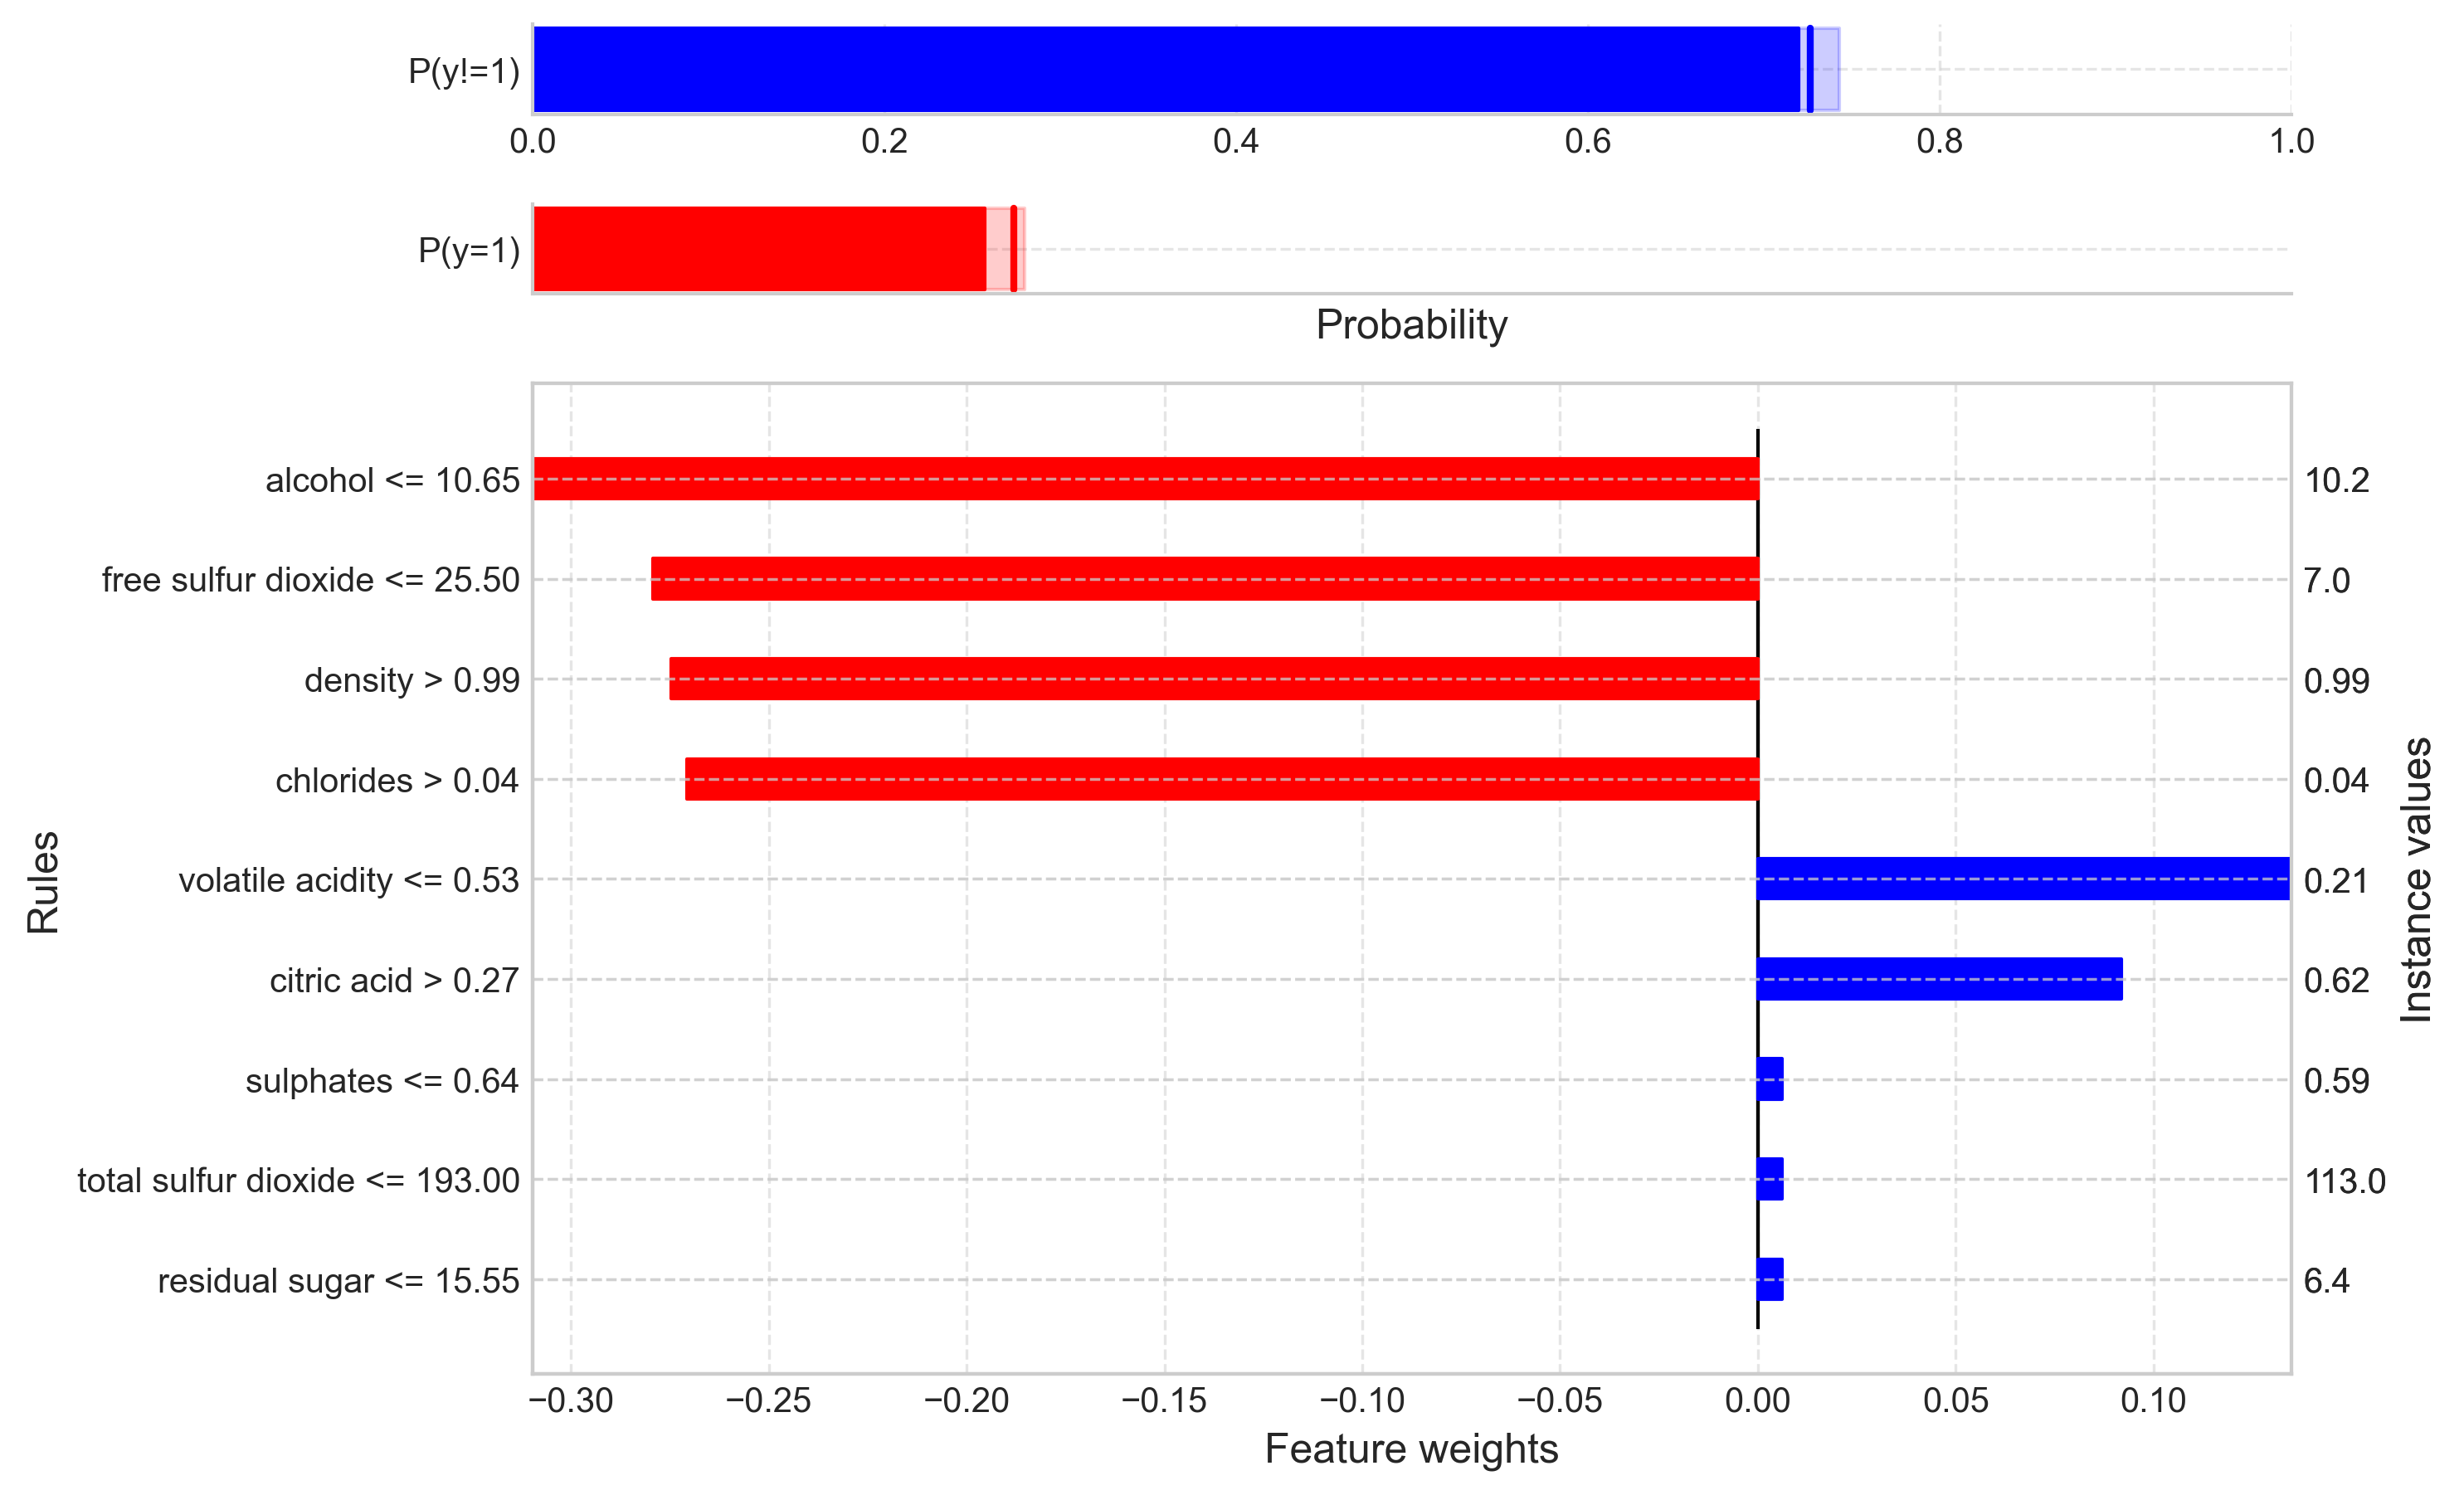

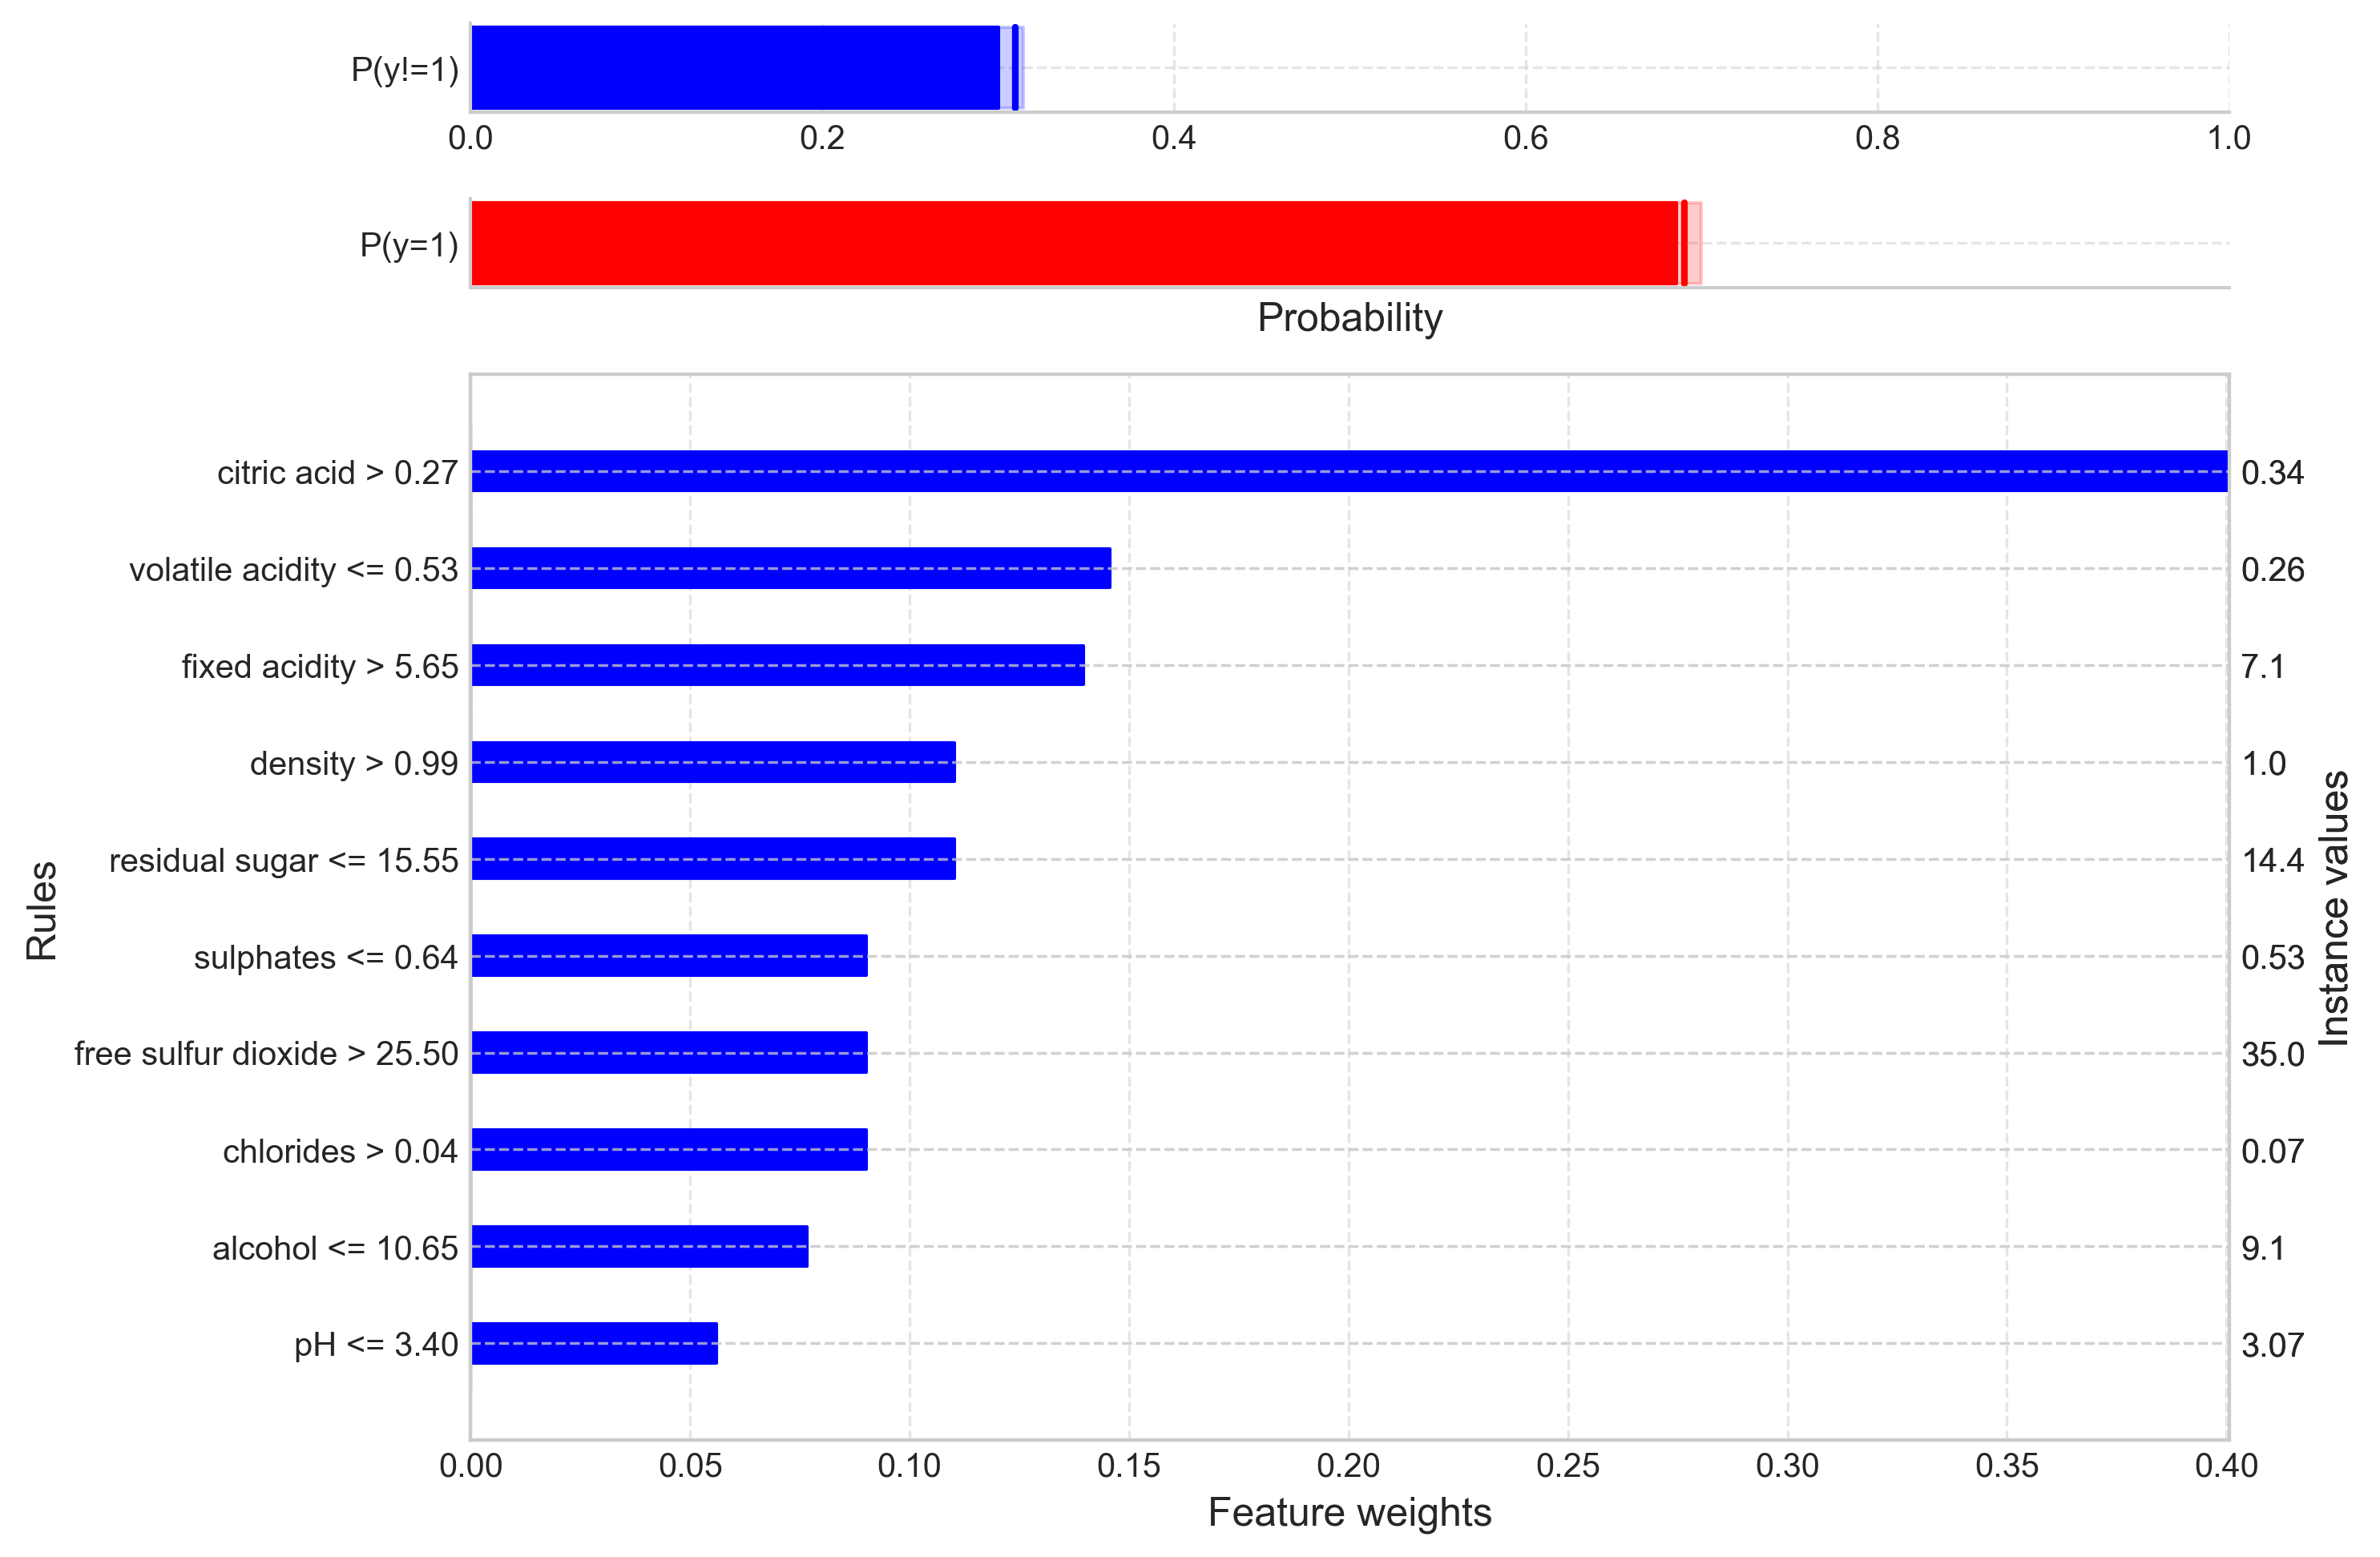

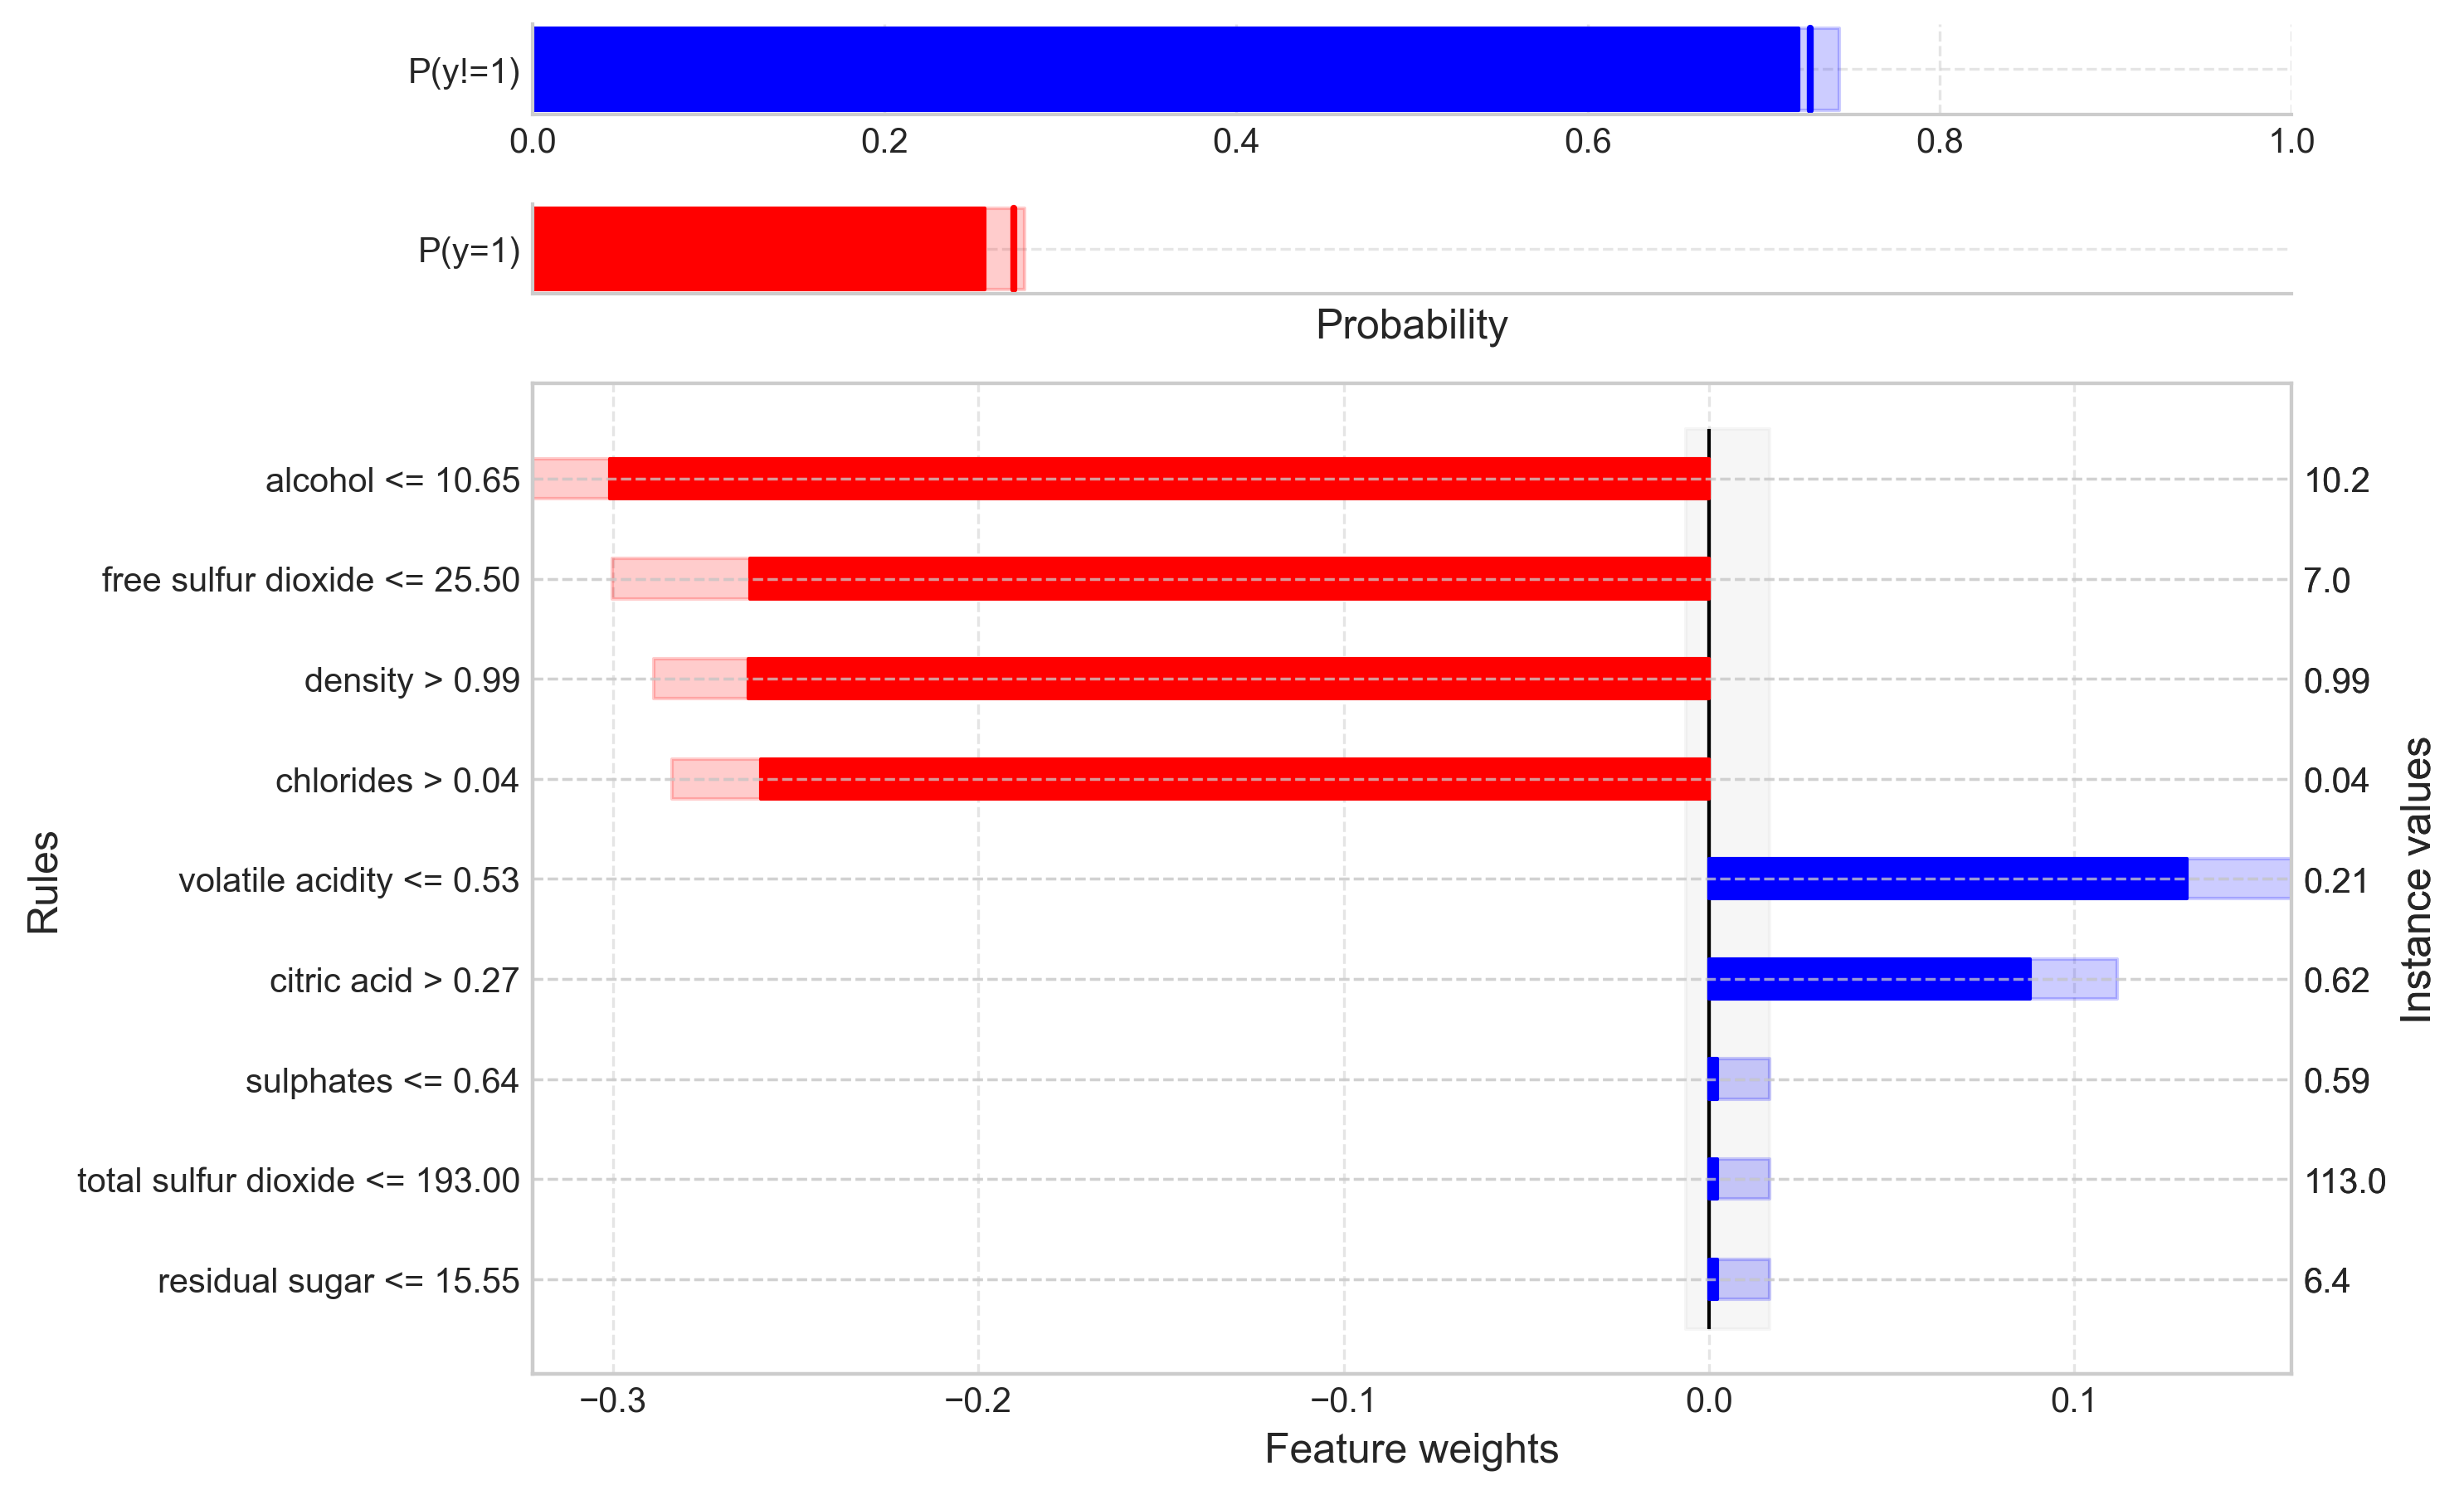

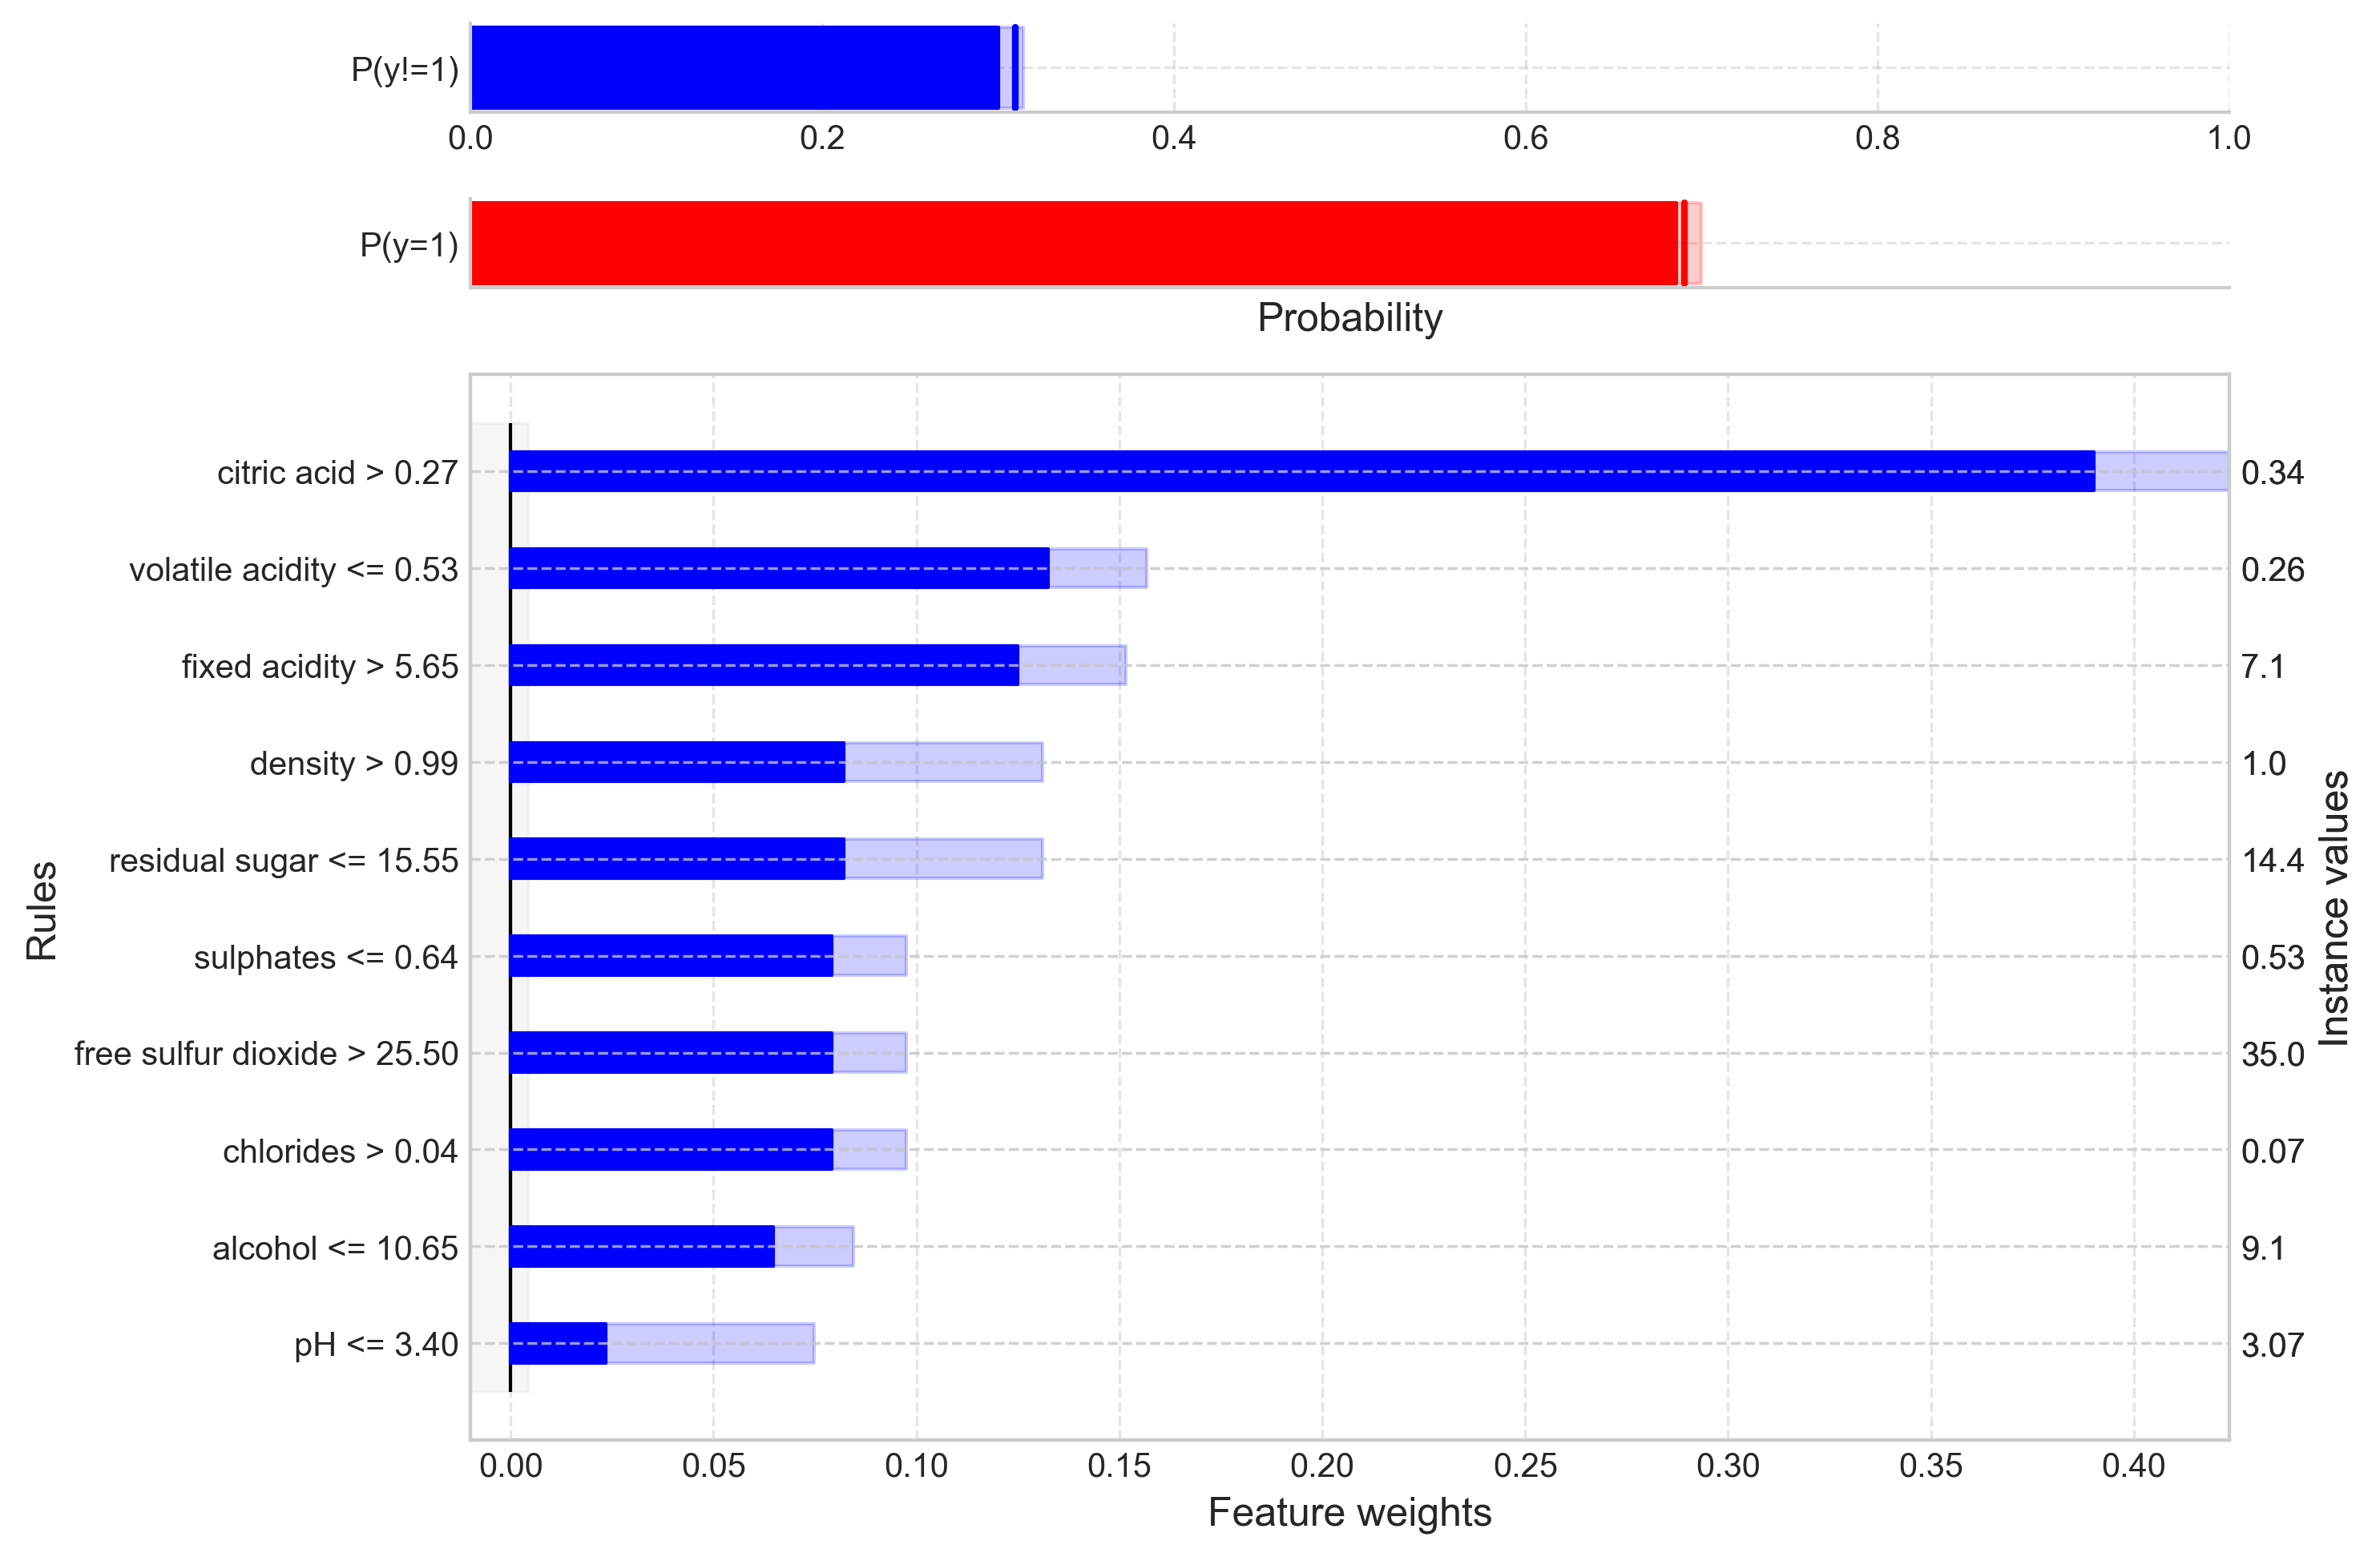

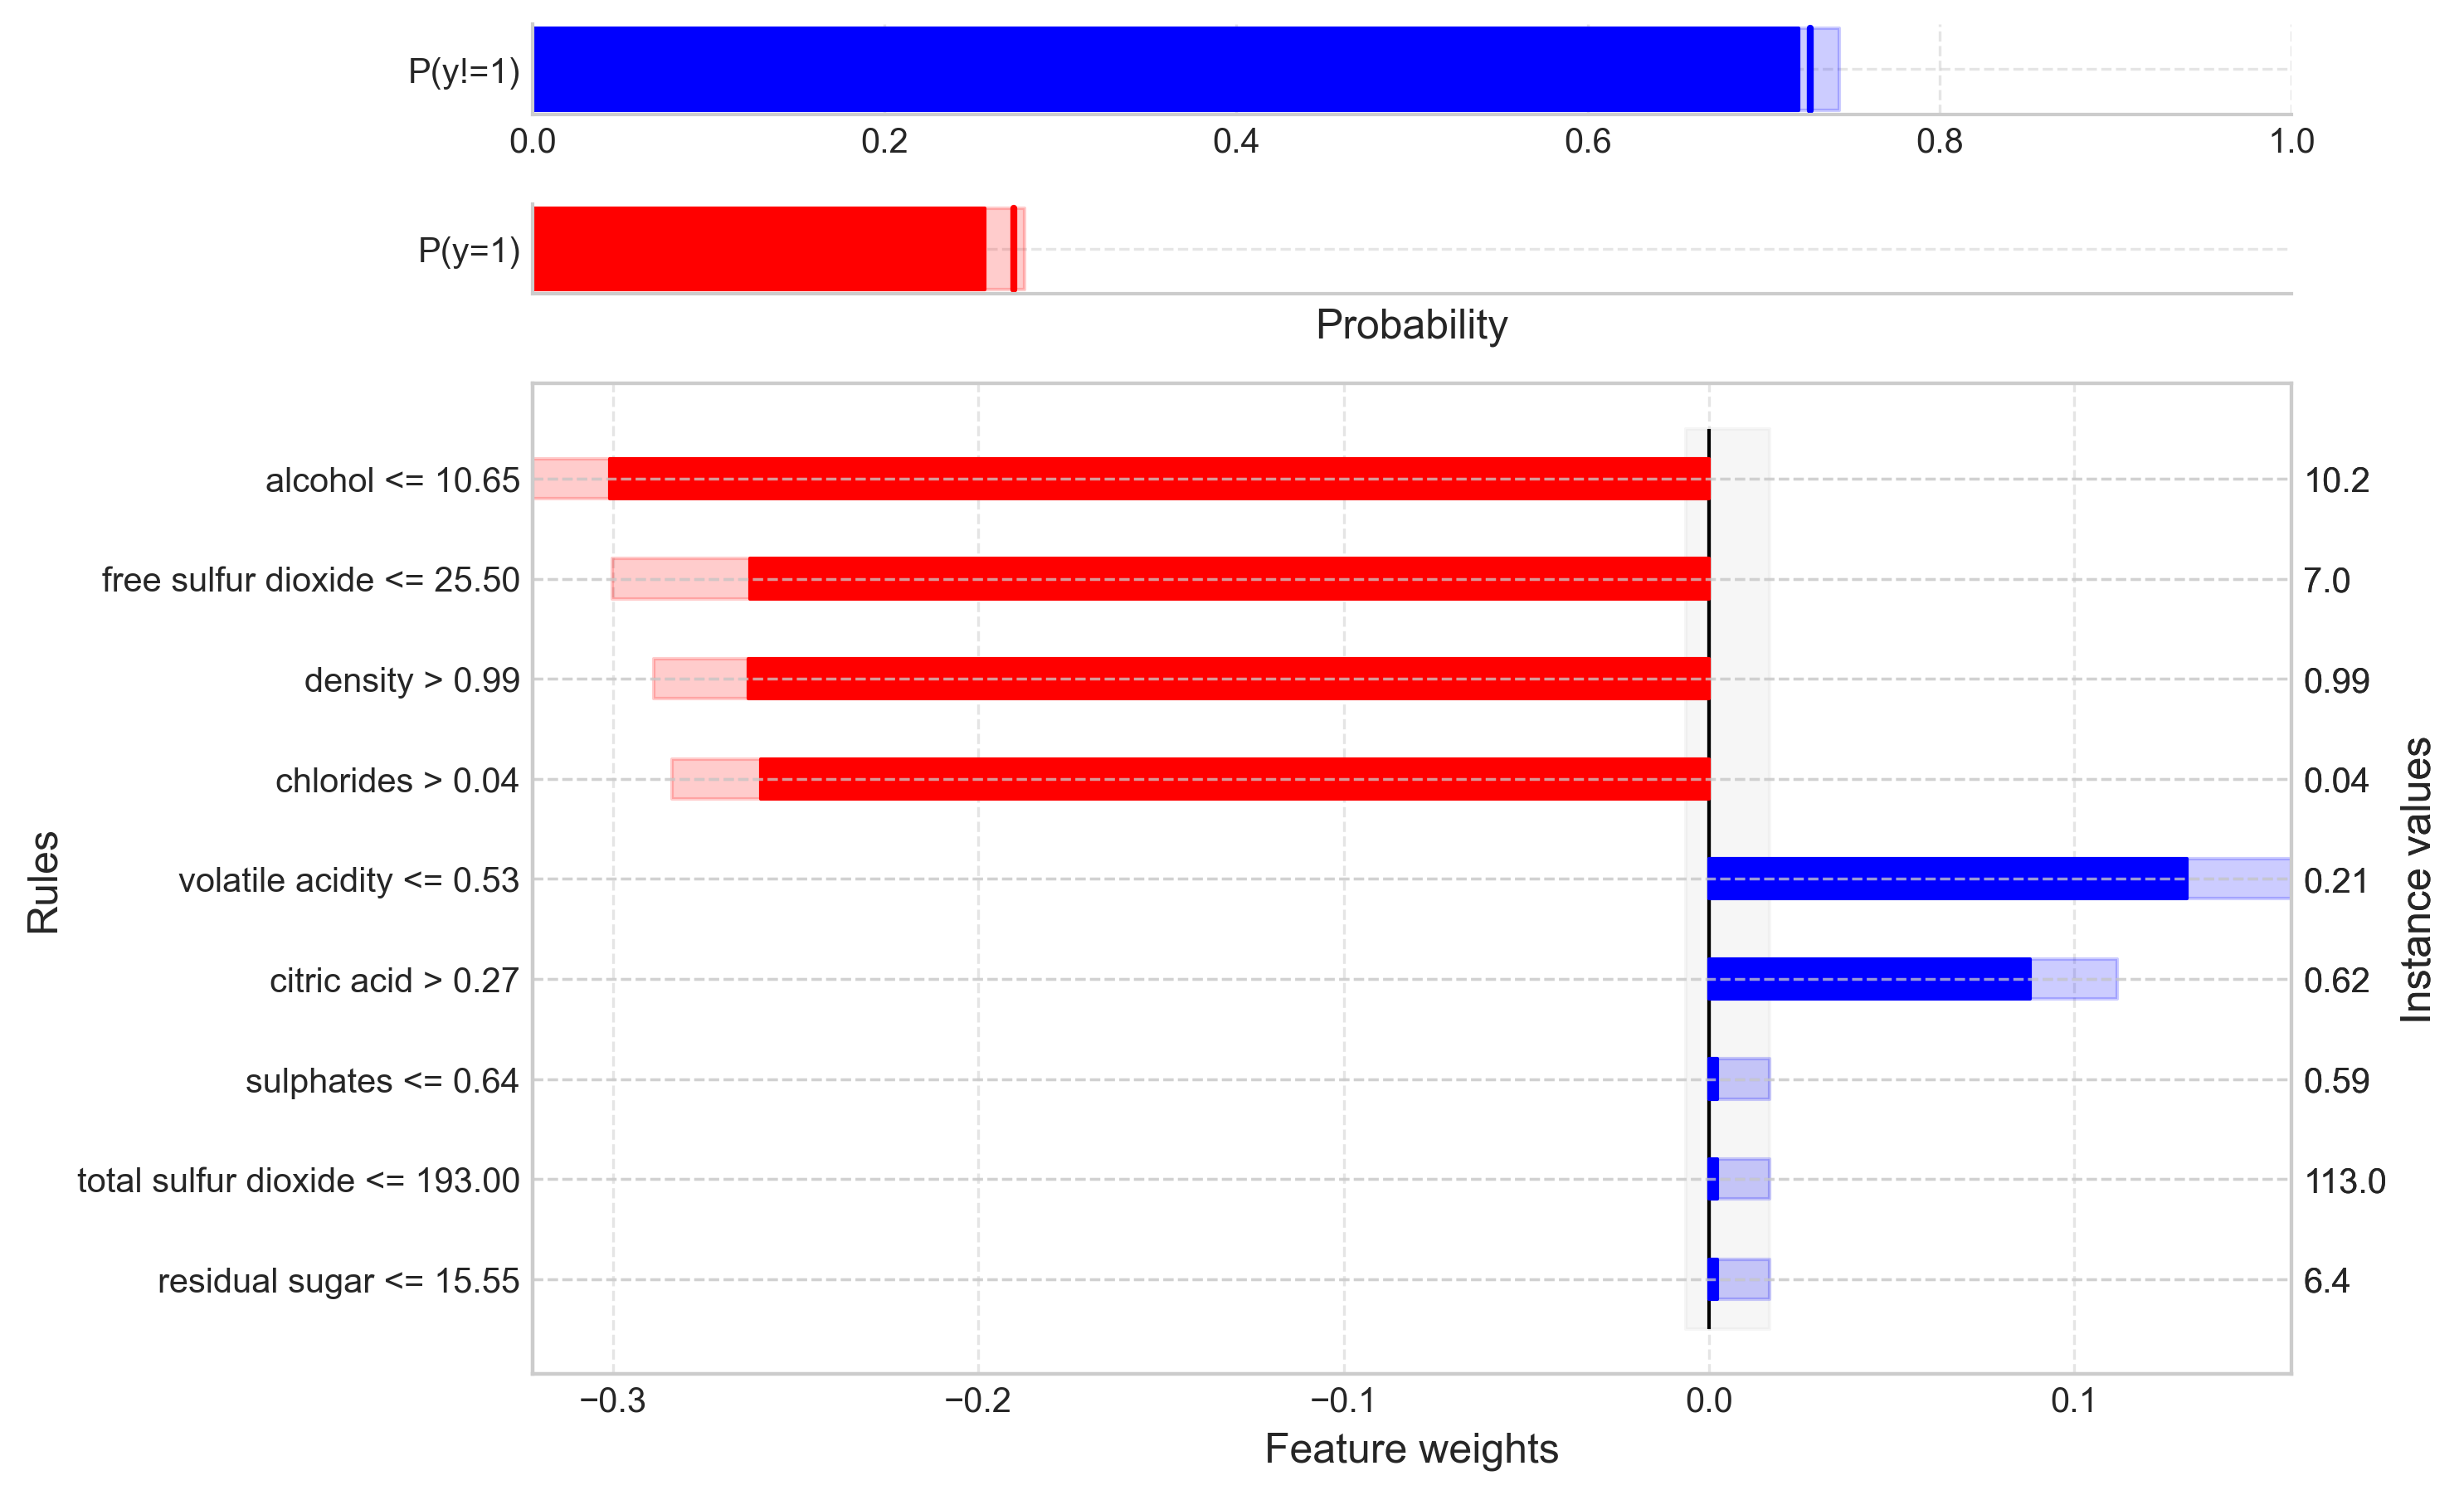

In [40]:
factual_explanations.plot()
factual_explanations.plot(uncertainty=True)

factual_explanations.plot(0, uncertainty=True)

You can also add and remove conjunctive rules. The guard will also validate combined perturbations for conjunctions.

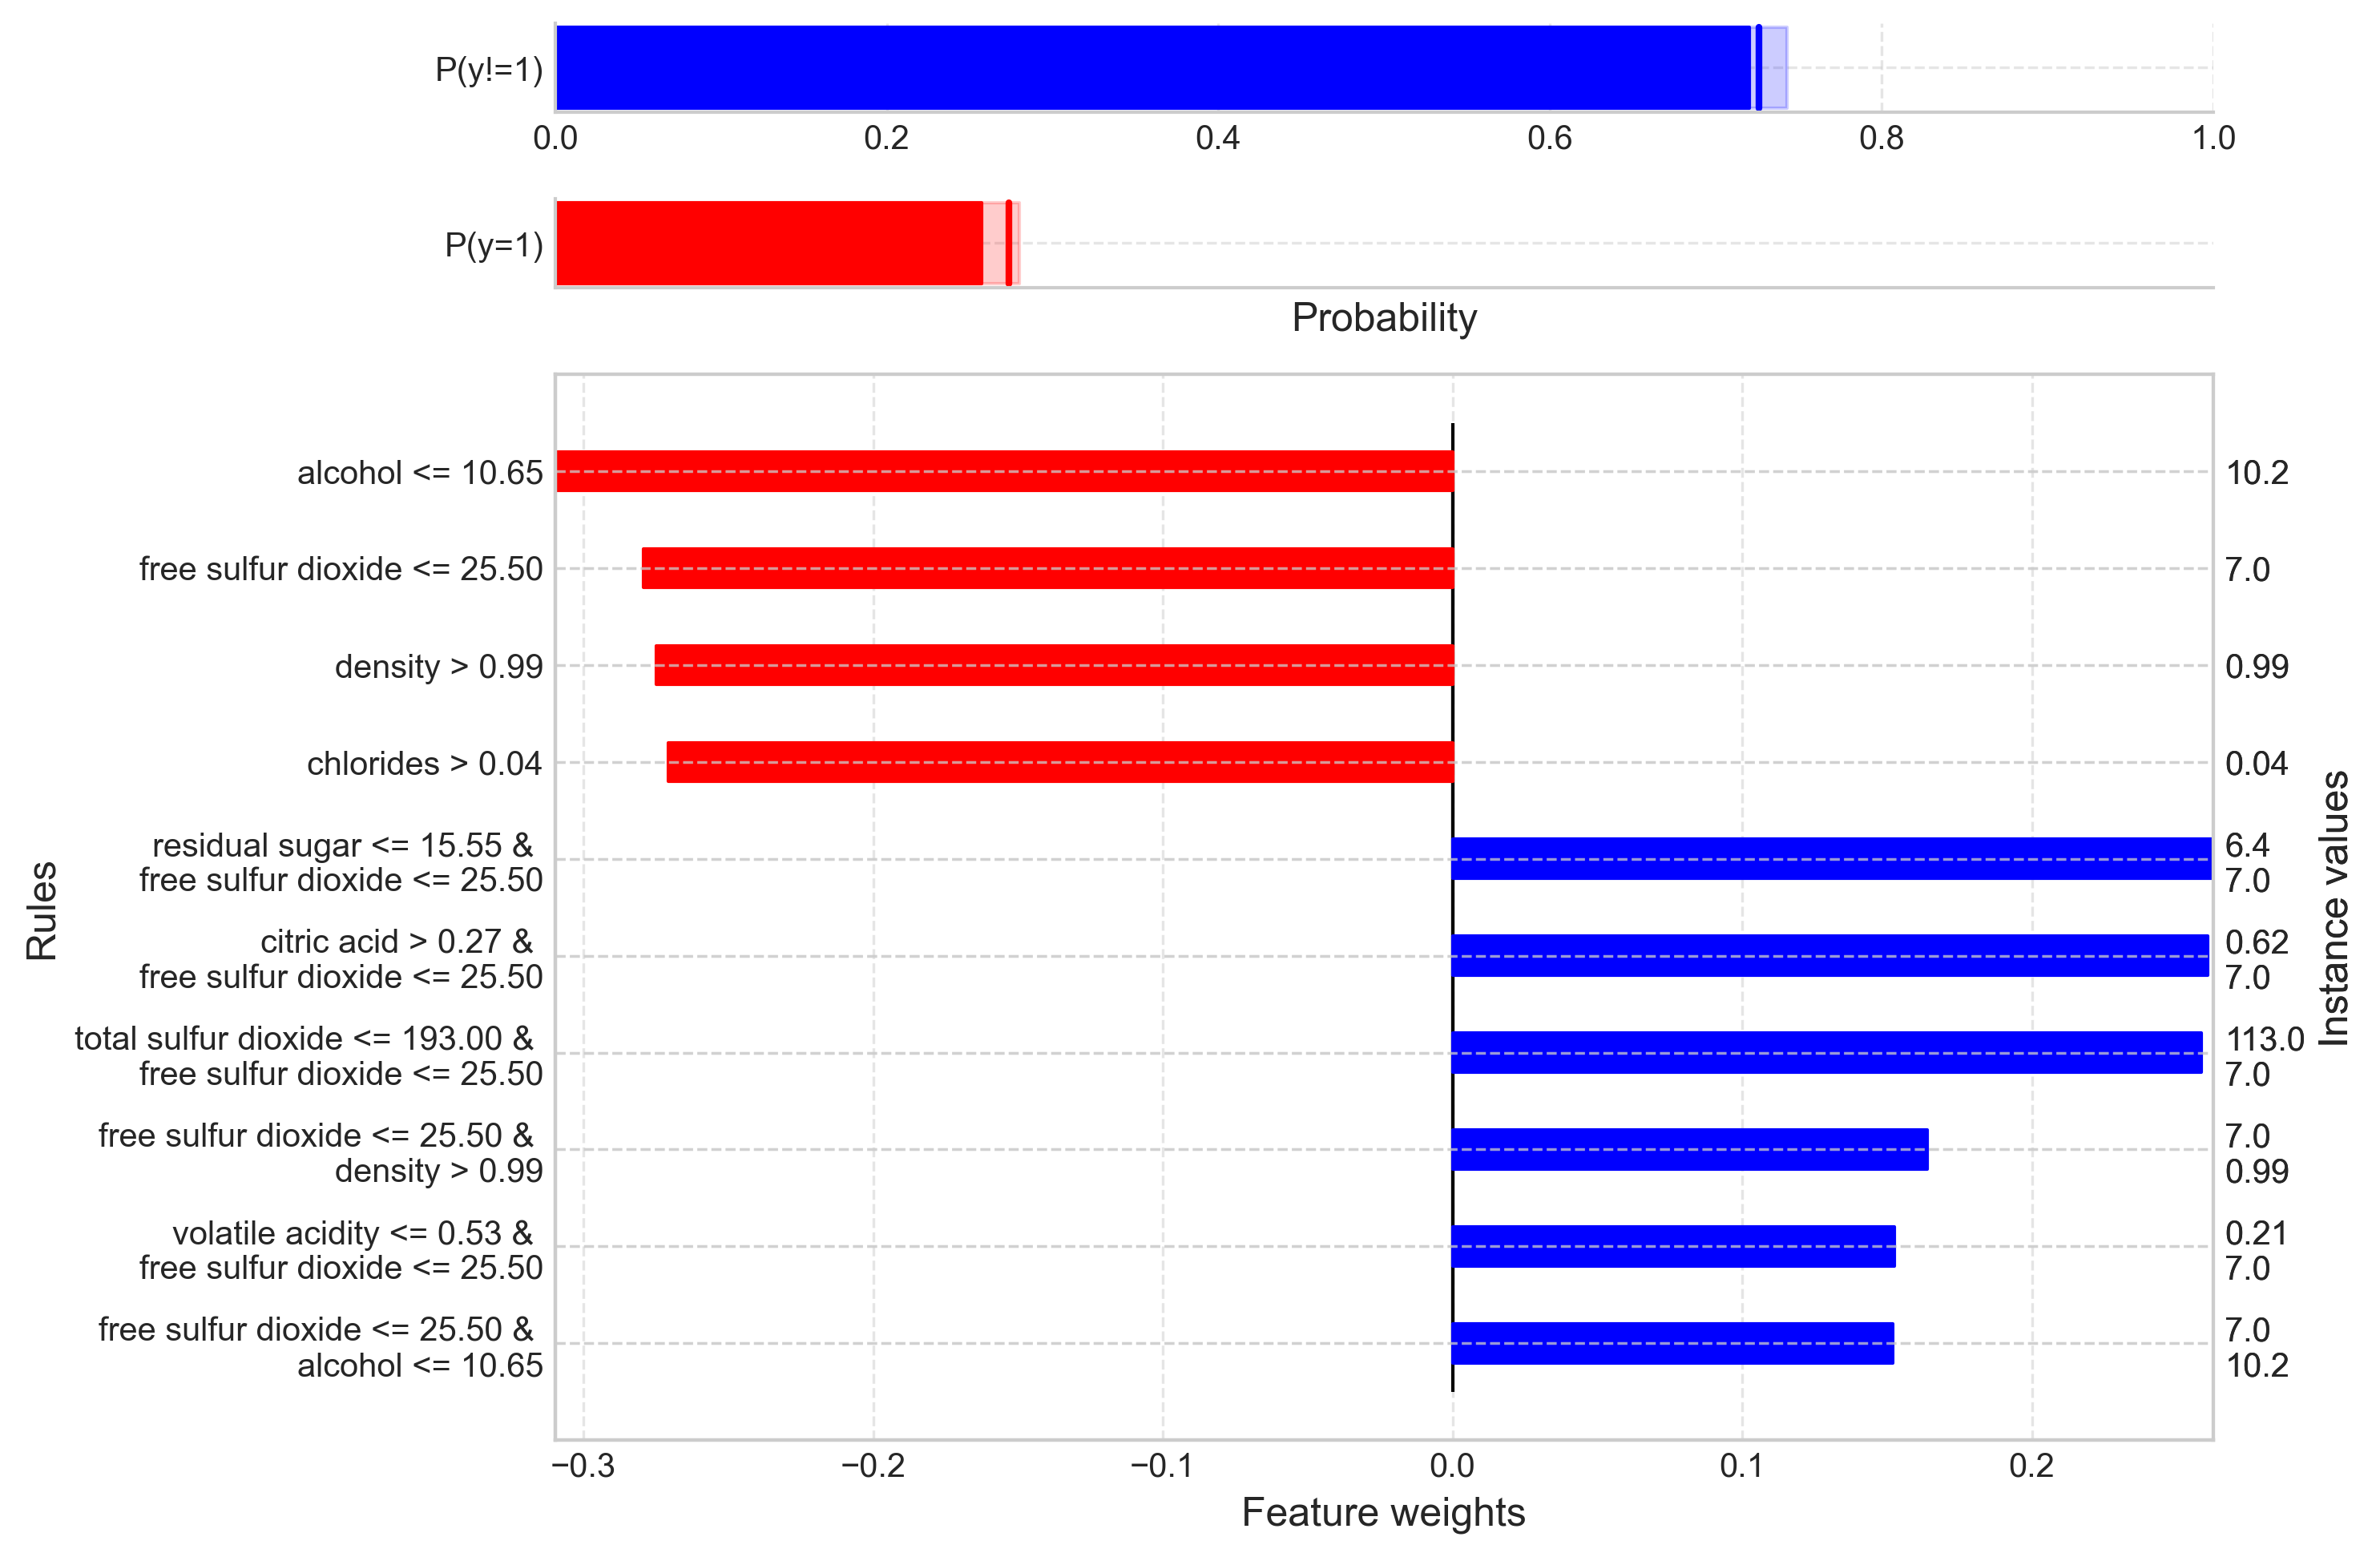

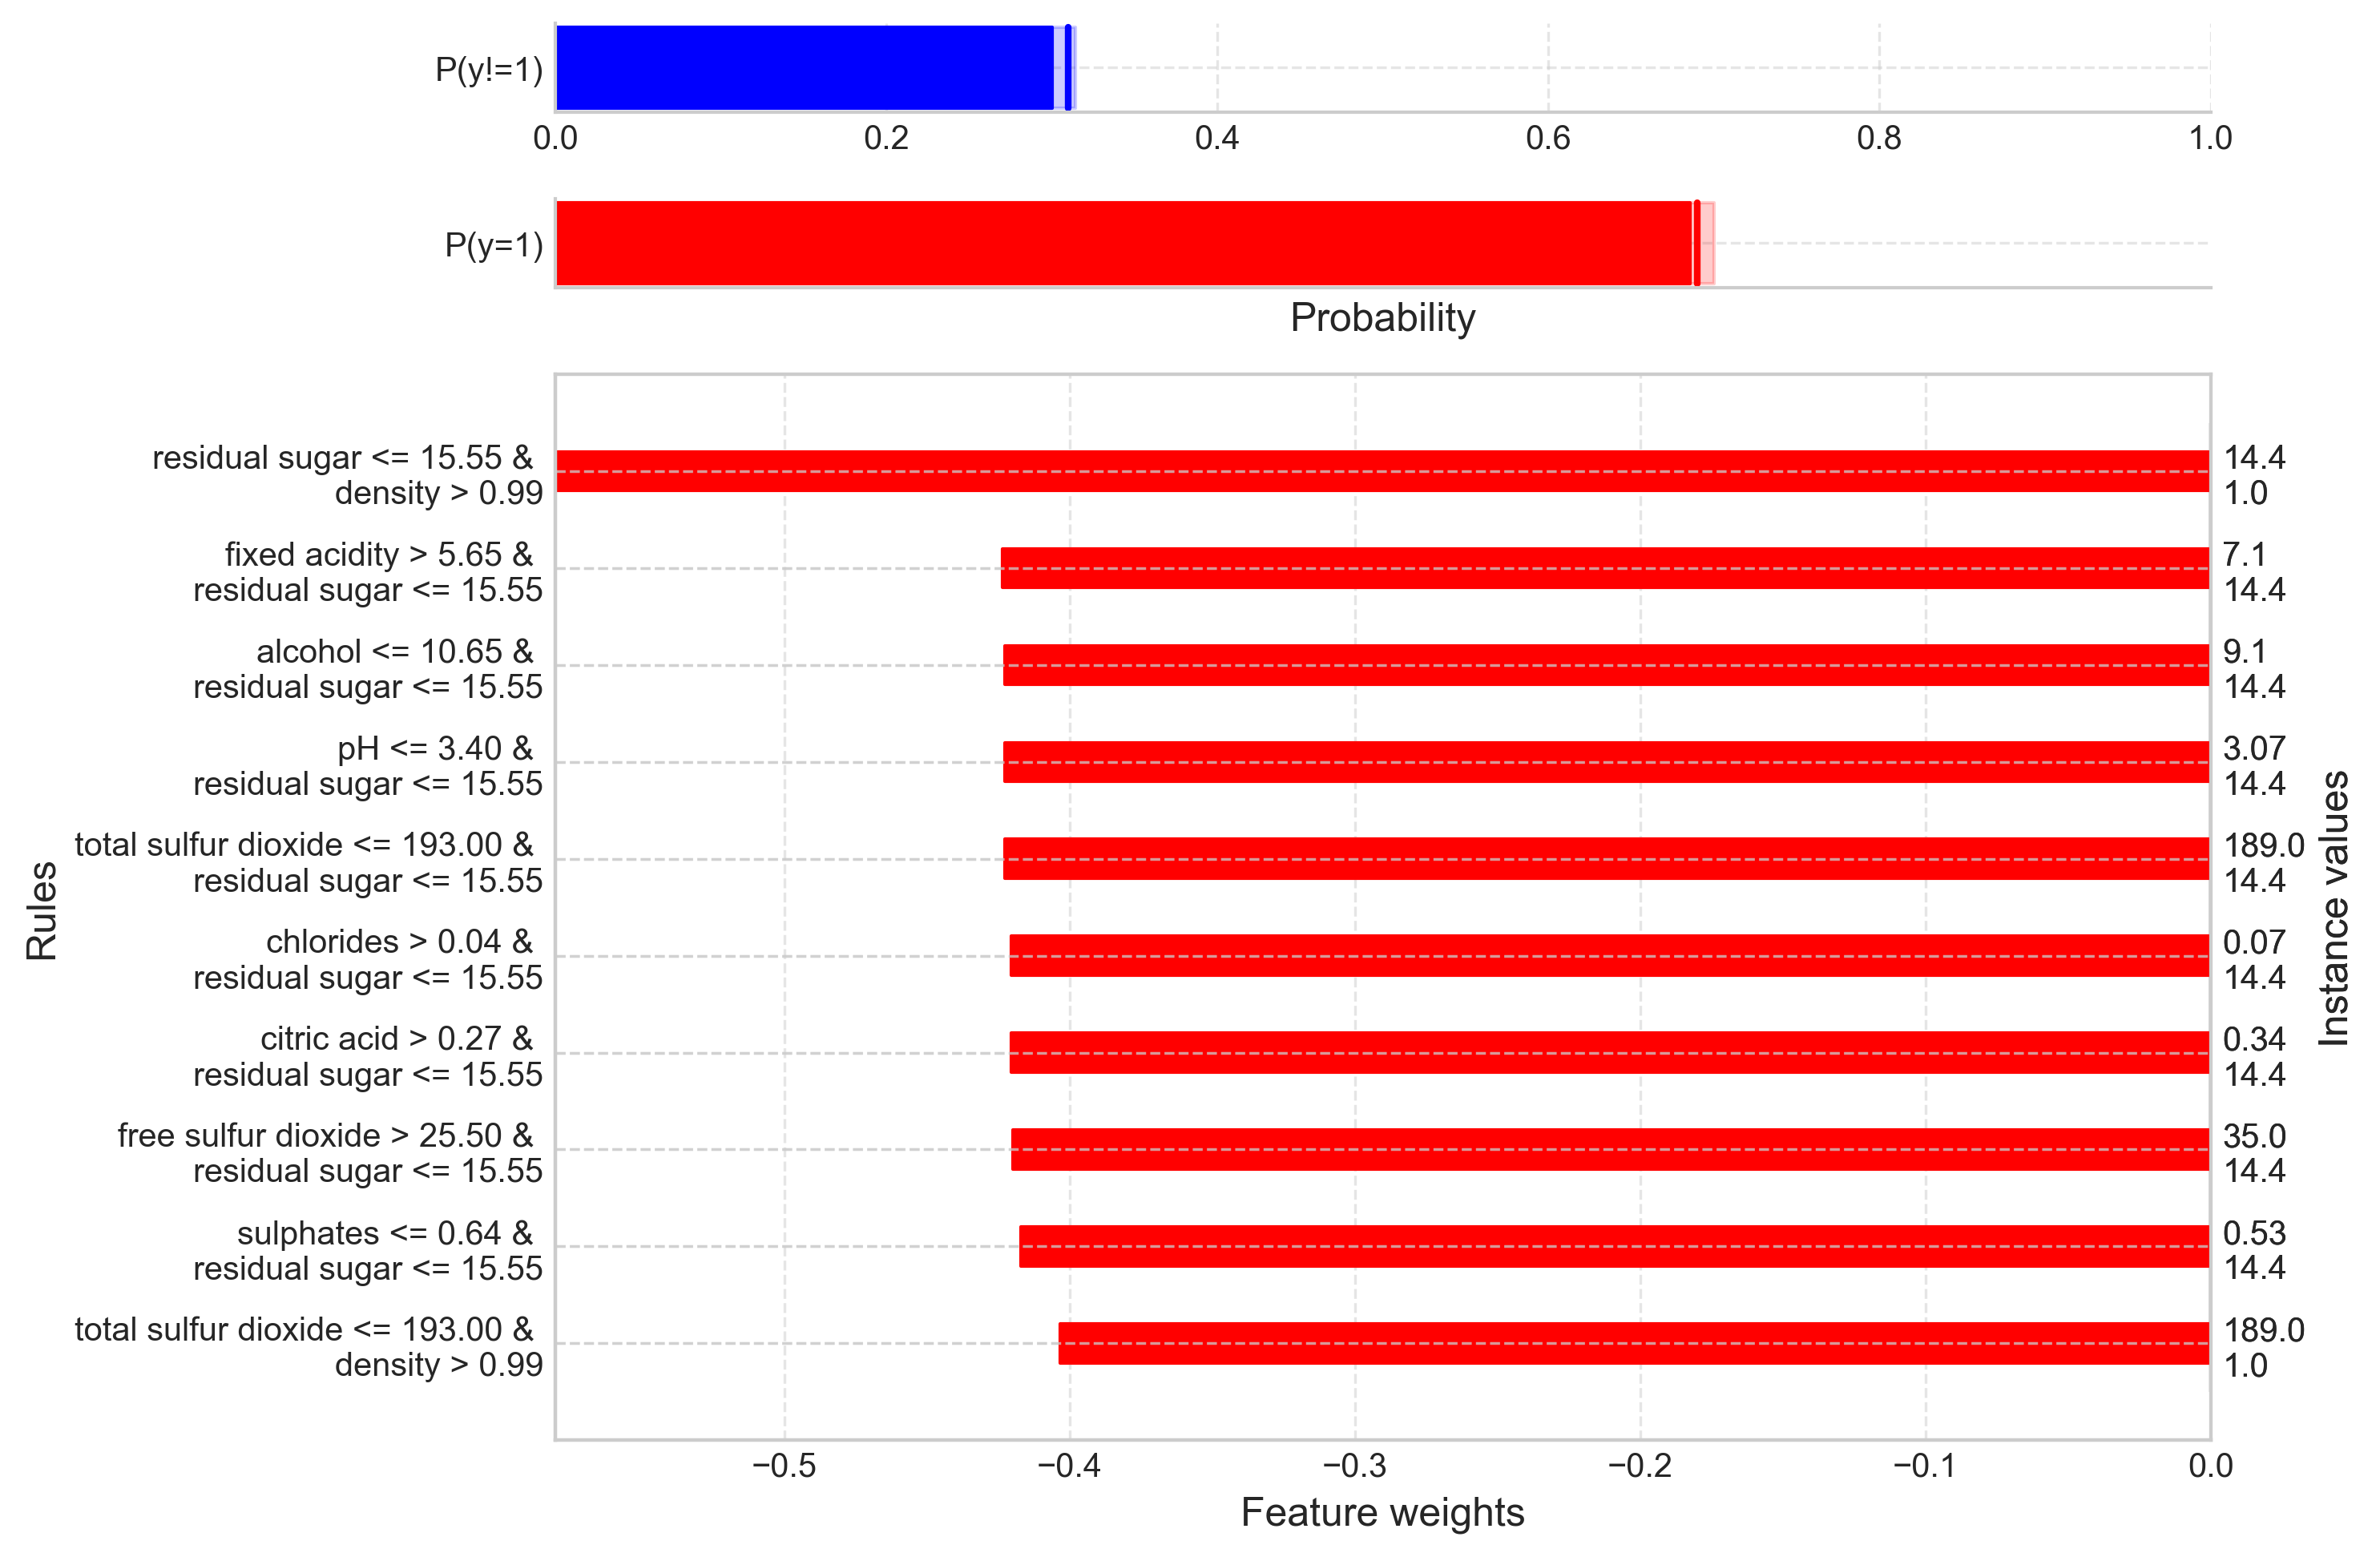

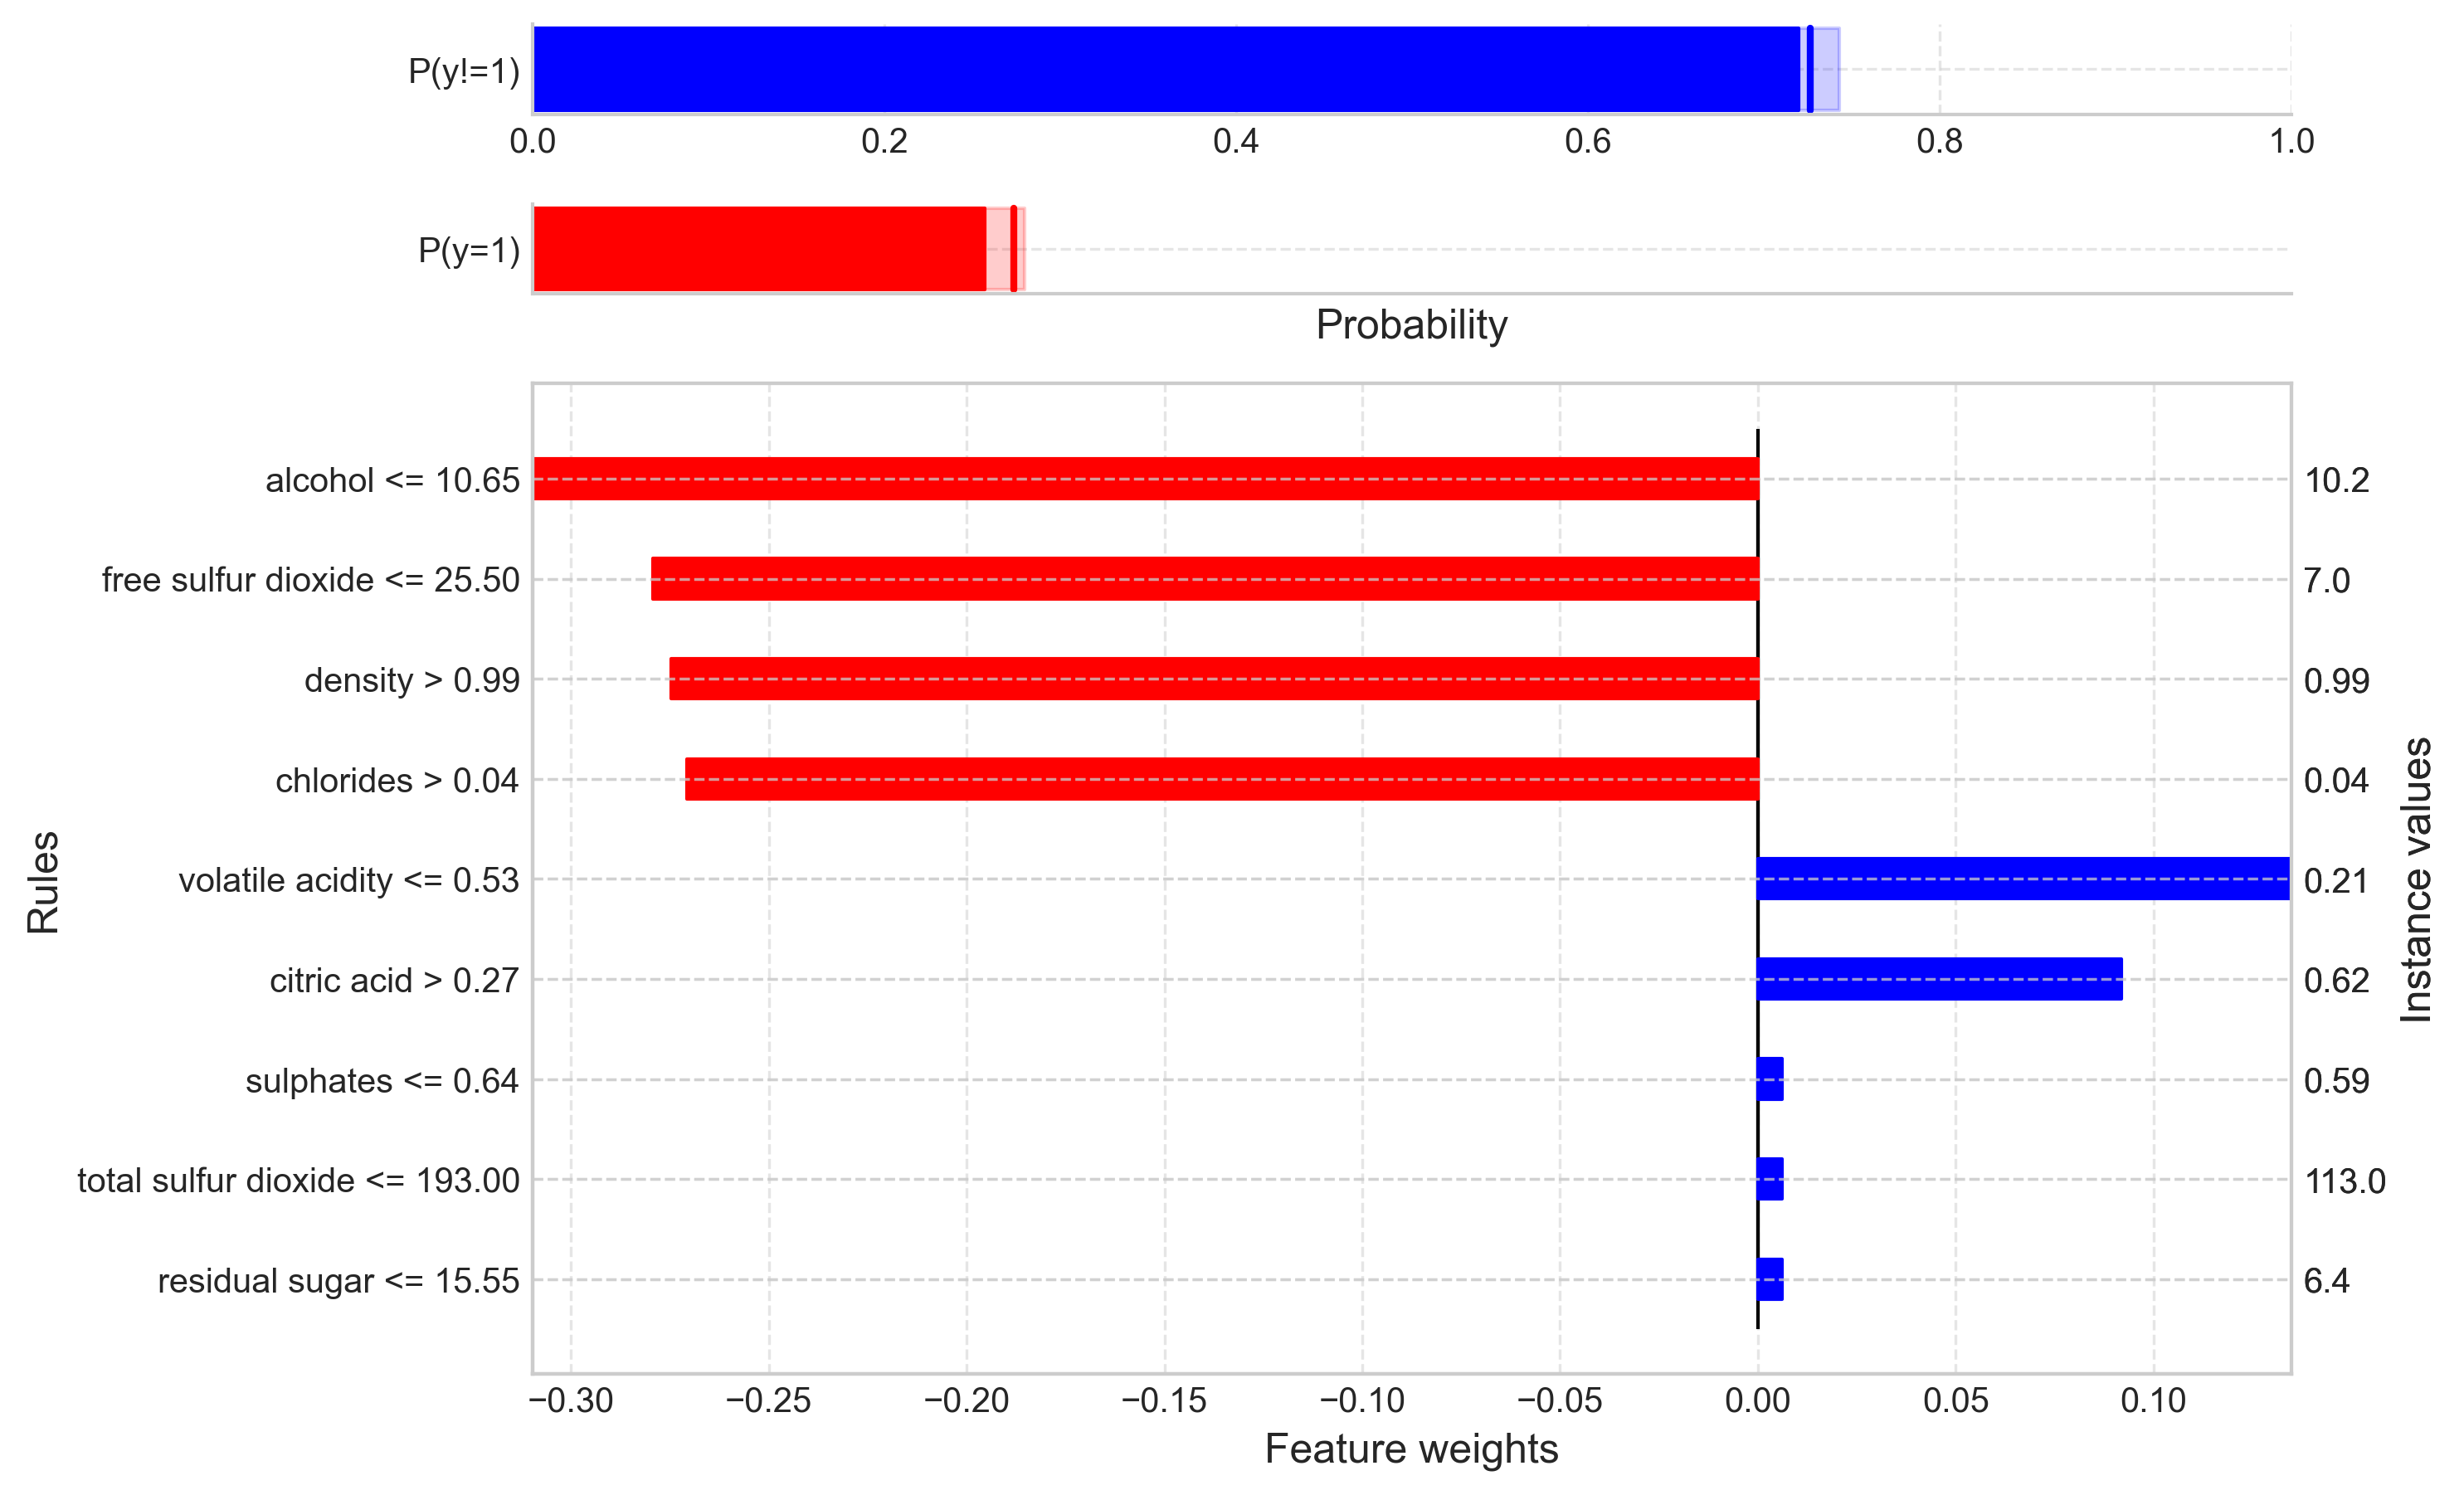

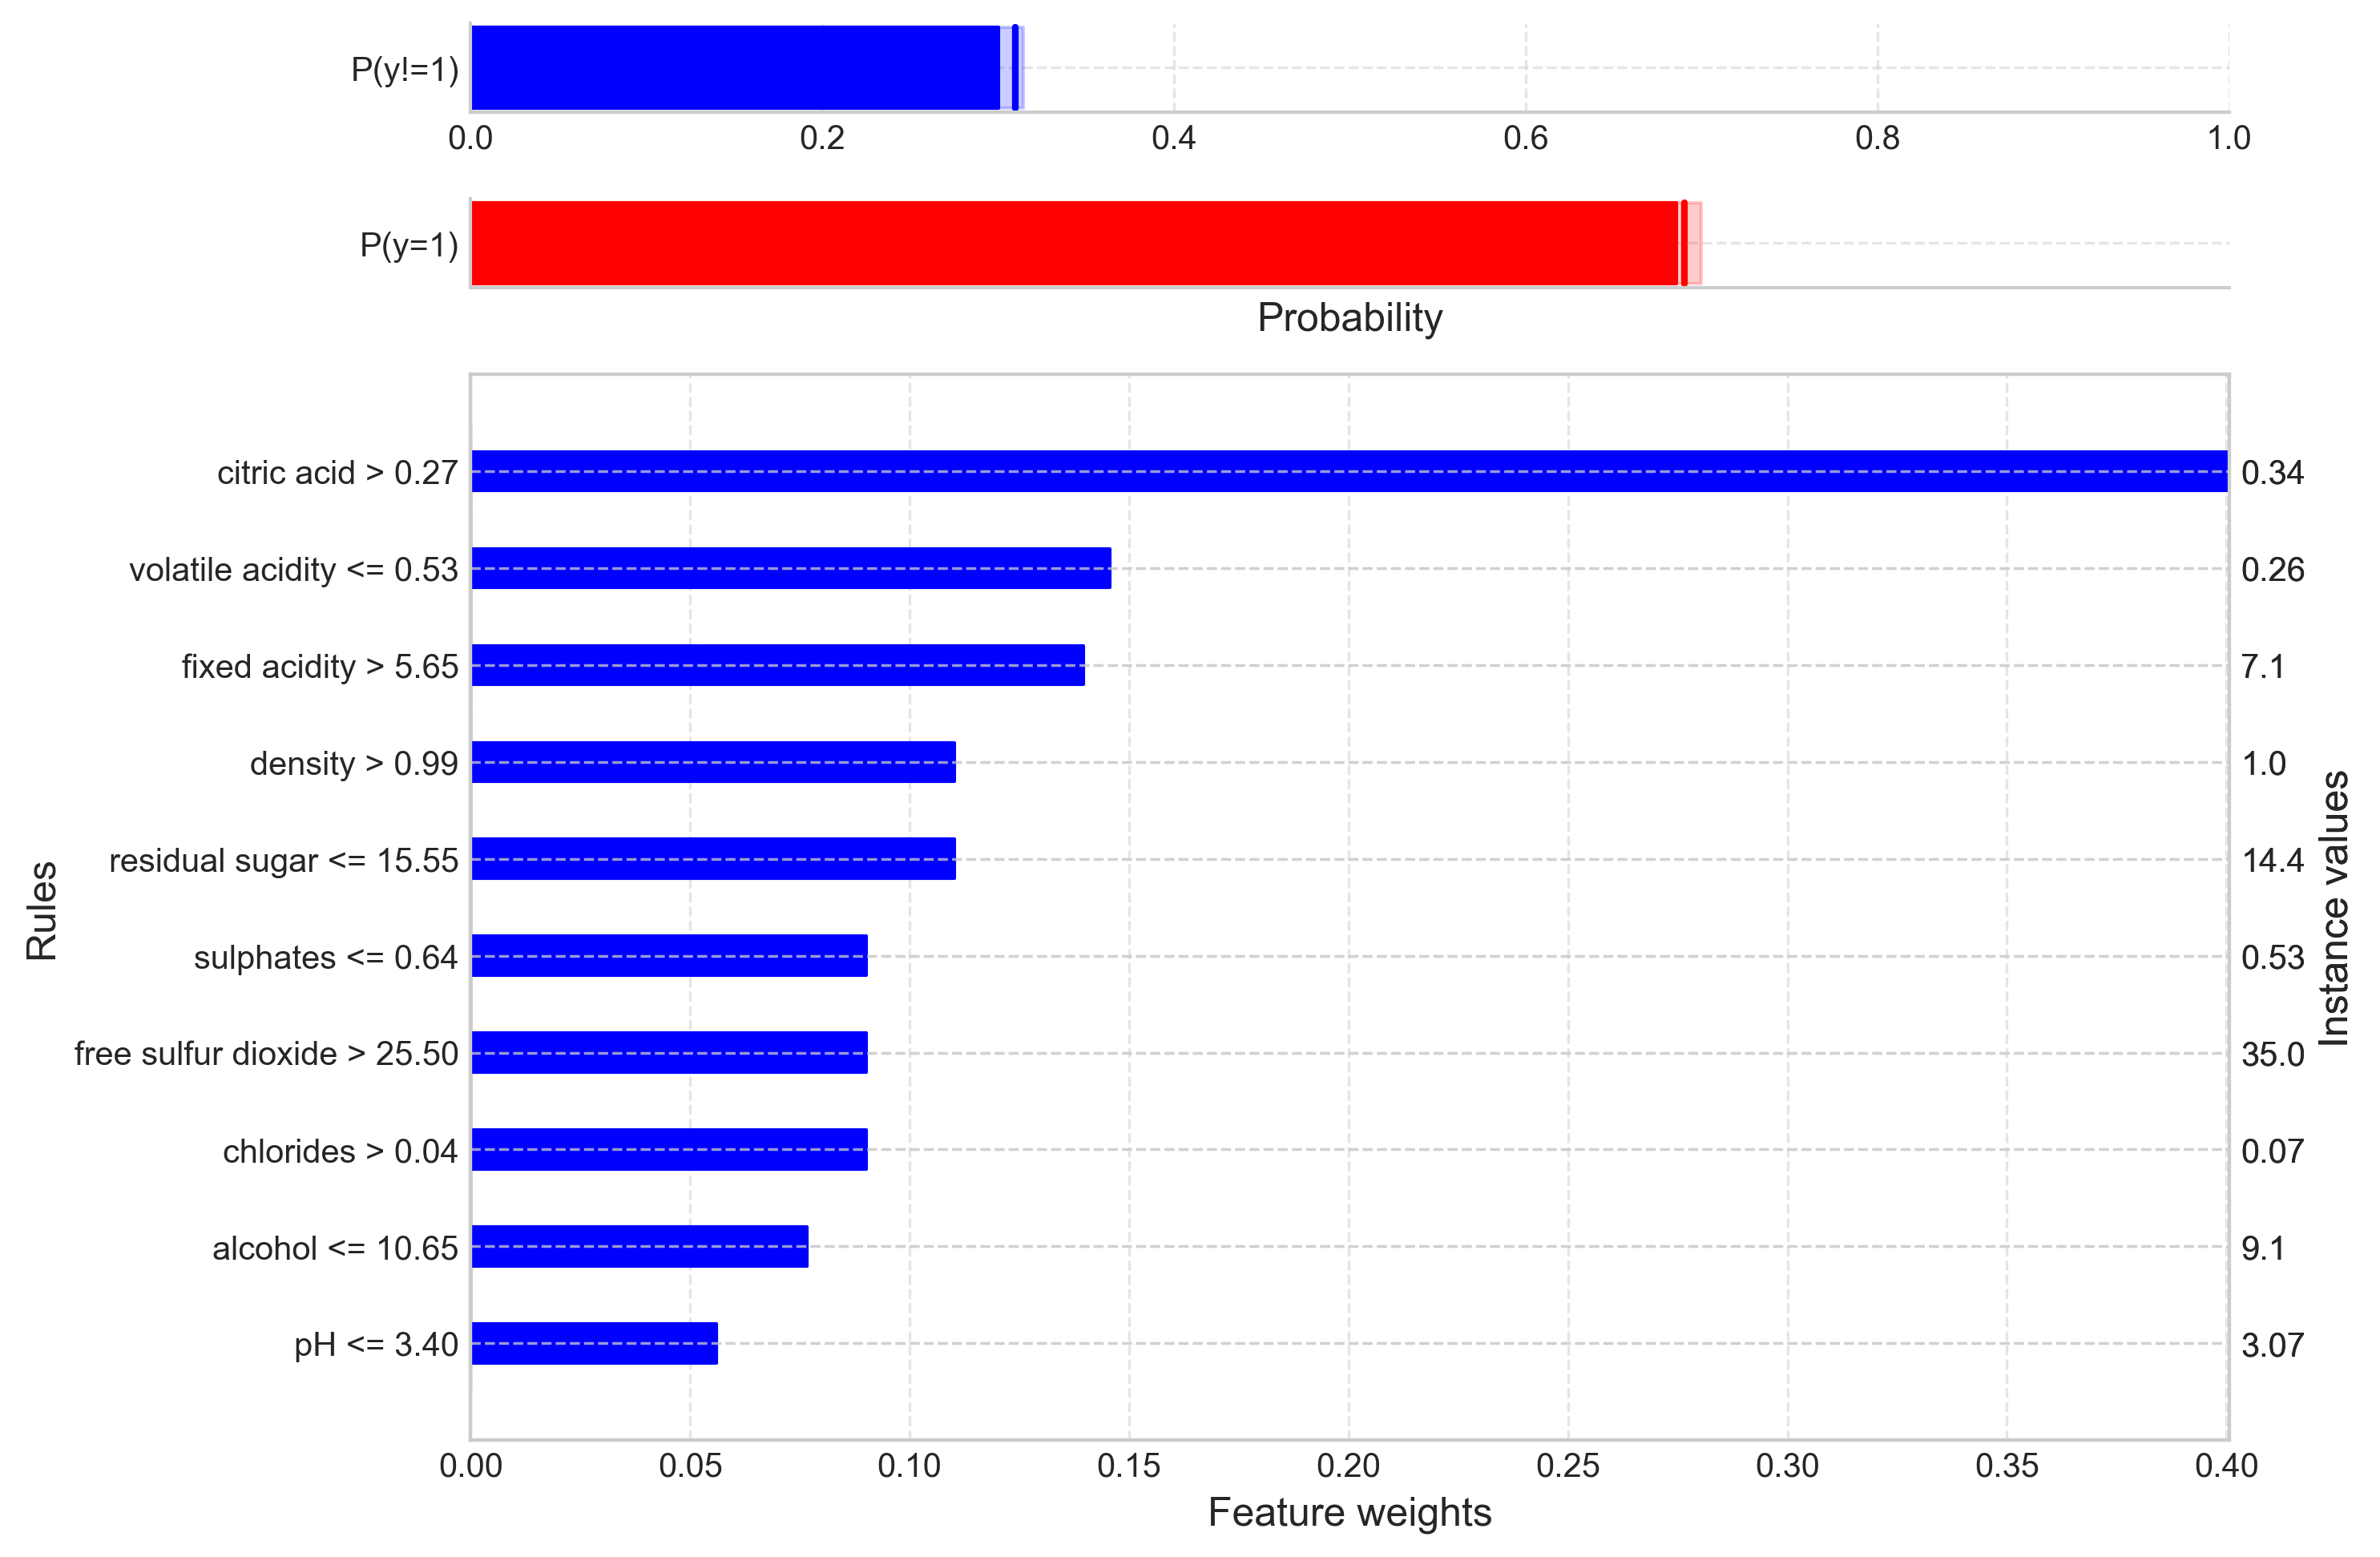

In [41]:
factual_explanations.add_conjunctions().plot()
factual_explanations.remove_conjunctions().plot()

#### Alternative Explanations with guard
An alternative to factual rules is to extract alternative rules. The guard applies to alternatives as well.

In [42]:
alternative_explanations = explainer.explore_alternatives(X_test)
display(explainer)

CalibratedExplainer(mode=classification, discretizer=EntropyDiscretizer(), learner=RandomForestClassifier(n_jobs=-1))

### Interpretation checklist — when to prefer alternatives
- Use alternative explanations when you want to know how *changes* to input features would change the prediction (counterfactual-style insight);
- Prefer alternatives when the factual explanation shows high uncertainty and you need mitigation options;
- Alternatives are useful for scenario planning and for prioritizing actionable feature changes;
- If you only need to explain *why* the current prediction occurred, start with factual explanations instead.

Alternatives are also visualized using the `plot`. Plotting an individual alternative explanation is done using `plot`, submitting the index to plot. Adding or removing conjunctions is done as before. 

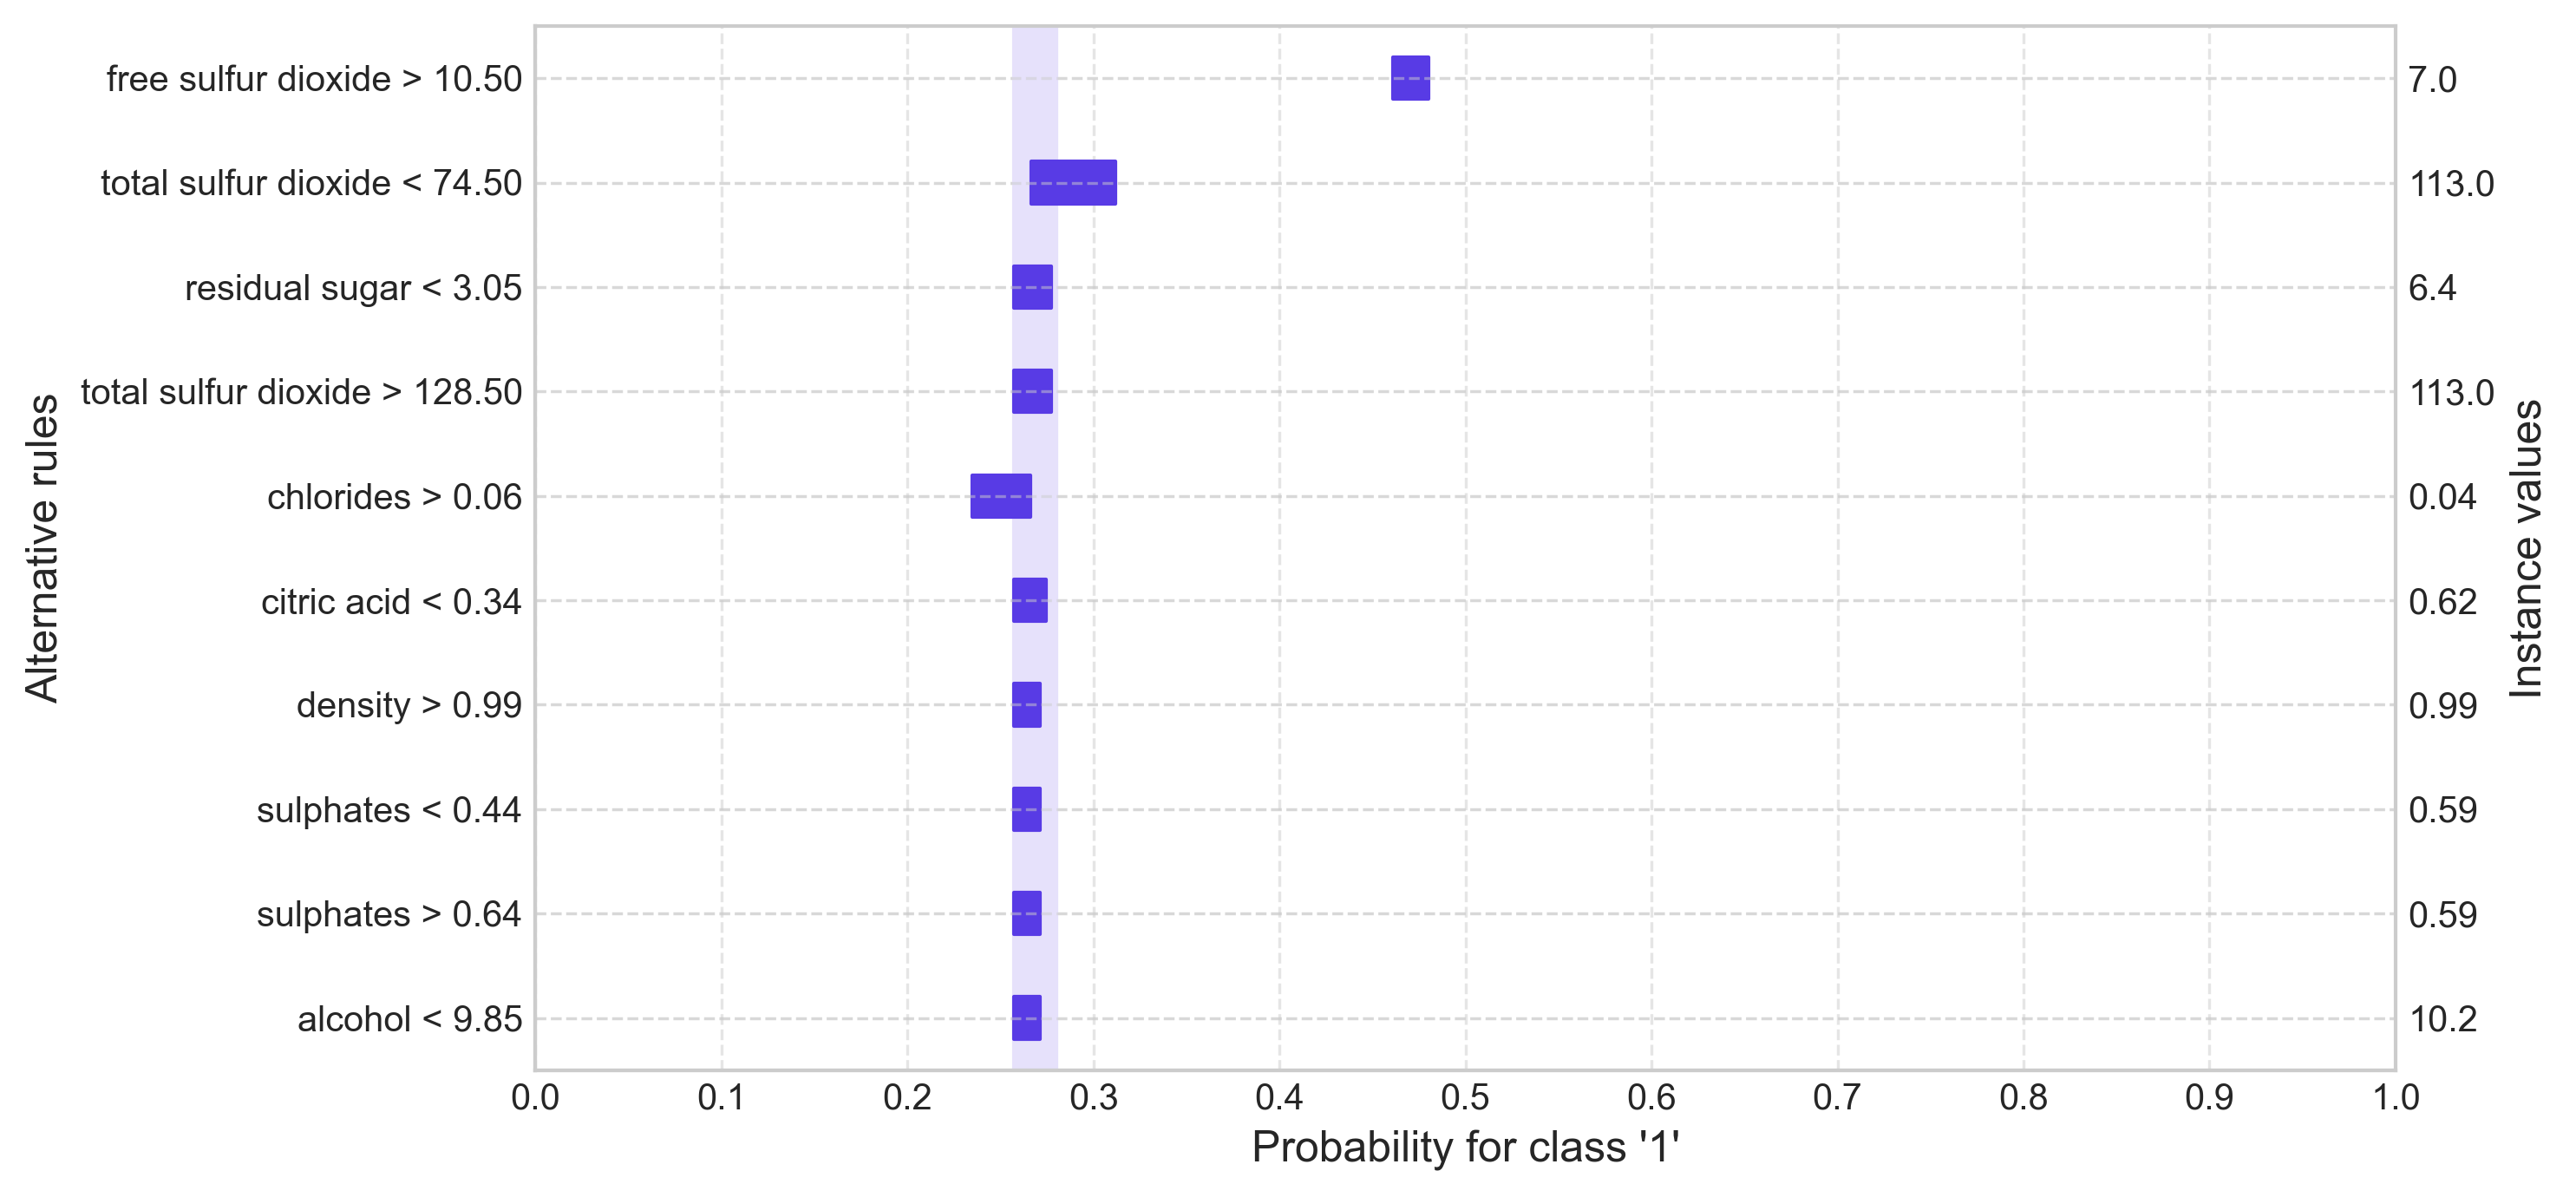

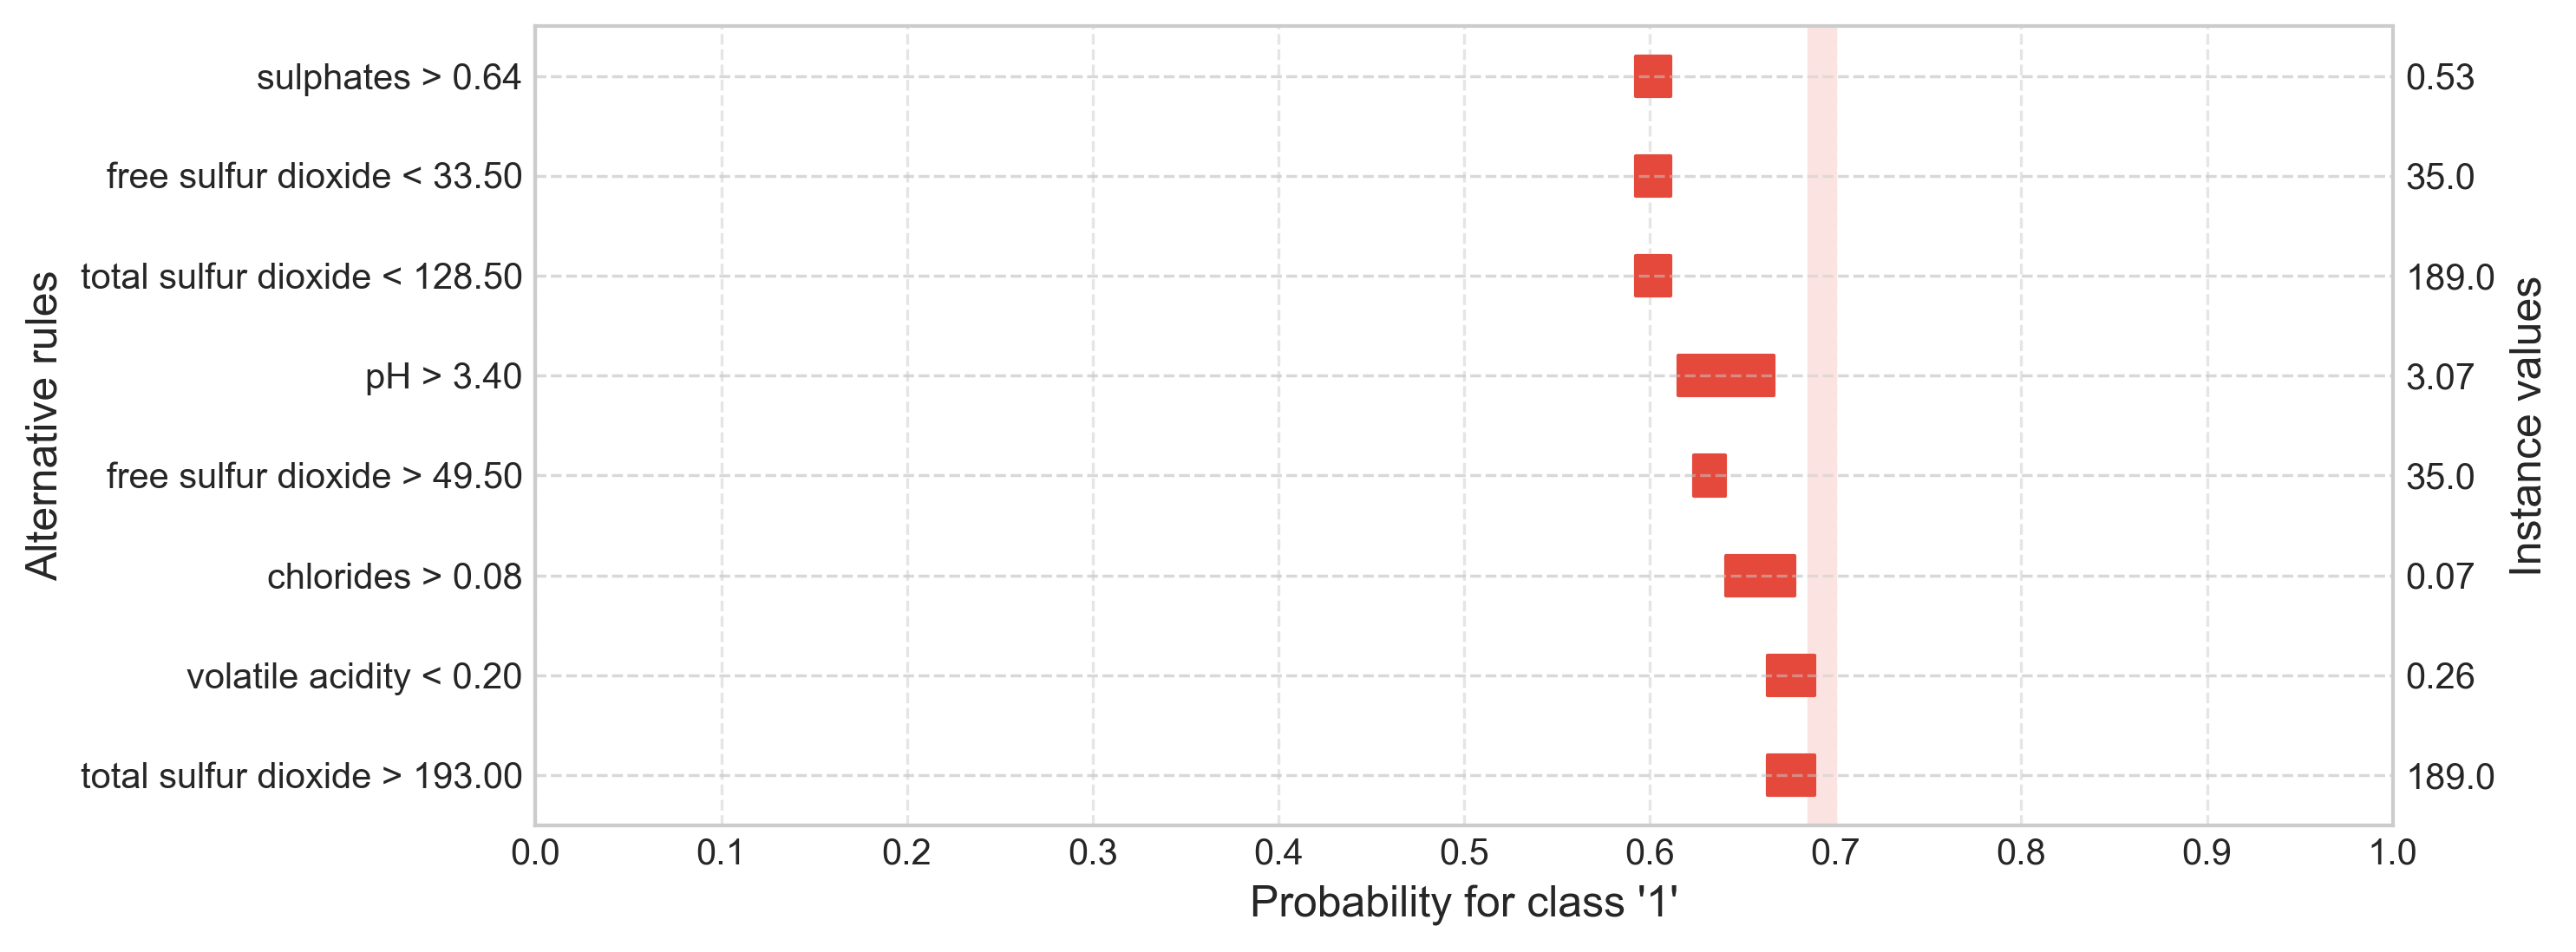

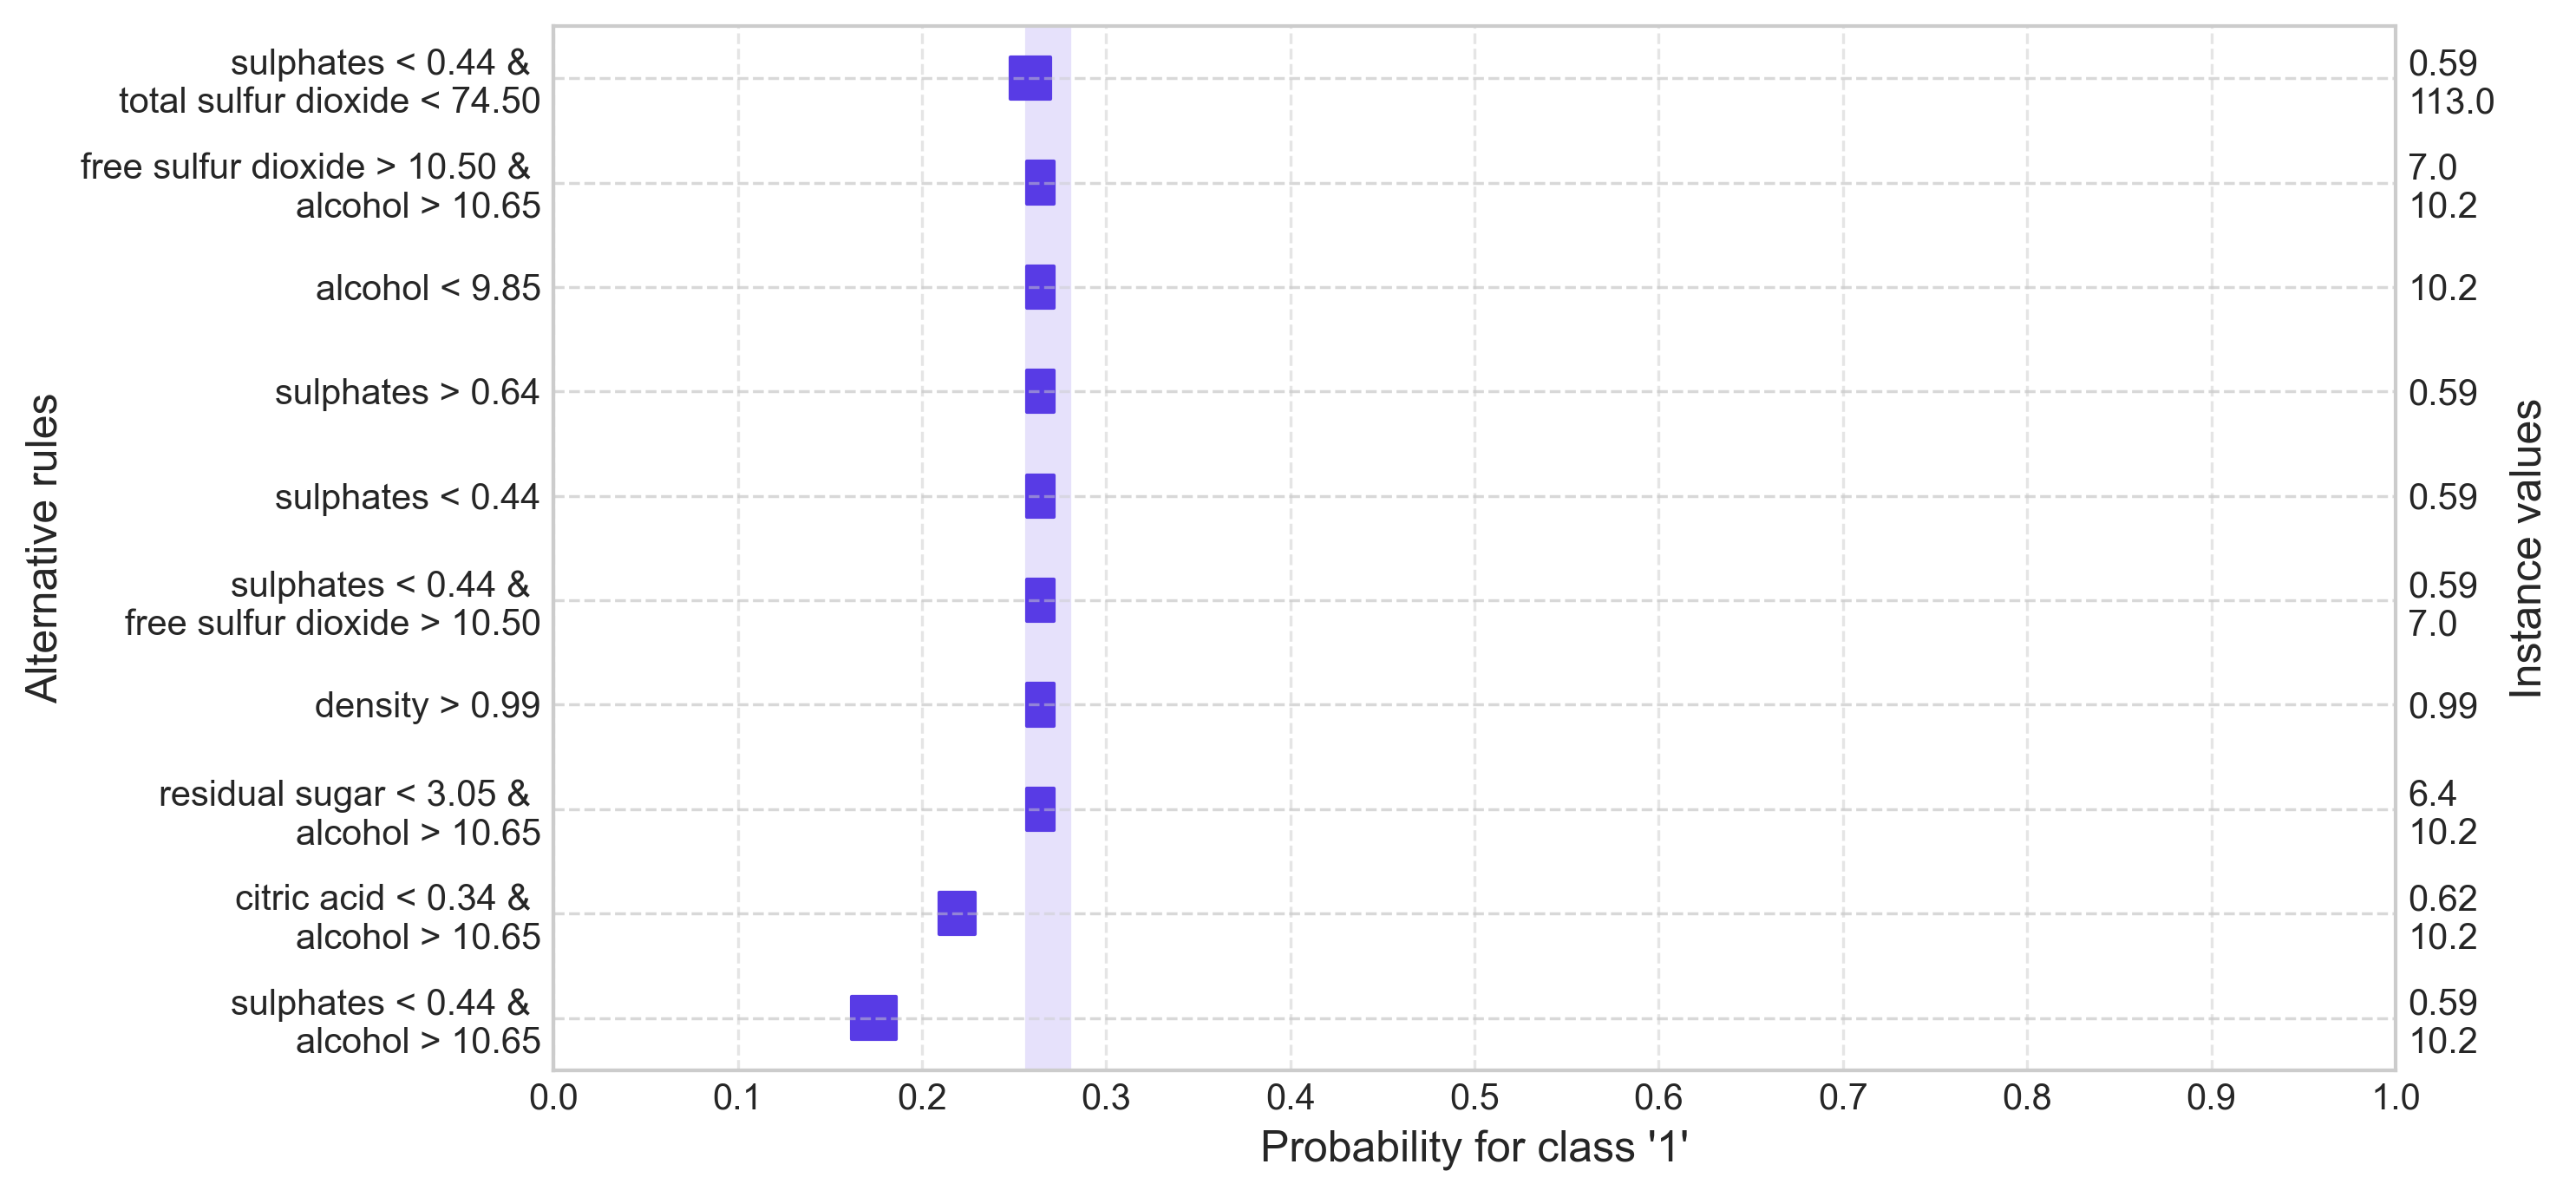

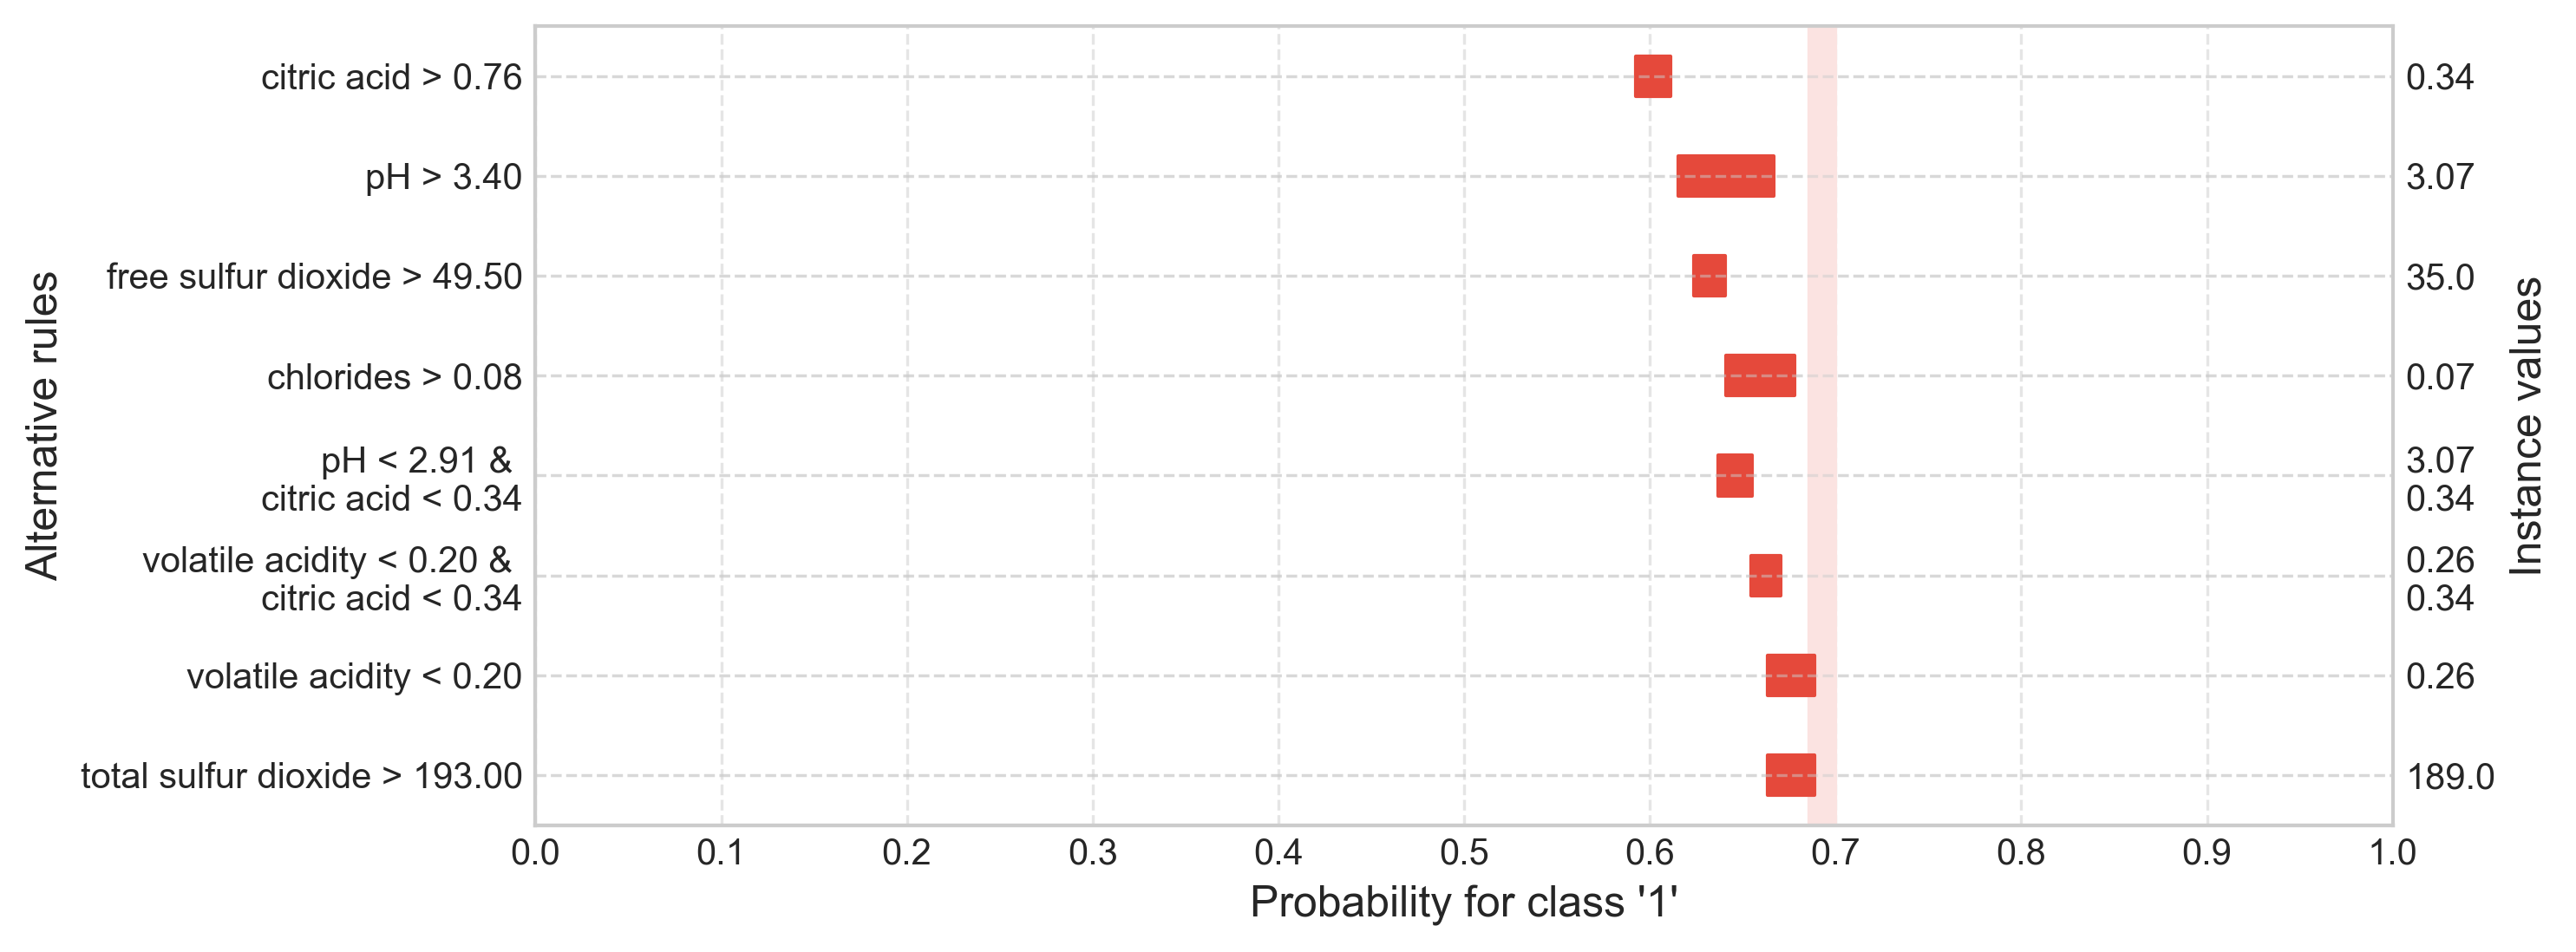

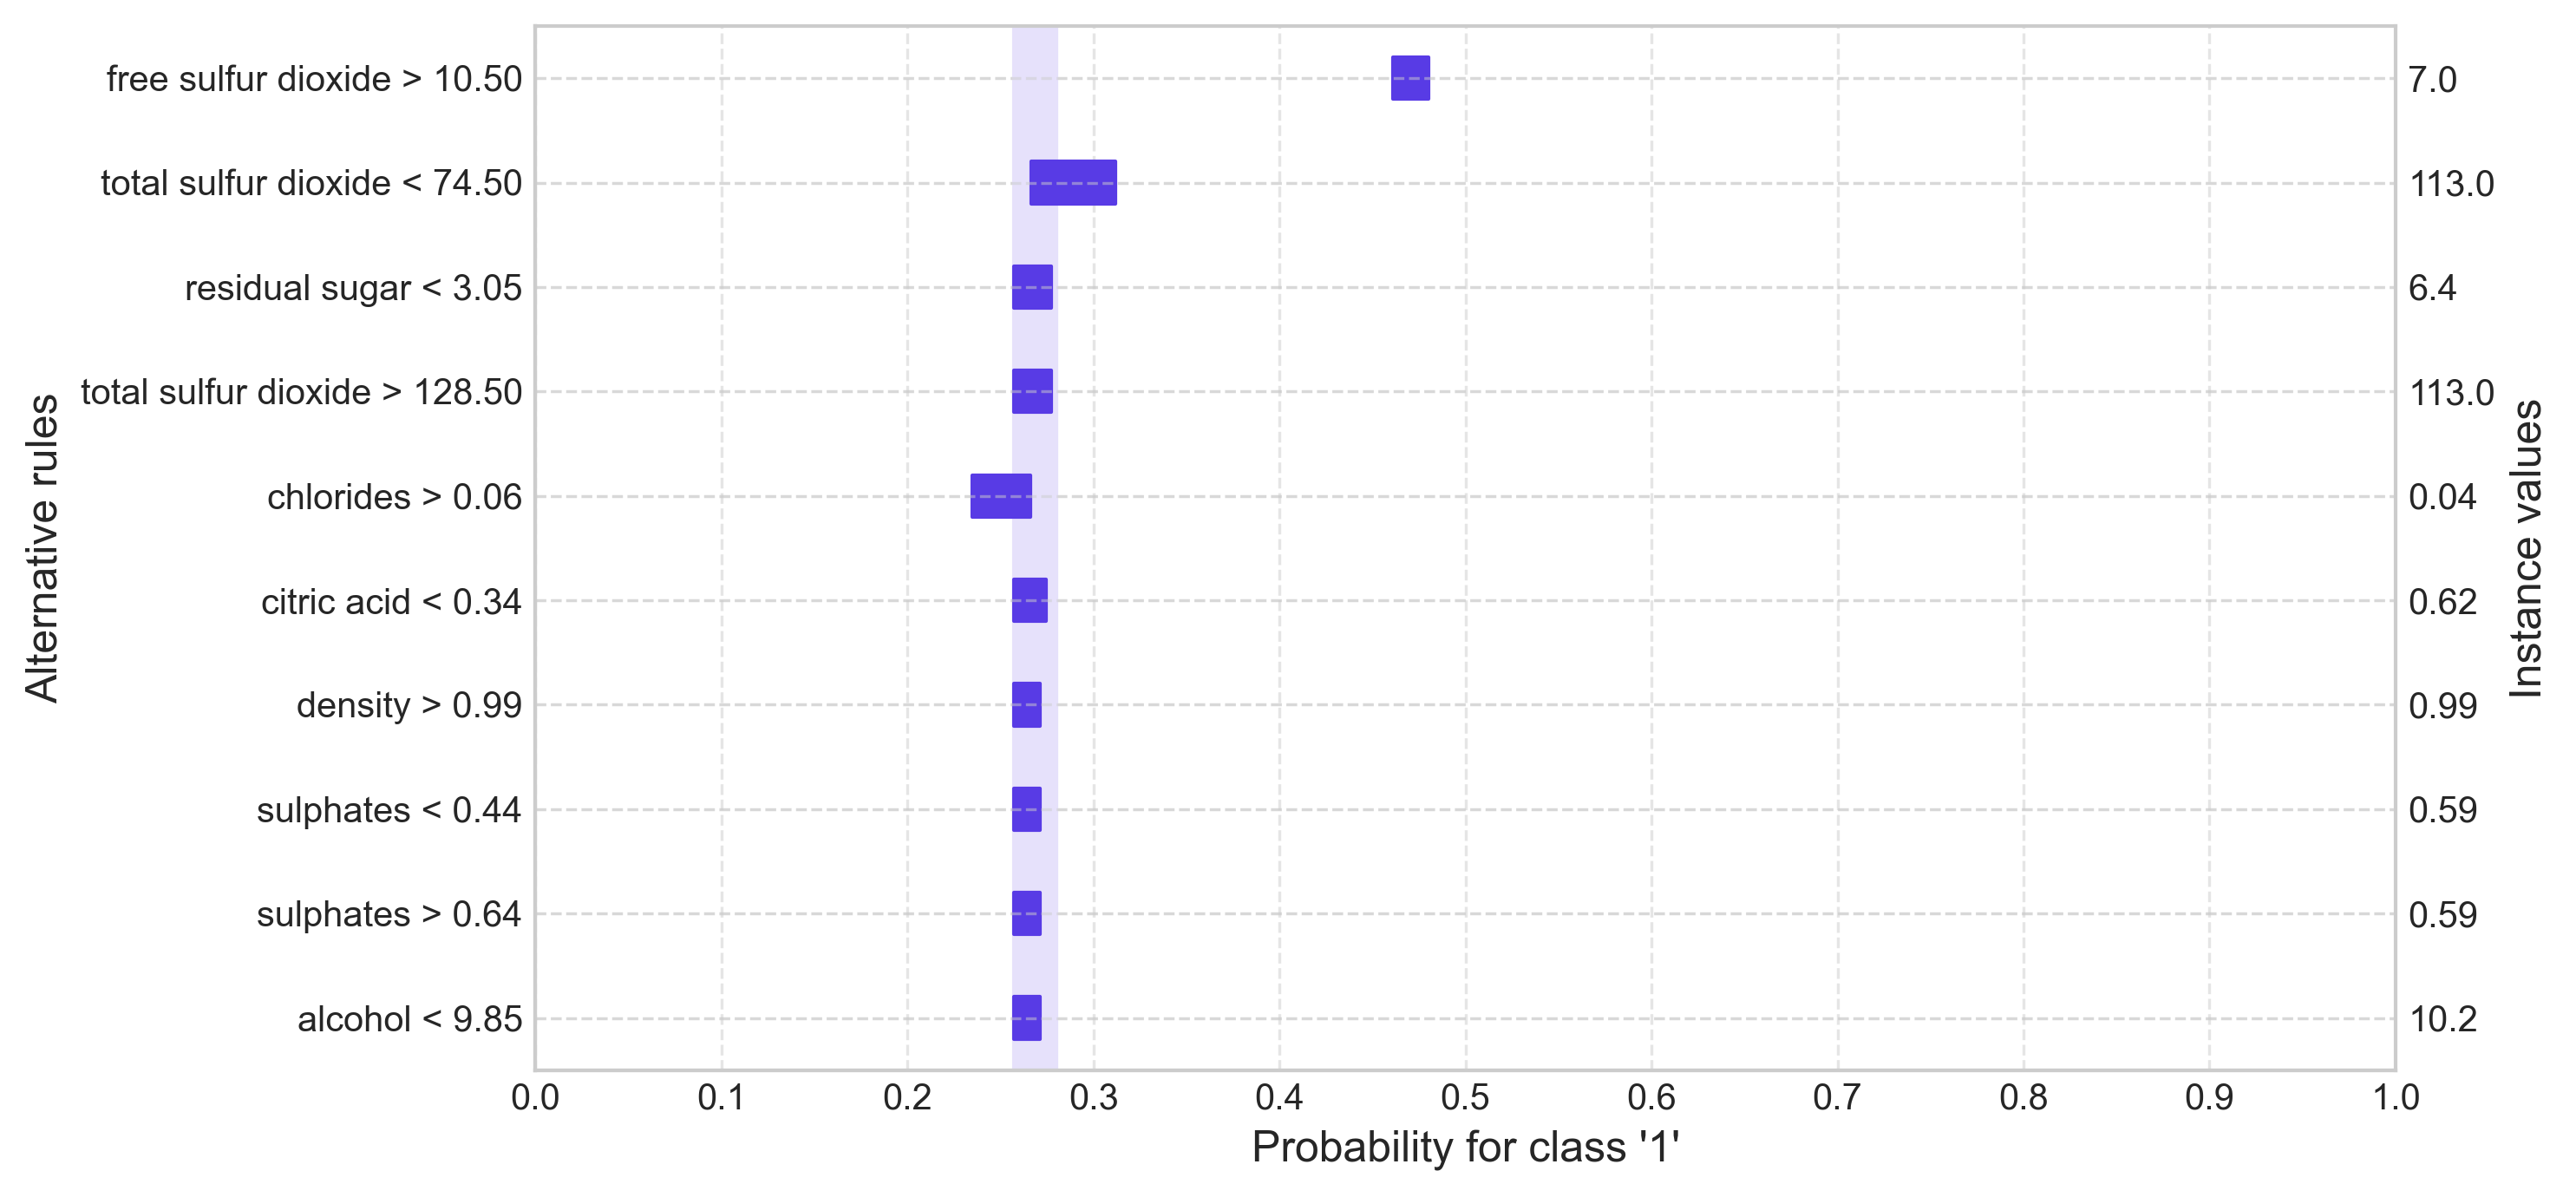

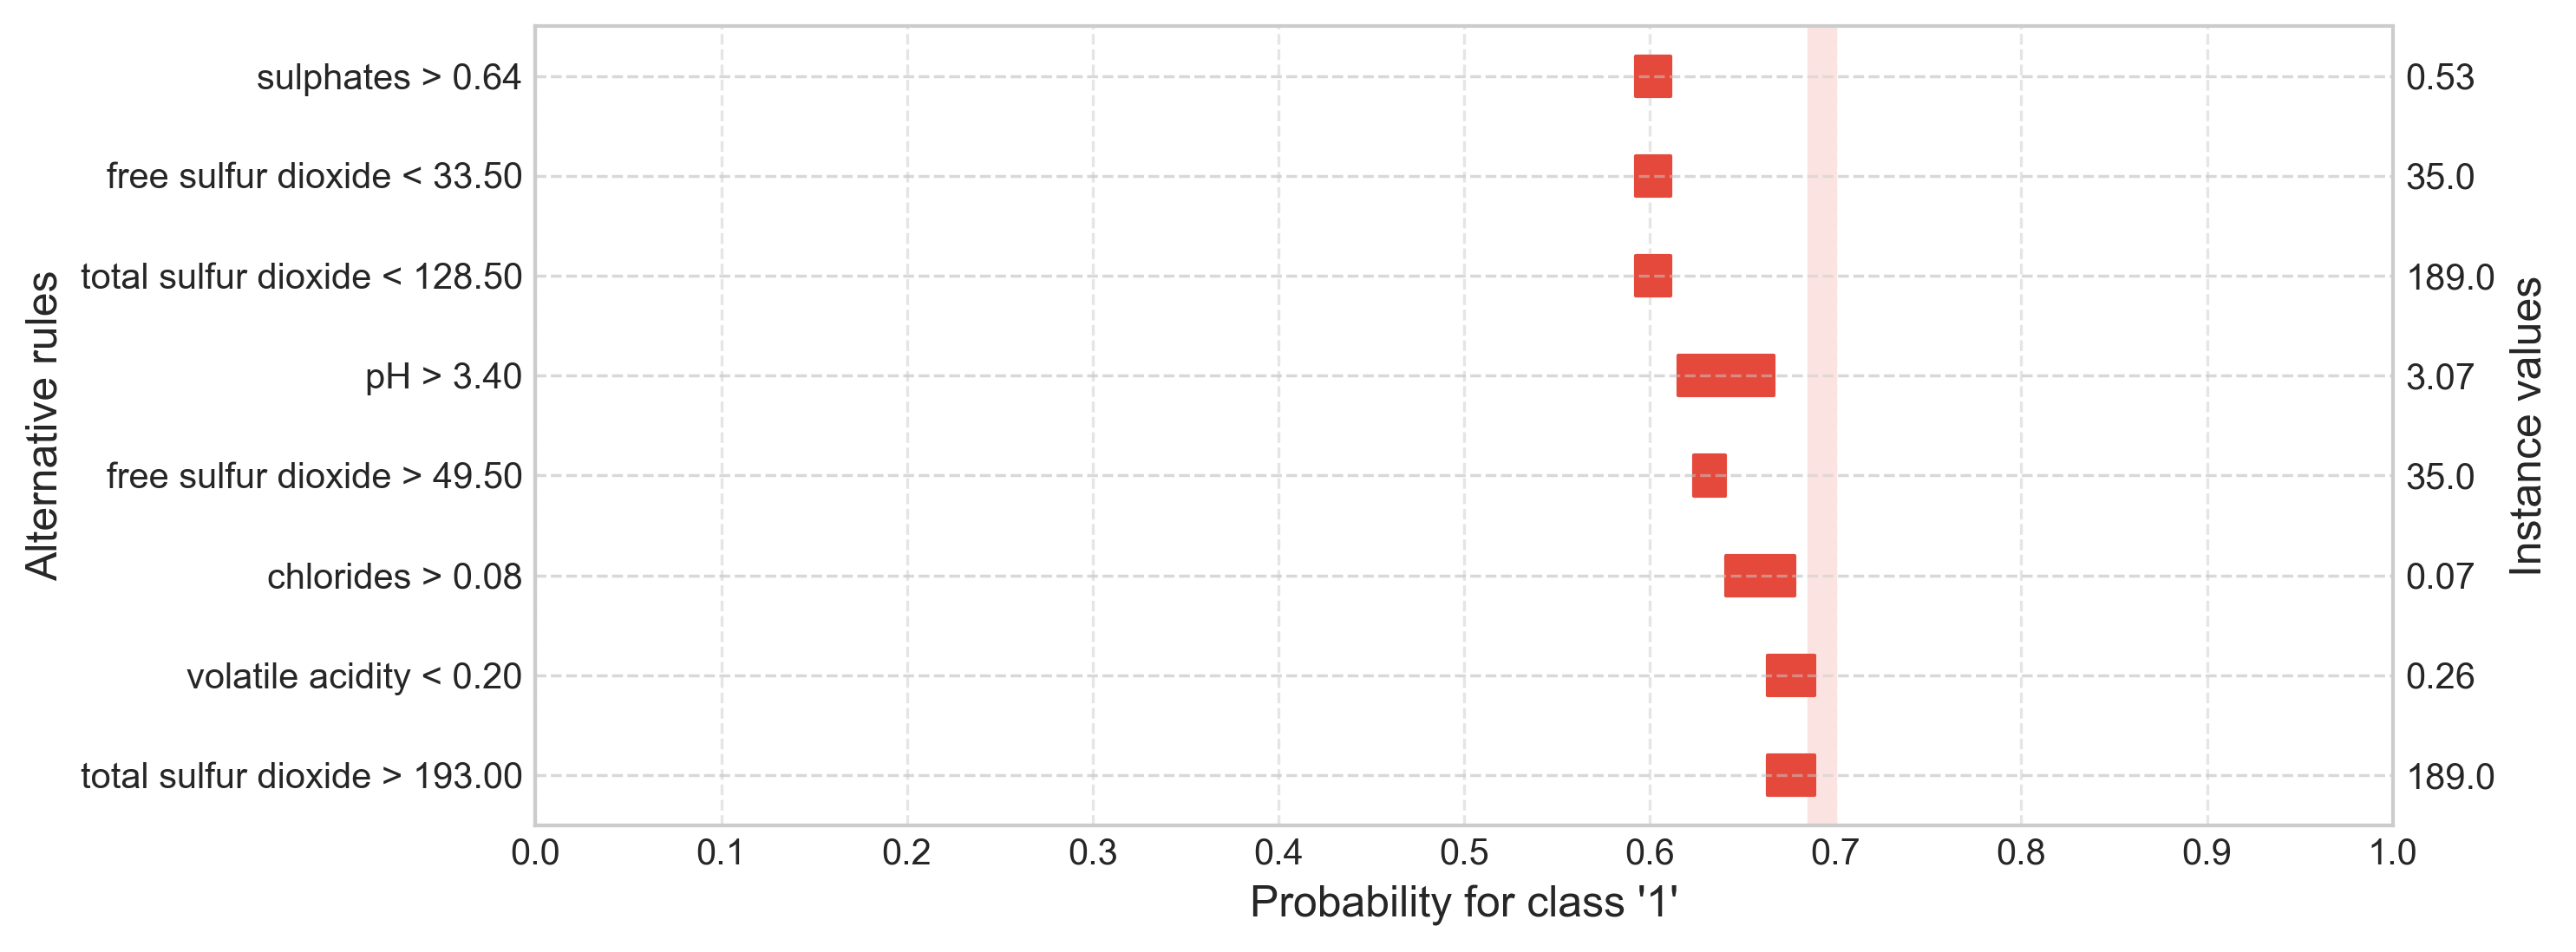

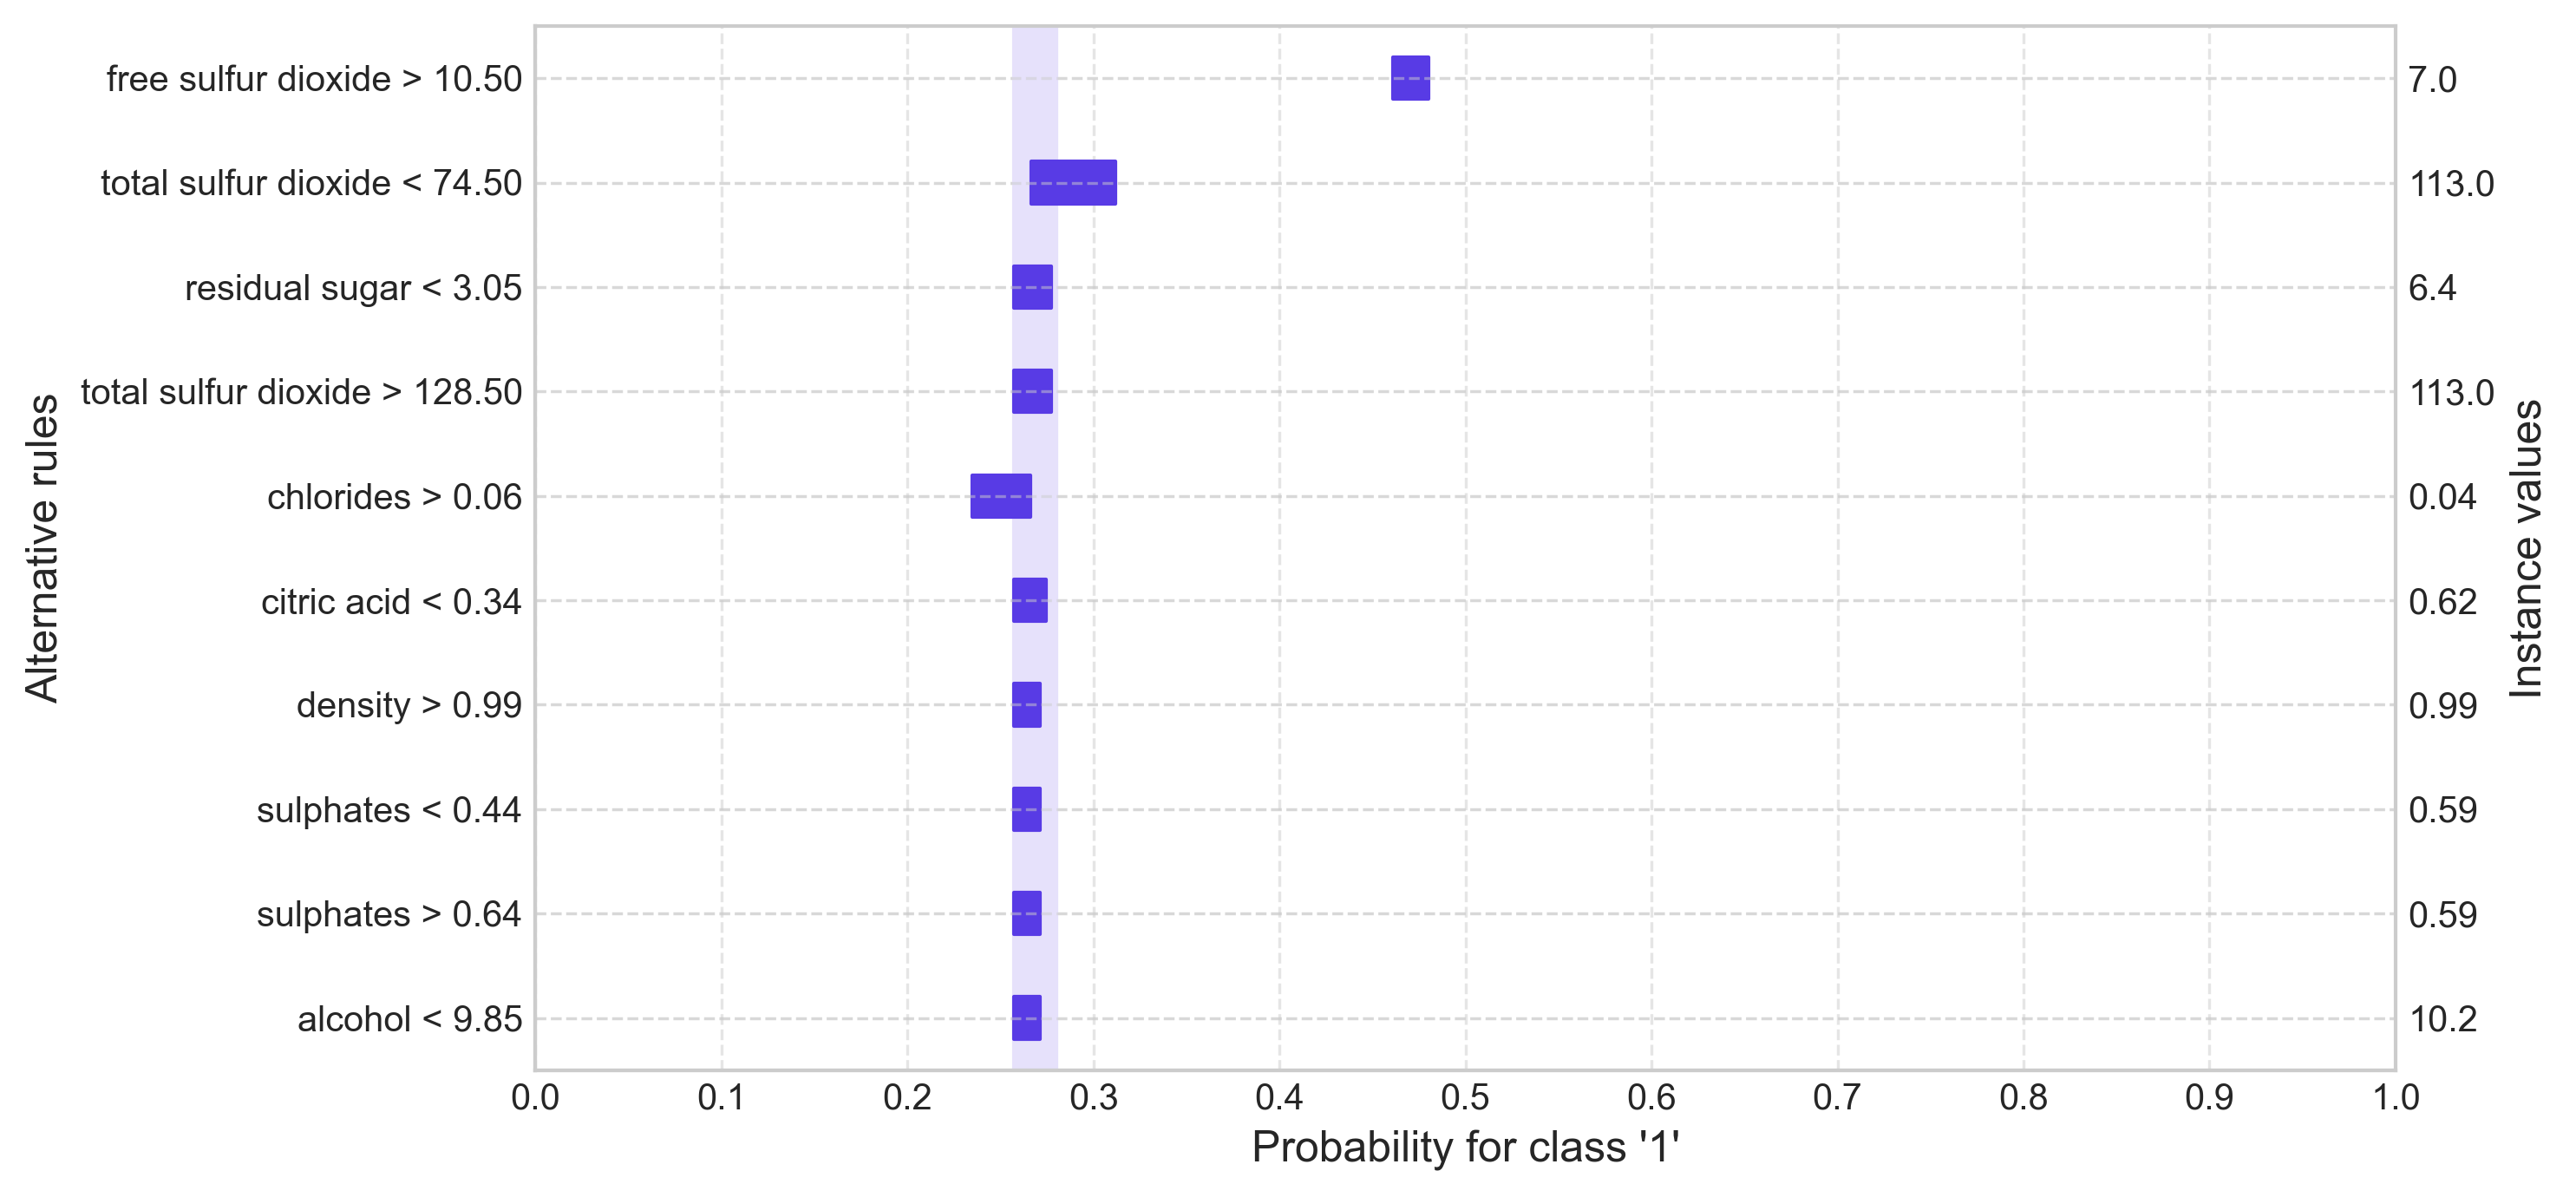

In [43]:
alternative_explanations.plot()
alternative_explanations.add_conjunctions().plot()
alternative_explanations.remove_conjunctions().plot()

alternative_explanations.plot(0)

`calibrated_explanations` supports multiclass which is demonstrated in [demo_multiclass](https://github.com/Moffran/calibrated_explanations/blob/main/notebooks/demo_multiclass.ipynb). That notebook also demonstrates how both feature names and target and categorical labels can be added to improve the interpretability. 
## Regression with guard
Extracting explanations for regression is very similar to how it is done for classification. First we load and divide the dataset.   

In [44]:
dataset = fetch_openml(name="house_sales", version=3)

X = dataset.data.values.astype(float)
y = dataset.target.values / 1000
y_filter = y < 500
X = X[y_filter, :]
y = y[y_filter]

feature_names = dataset.feature_names
categorical_labels = {5: {0: "False", 1: "True"}}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=2, random_state=42, stratify=X[:, 5]
)

X_prop_train, X_cal, y_prop_train, y_cal = train_test_split(
    X_train, y_train, random_state=42, test_size=500, stratify=X_train[:, 5]
)

Let us now fit a `RandomForestRegressor` from
[sklearn](https://scikit-learn.org) to the proper training
set:

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_prop_train, y_prop_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Factual Explanations with guard
Define a `CalibratedExplainer` object using the new model and data with guard enabled. The `mode` parameter must be explicitly set to regression. By default, explanations based on a two-sided interval with 90% confidence are provided. 

In [46]:
from crepes.extras import DifficultyEstimator
from calibrated_explanations.guards import ConformalRegionOracle

# For regression, set mode="reg" and provide threshold if needed
guard = ConformalRegionOracle(alpha=0.1, mode="reg", threshold=300, n_clusters=5, random_state=42)

explainer = CalibratedExplainer(
    rf,
    X_cal,
    y_cal,
    mode="regression",
    feature_names=feature_names,
    categorical_labels=categorical_labels,
    guard=guard,
)
explainer.set_difficulty_estimator(DifficultyEstimator().fit(X=X_train, learner=rf, scaler=True))

factual_explanations = explainer.explain_factual(X_test)

c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\loftuw\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Regression also offer both regular and uncertainty plots for factual explanations with or without conjunctive rules, in almost exactly the same way as for classification. The guard ensures perturbations stay within distribution.

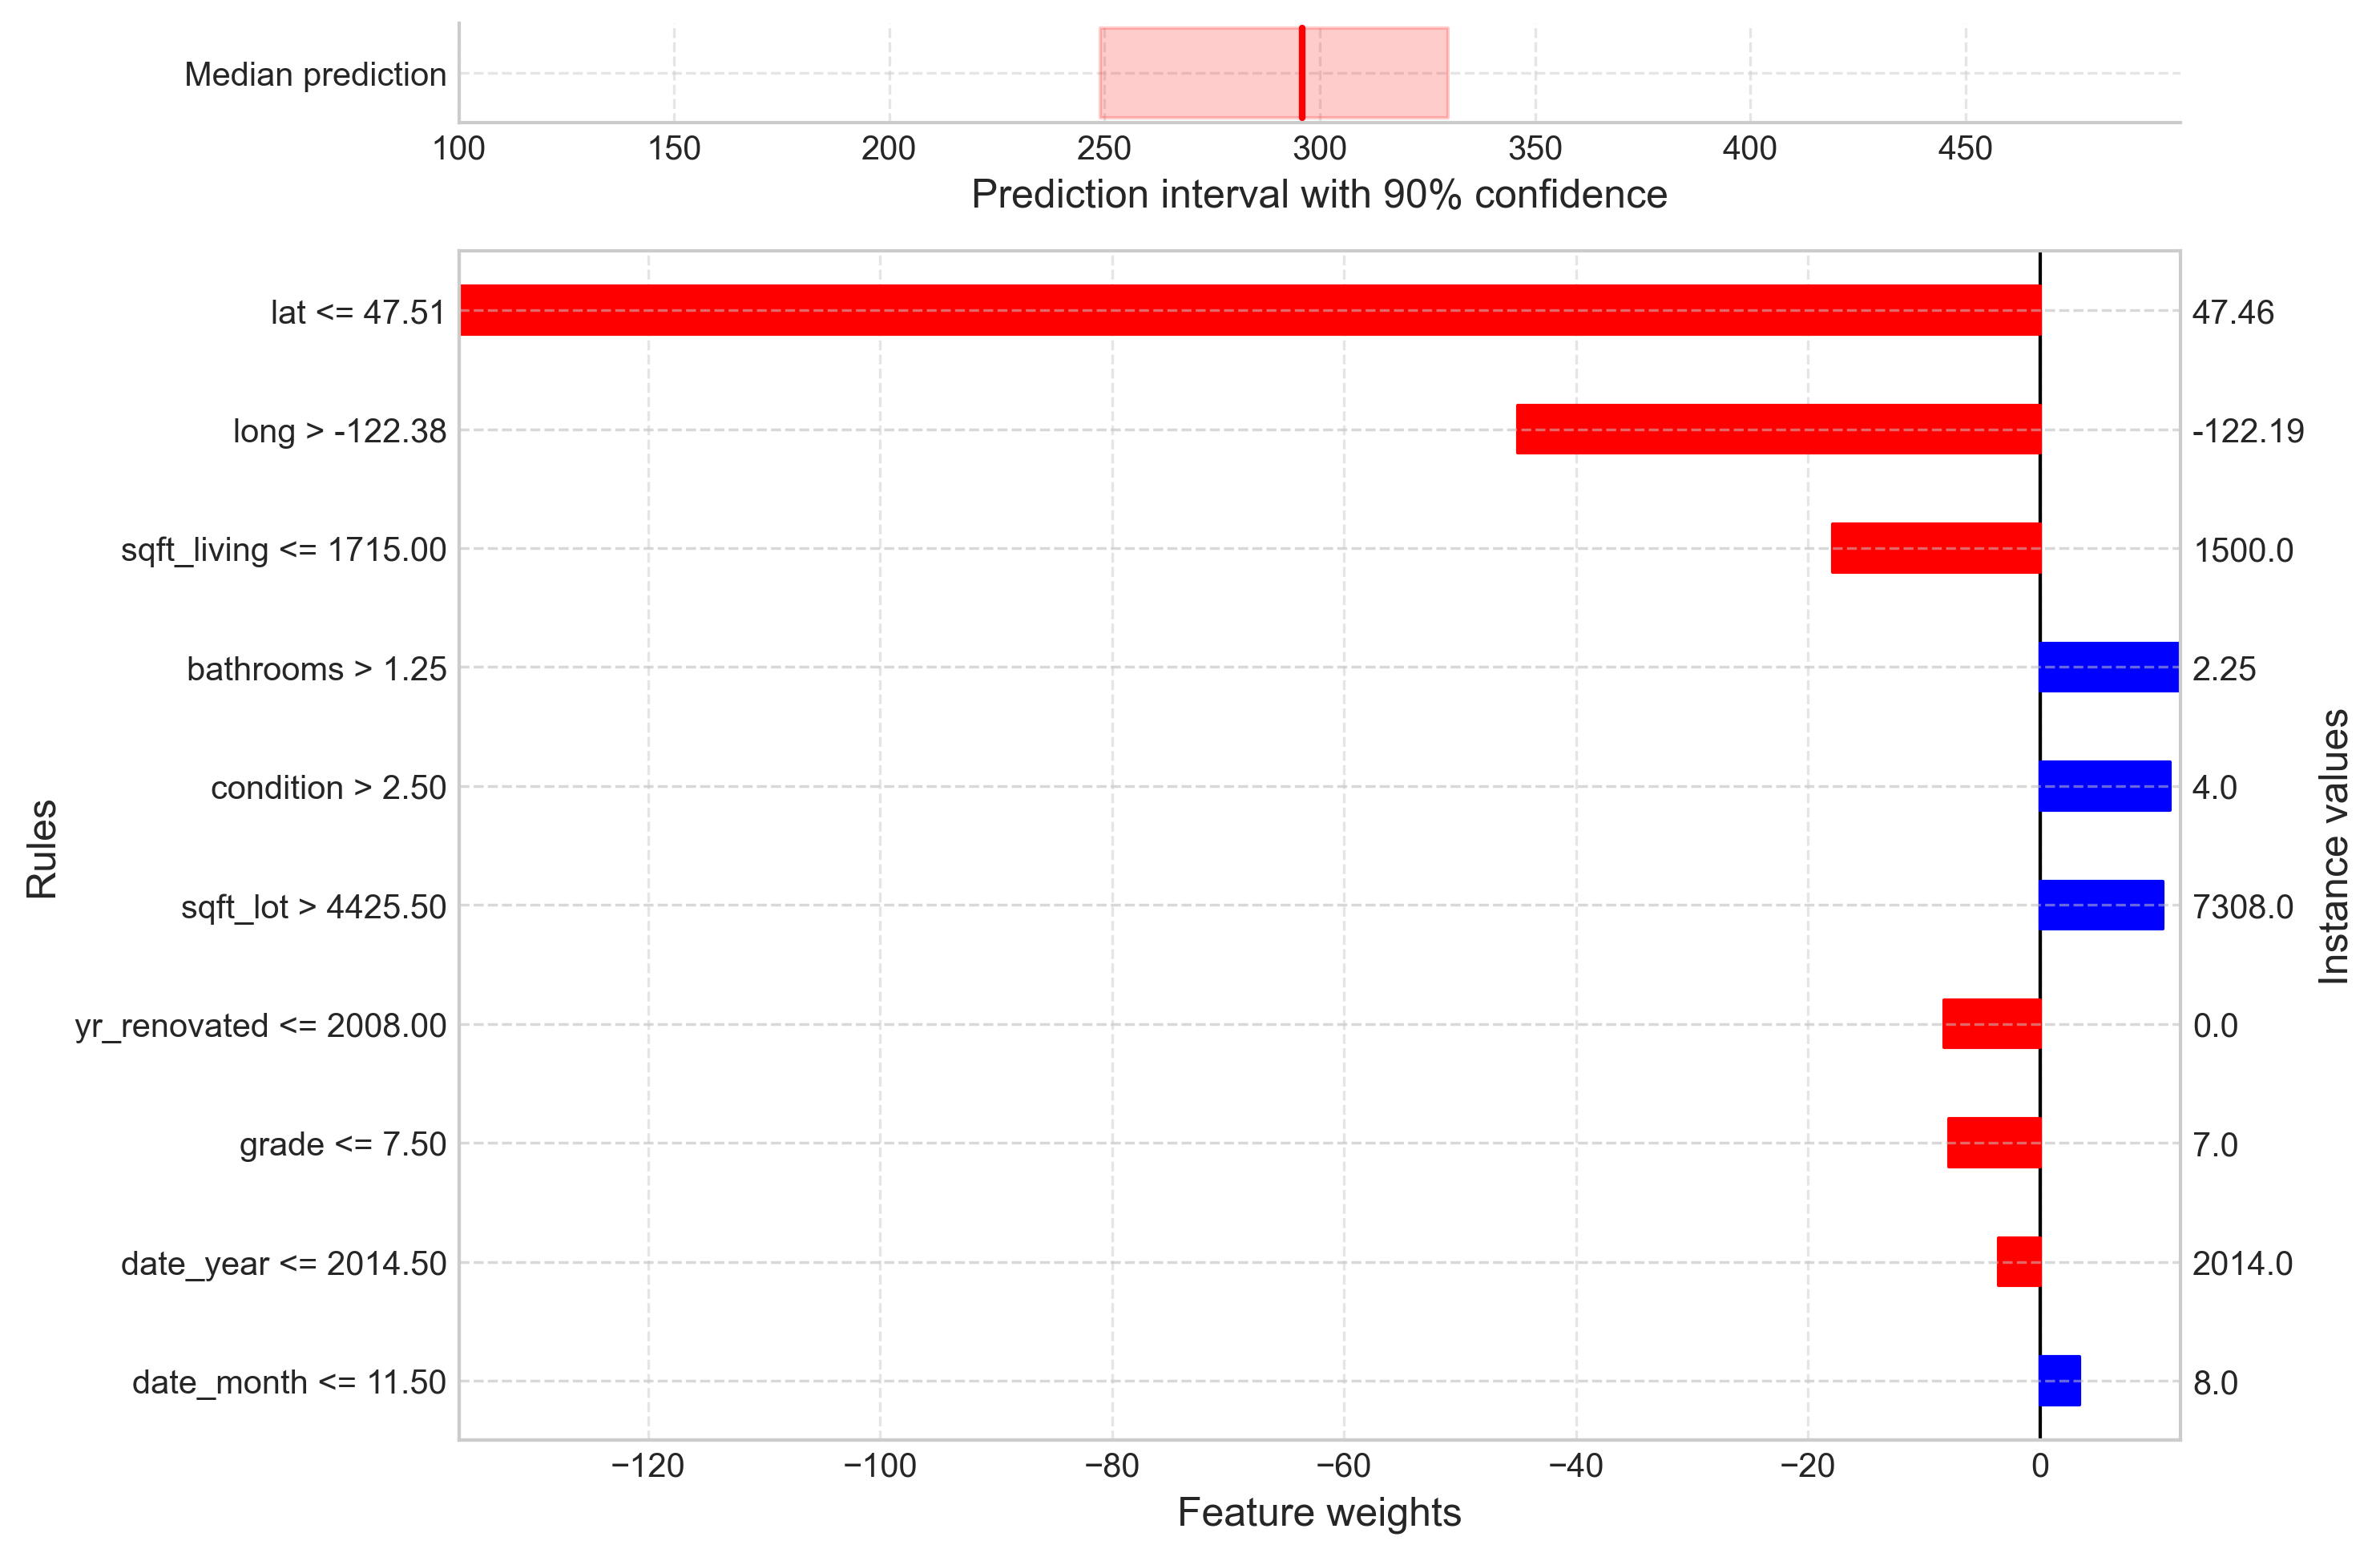

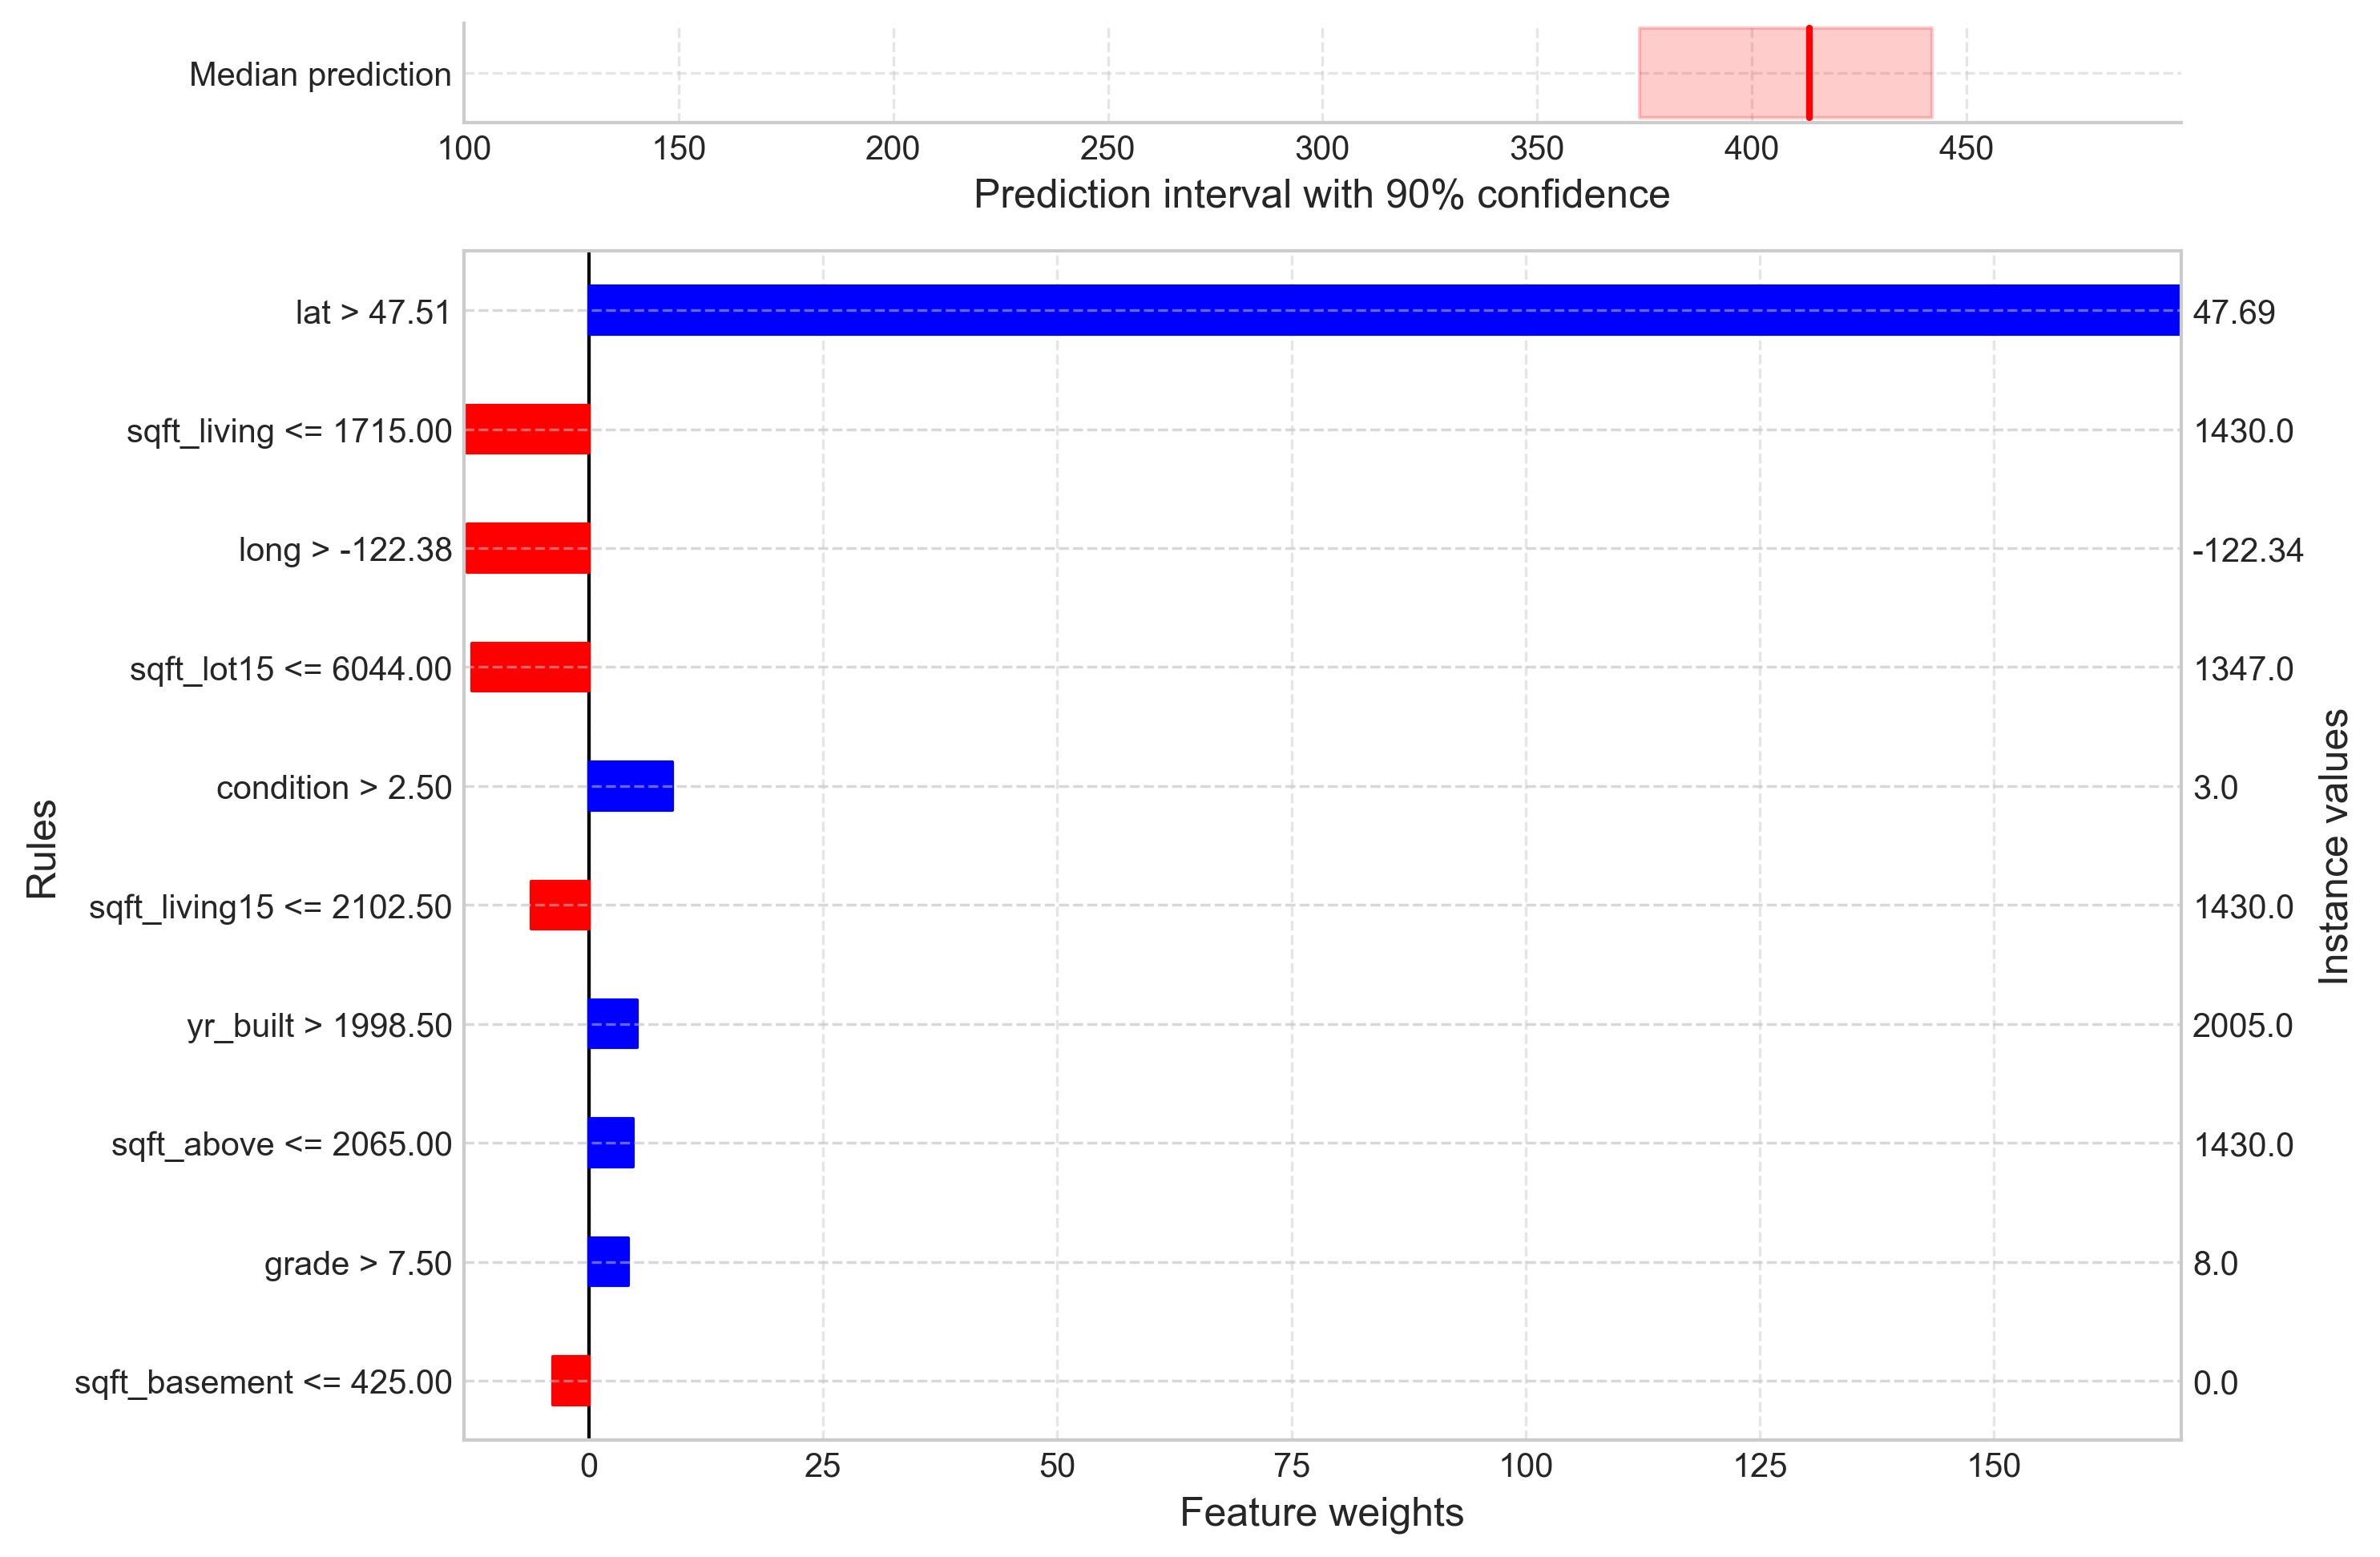

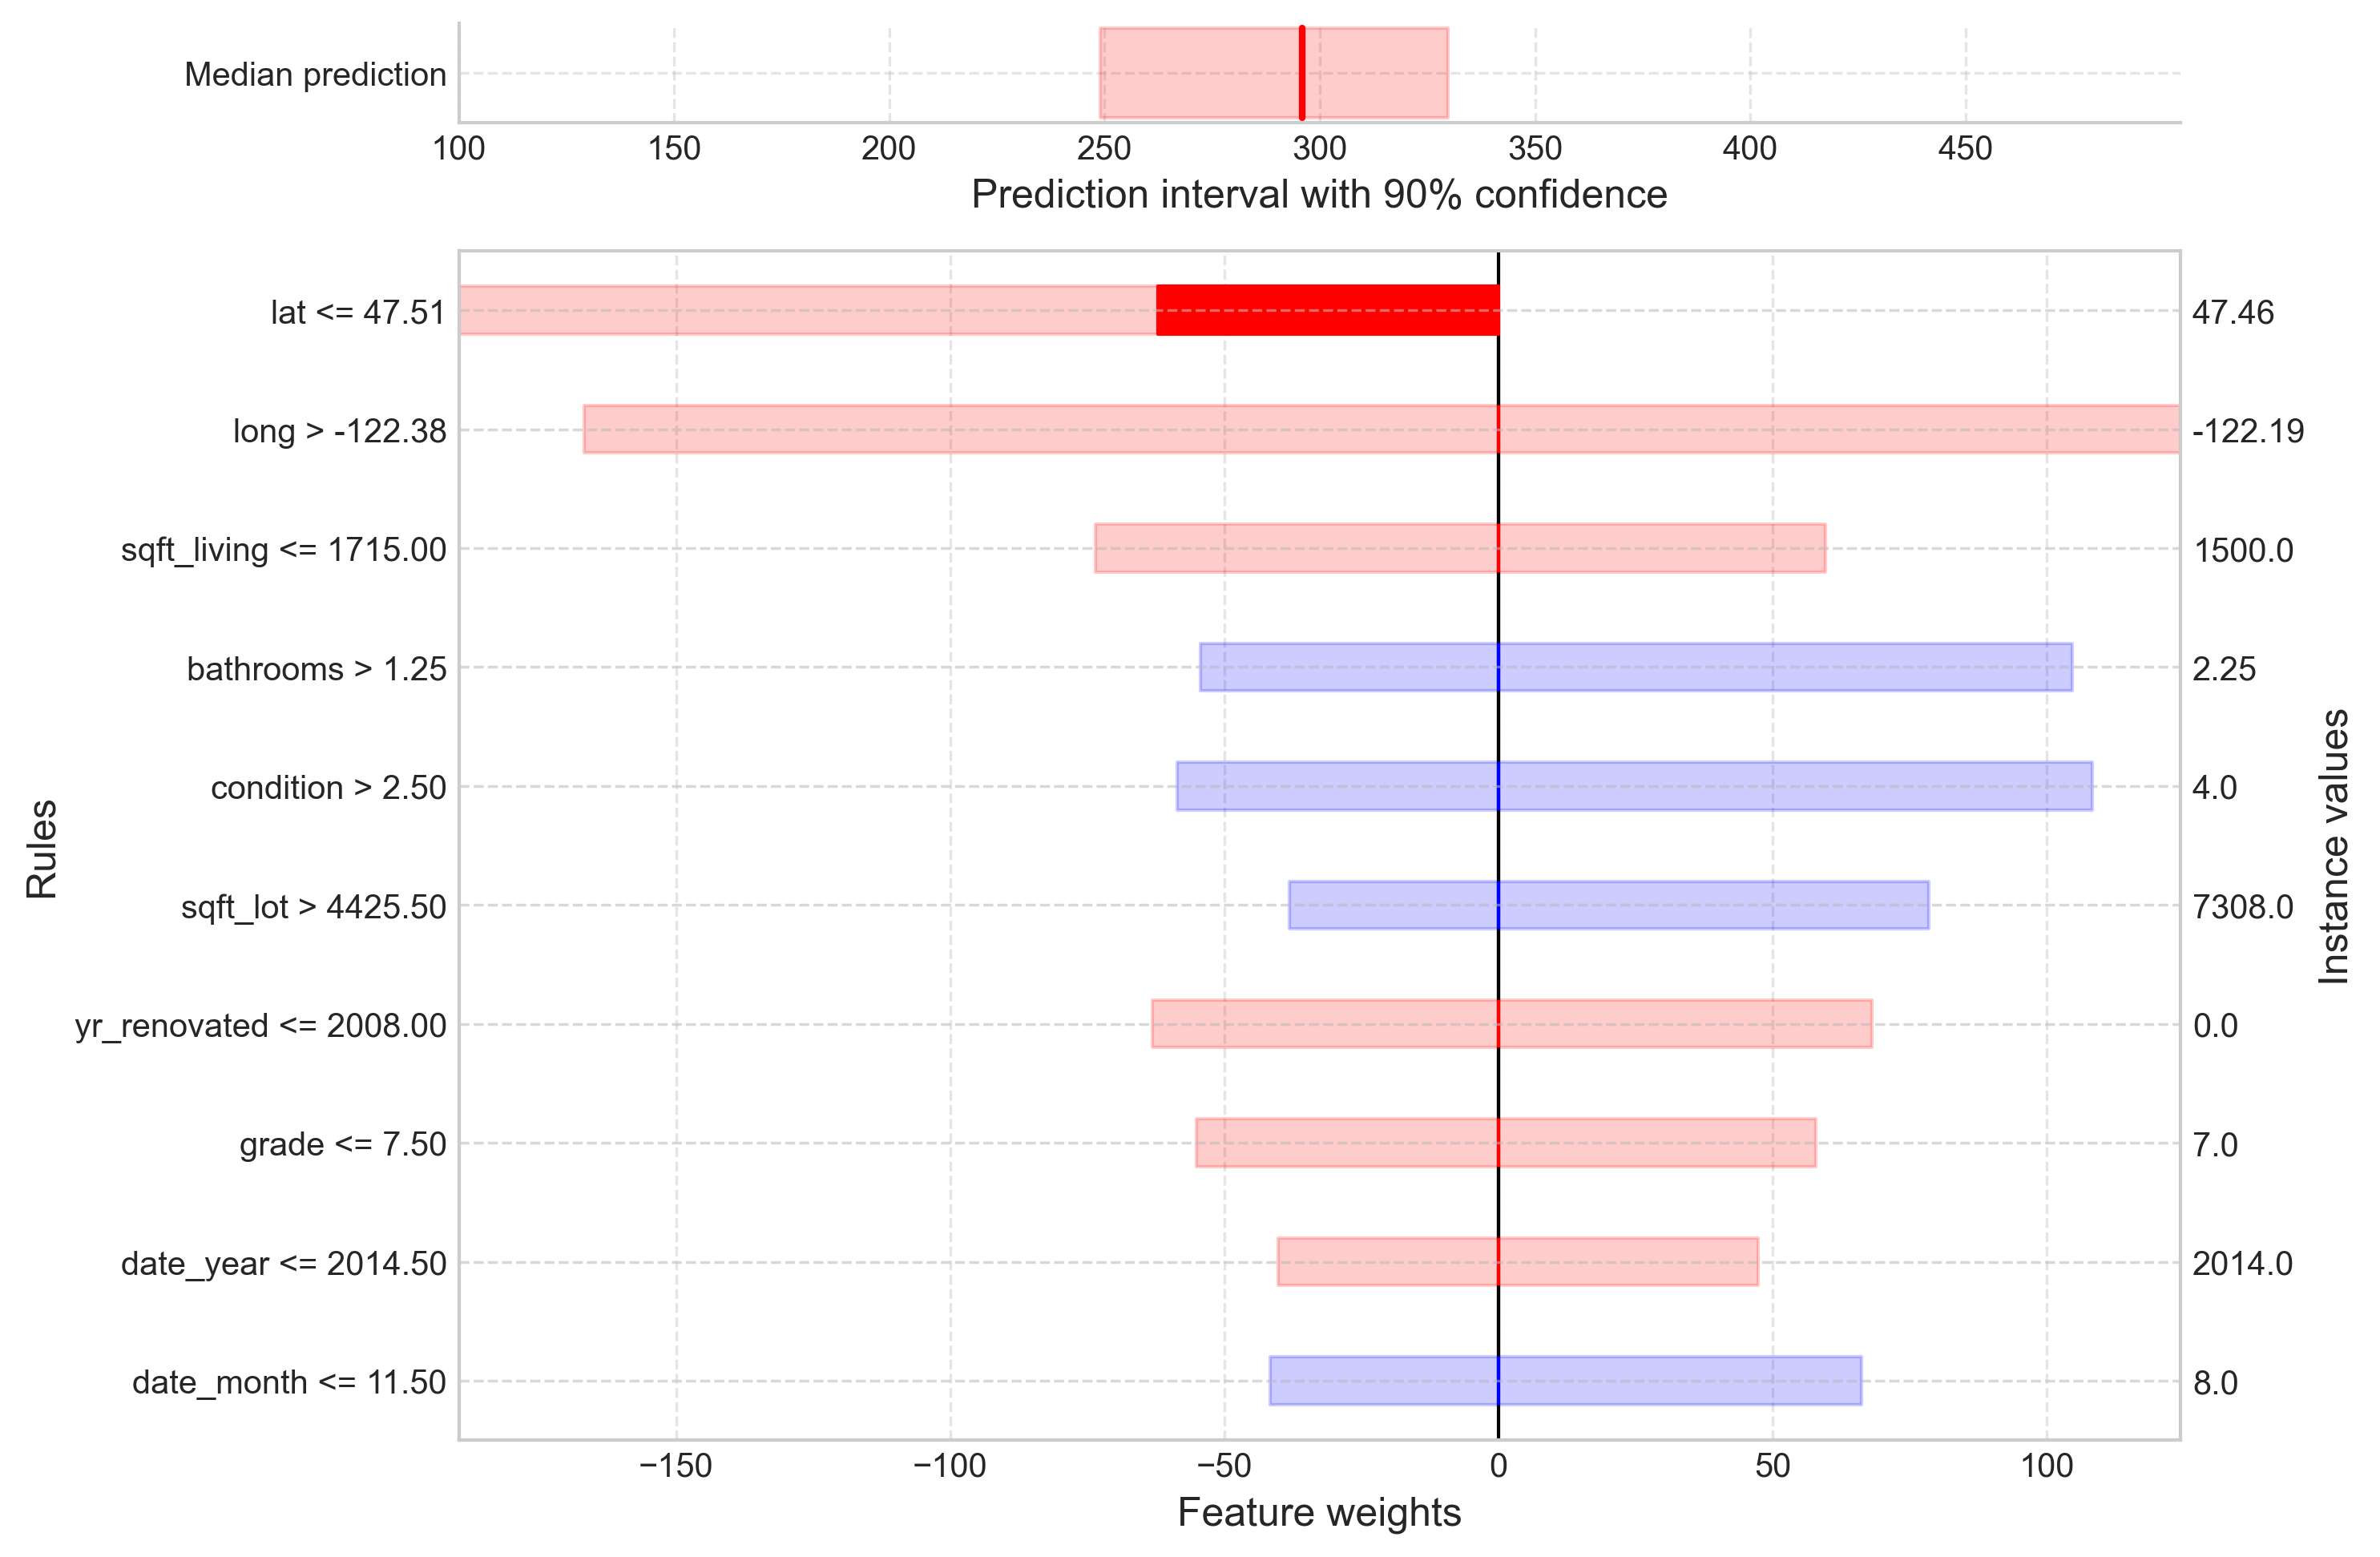

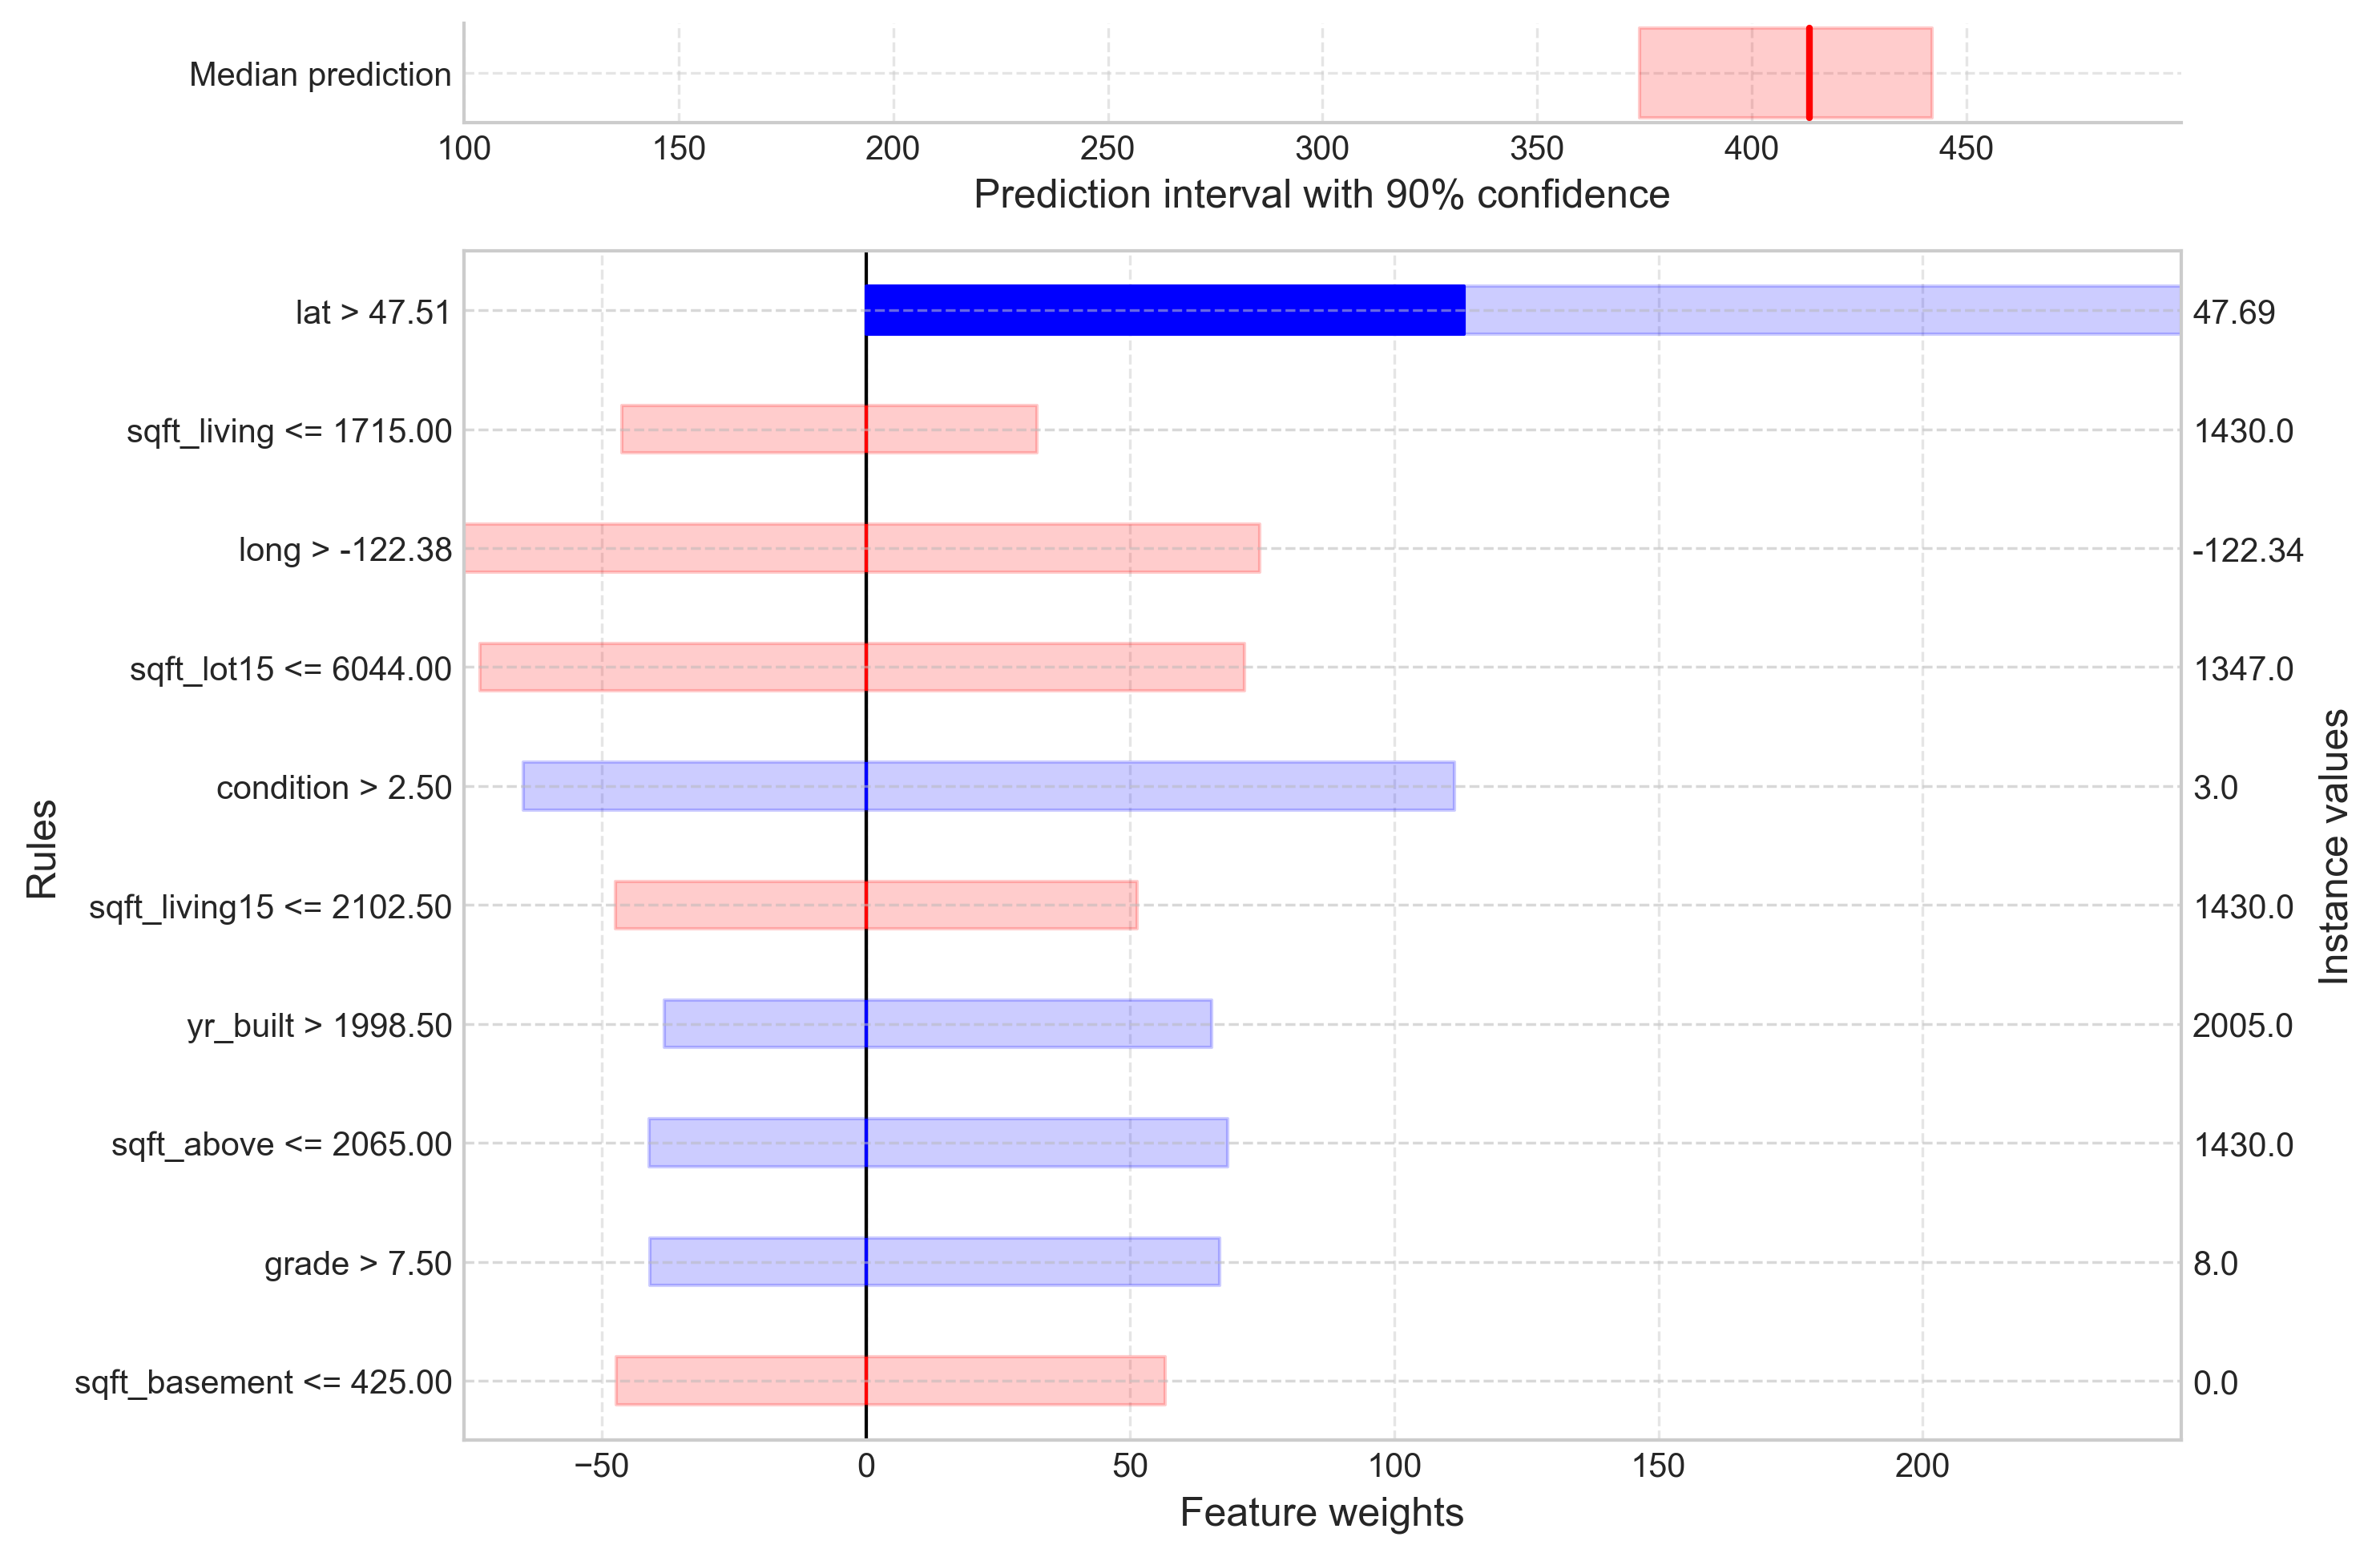

In [ ]:
factual_explanations.plot()
factual_explanations.plot(uncertainty=True)

factual_explanations.add_conjunctions().plot()
factual_explanations.remove_conjunctions().plot()

Default, the confidence interval is set to a symmetric interval of 90% (defined as `low_high_percentiles=(5,95)`). The intervals can cover any user specified interval, including one-sided intervals. To define a one-sided upper-bounded 90% interval, set `low_high_percentiles=(-np.inf,90)`, and to define a one-sided lower-bounded 95% interval, set `low_high_percentiles=(5,np.inf)`. Percentiles can also be set to any other values in the range (0,100) (exclusive), and intervals do not have to be symmetric.

In [ ]:
import numpy as np

lower_bounded_explanations = explainer.explain_factual(X_test, low_high_percentiles=(5, np.inf))
asymmetric_explanations = explainer.explain_factual(X_test, low_high_percentiles=(5, 75))

The `explore_alternatives` will work exactly the same as for classification. Otherwise, the discretizer must be set explicitly and the 'decile' discretizer is recommended. Alternative plots work as for classification.

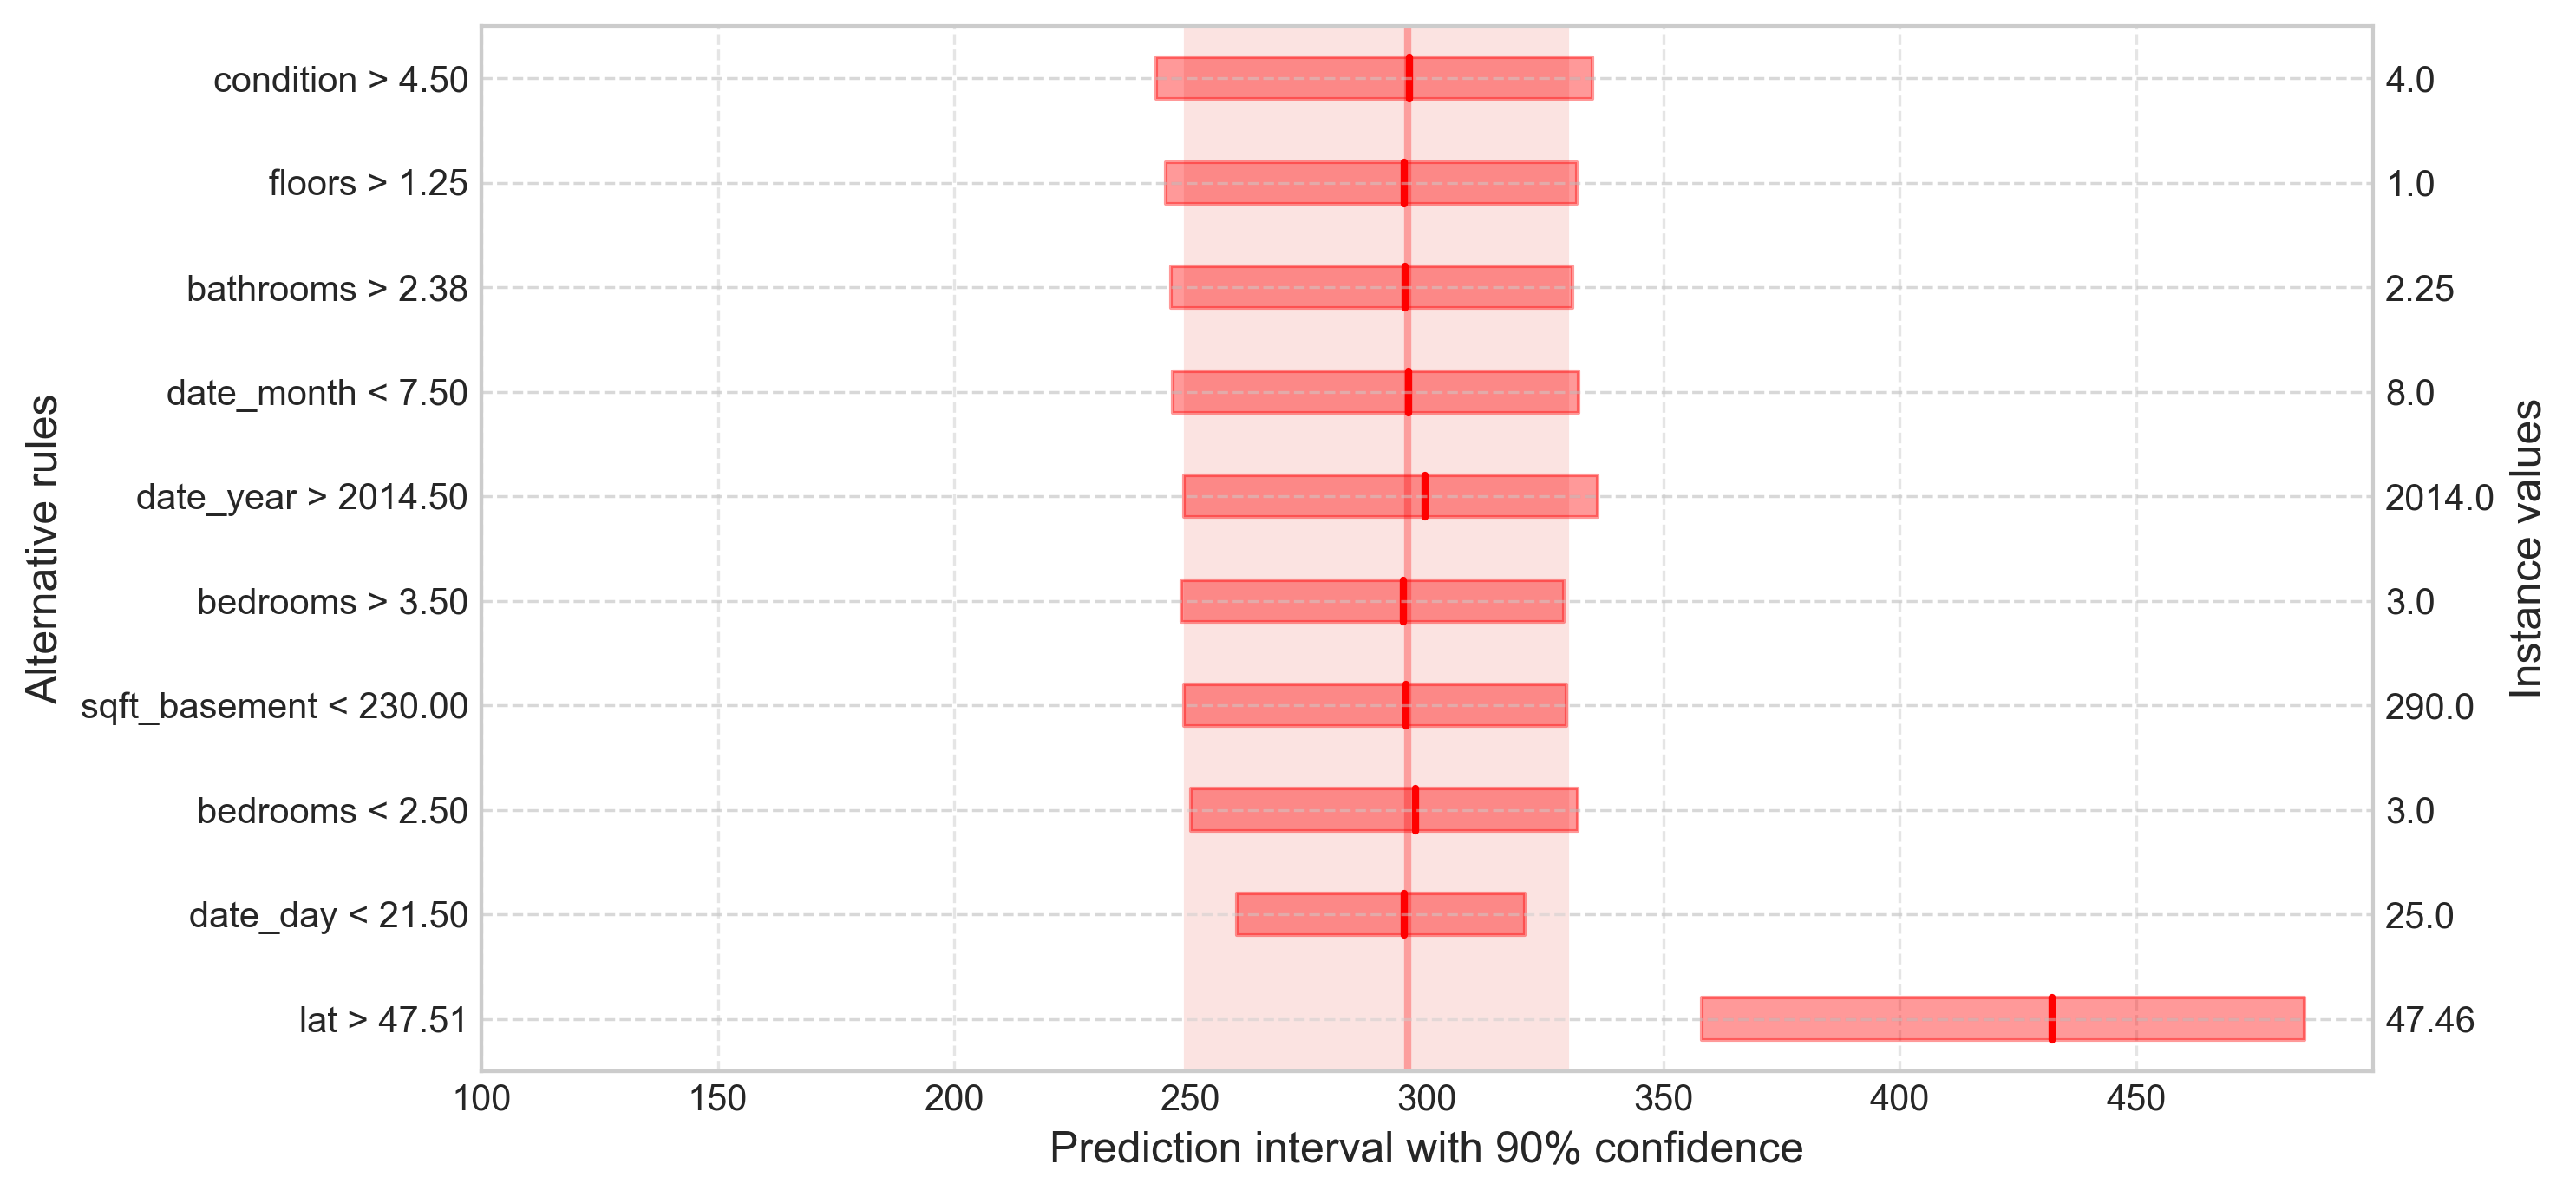

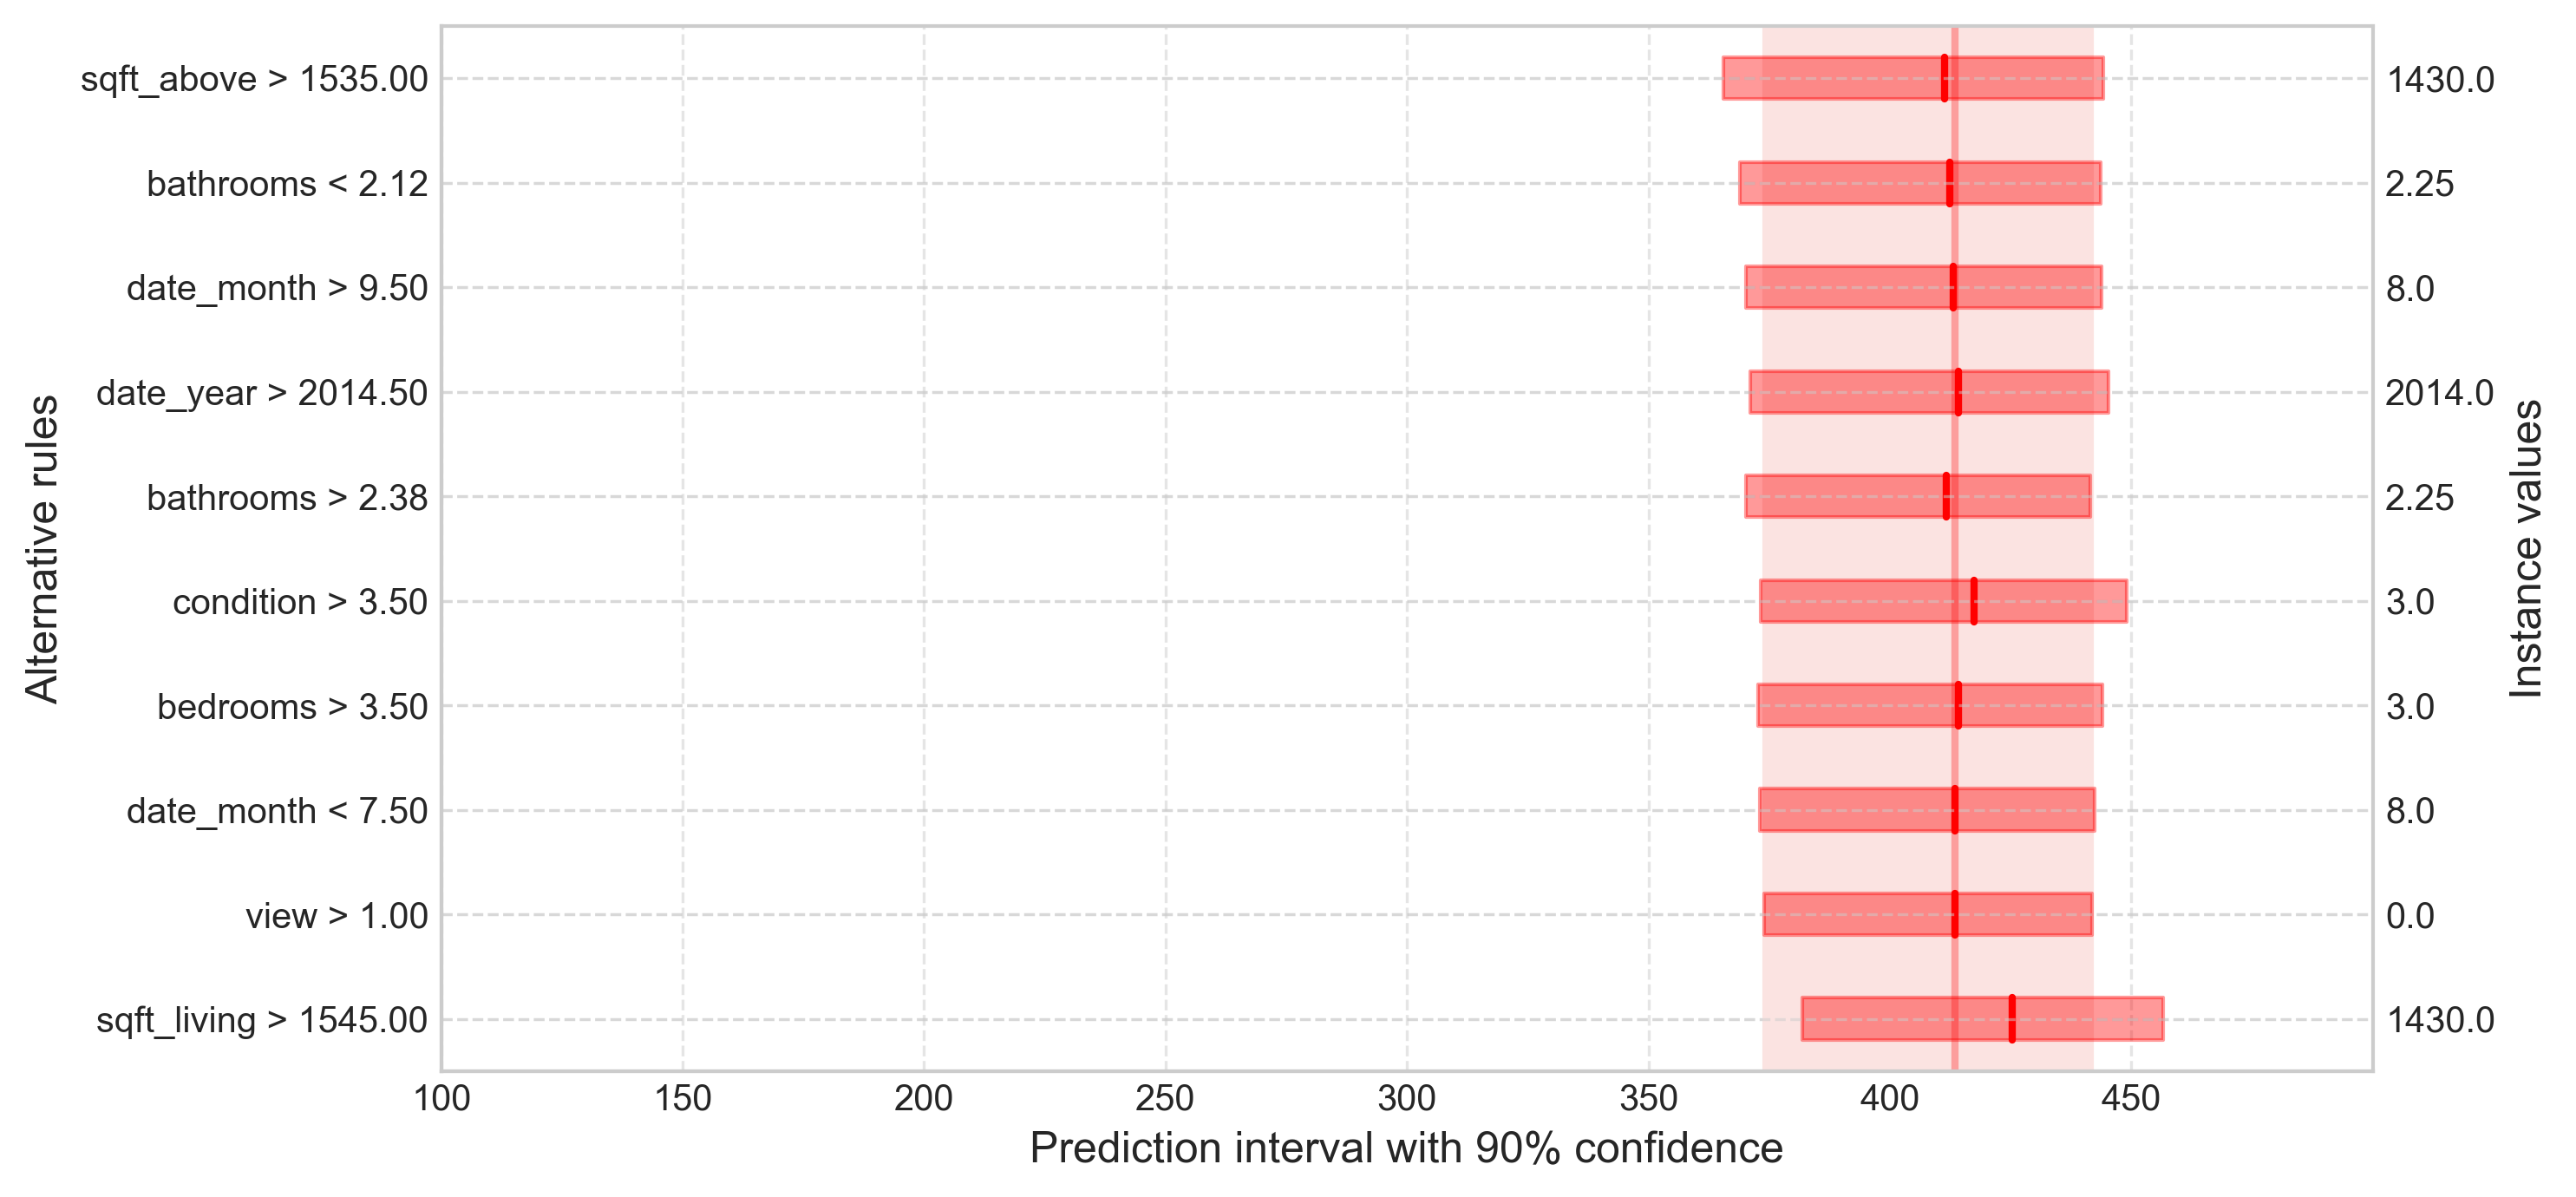

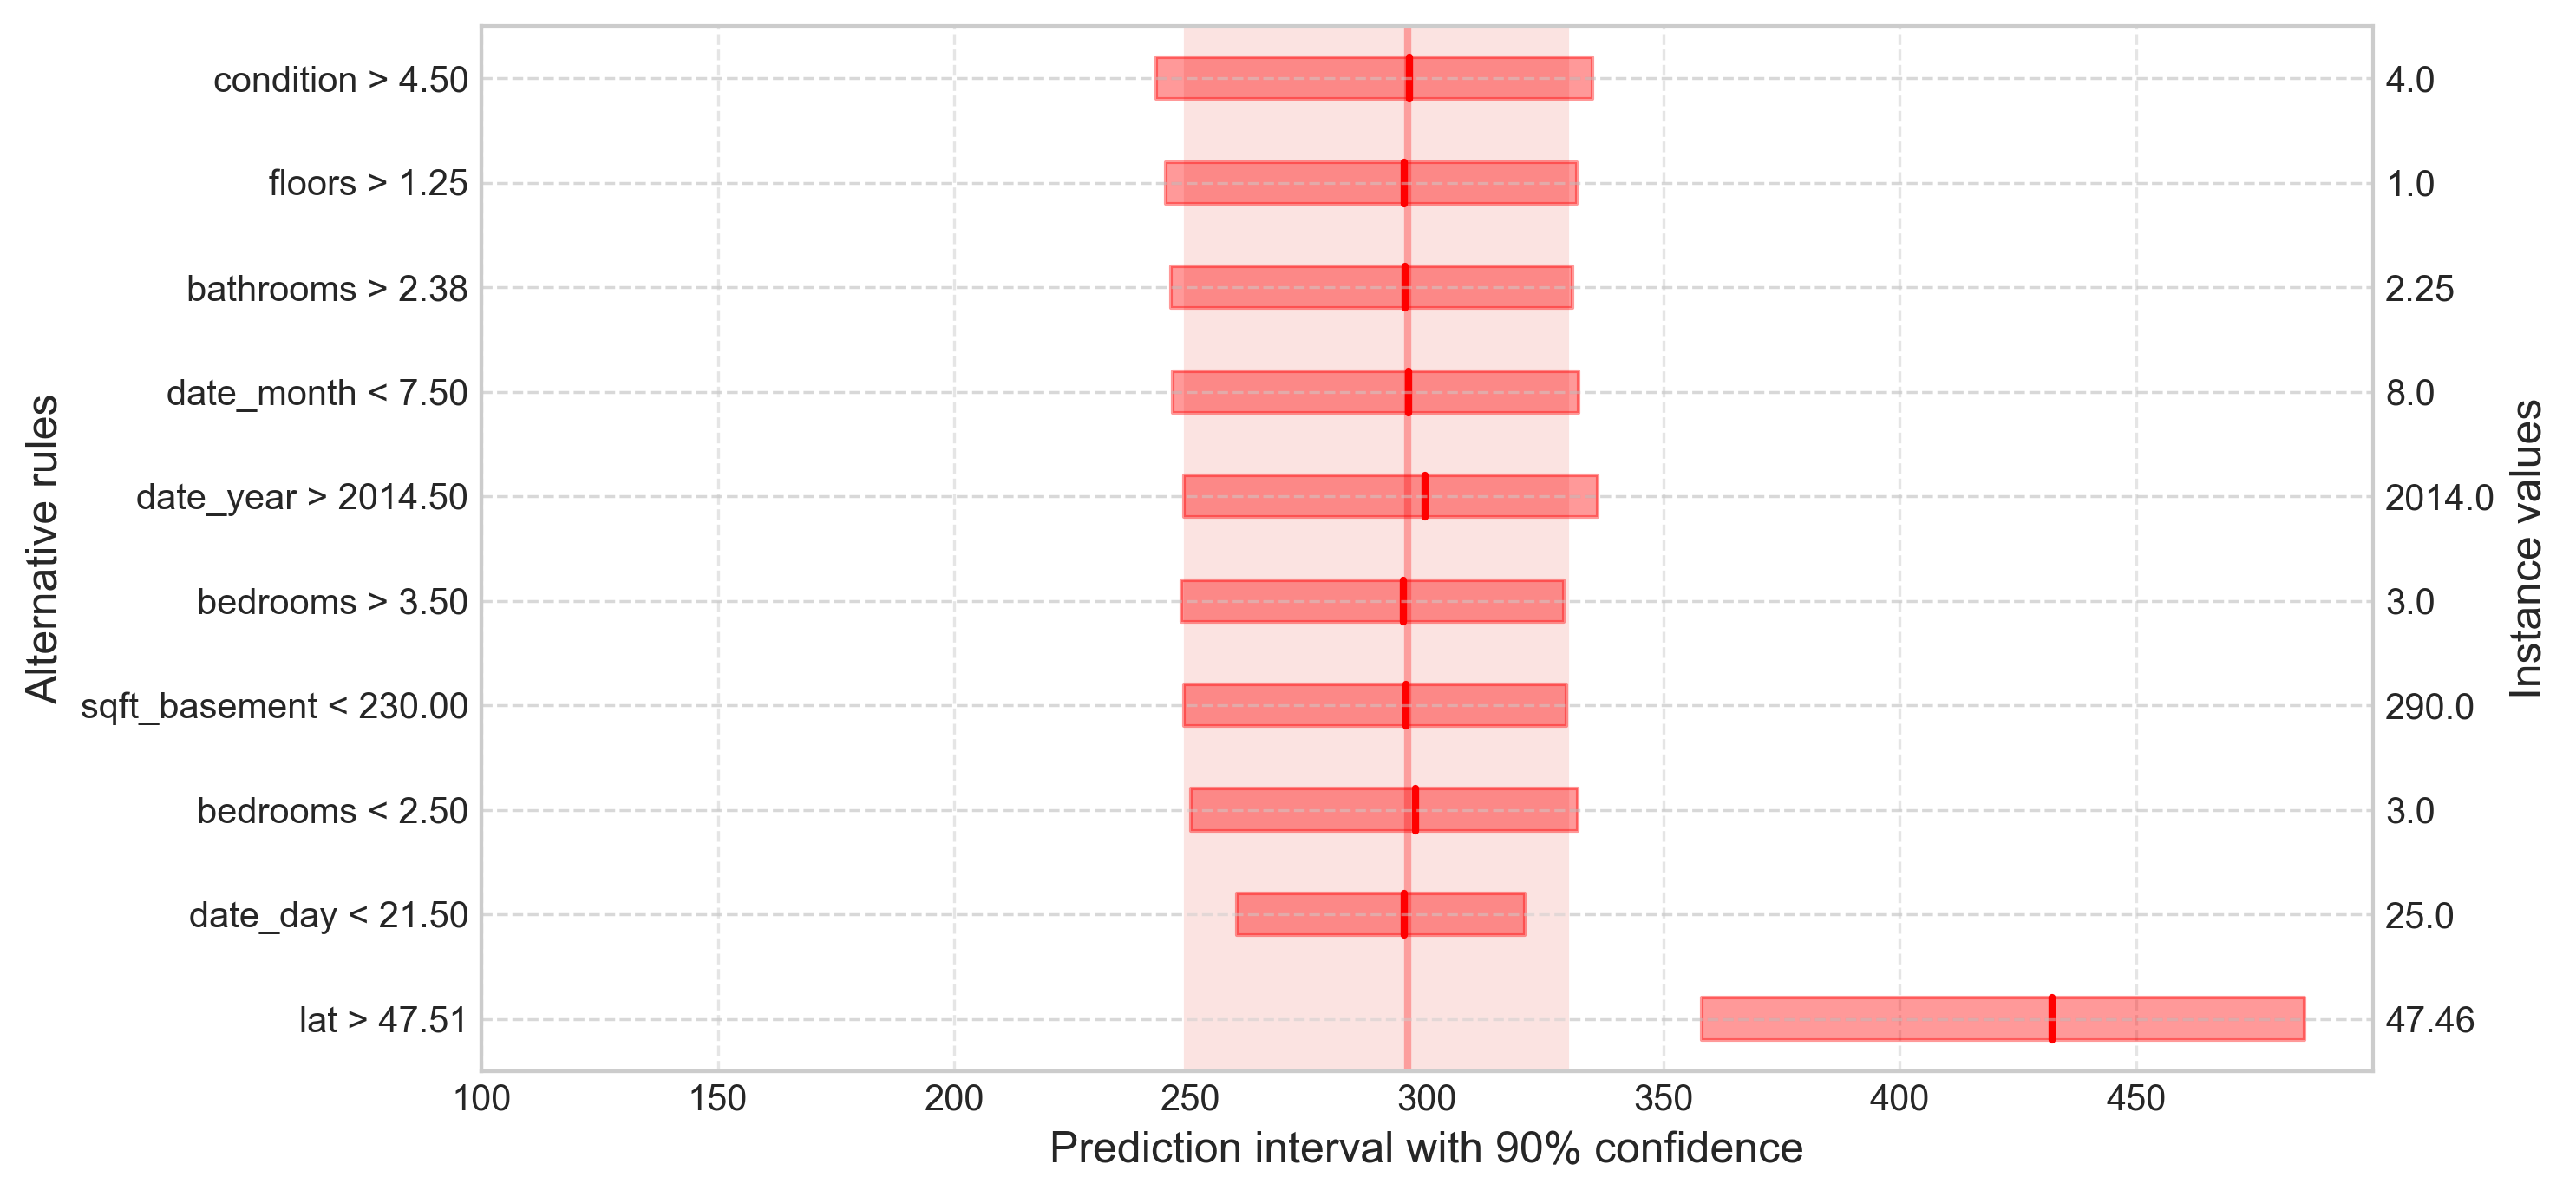

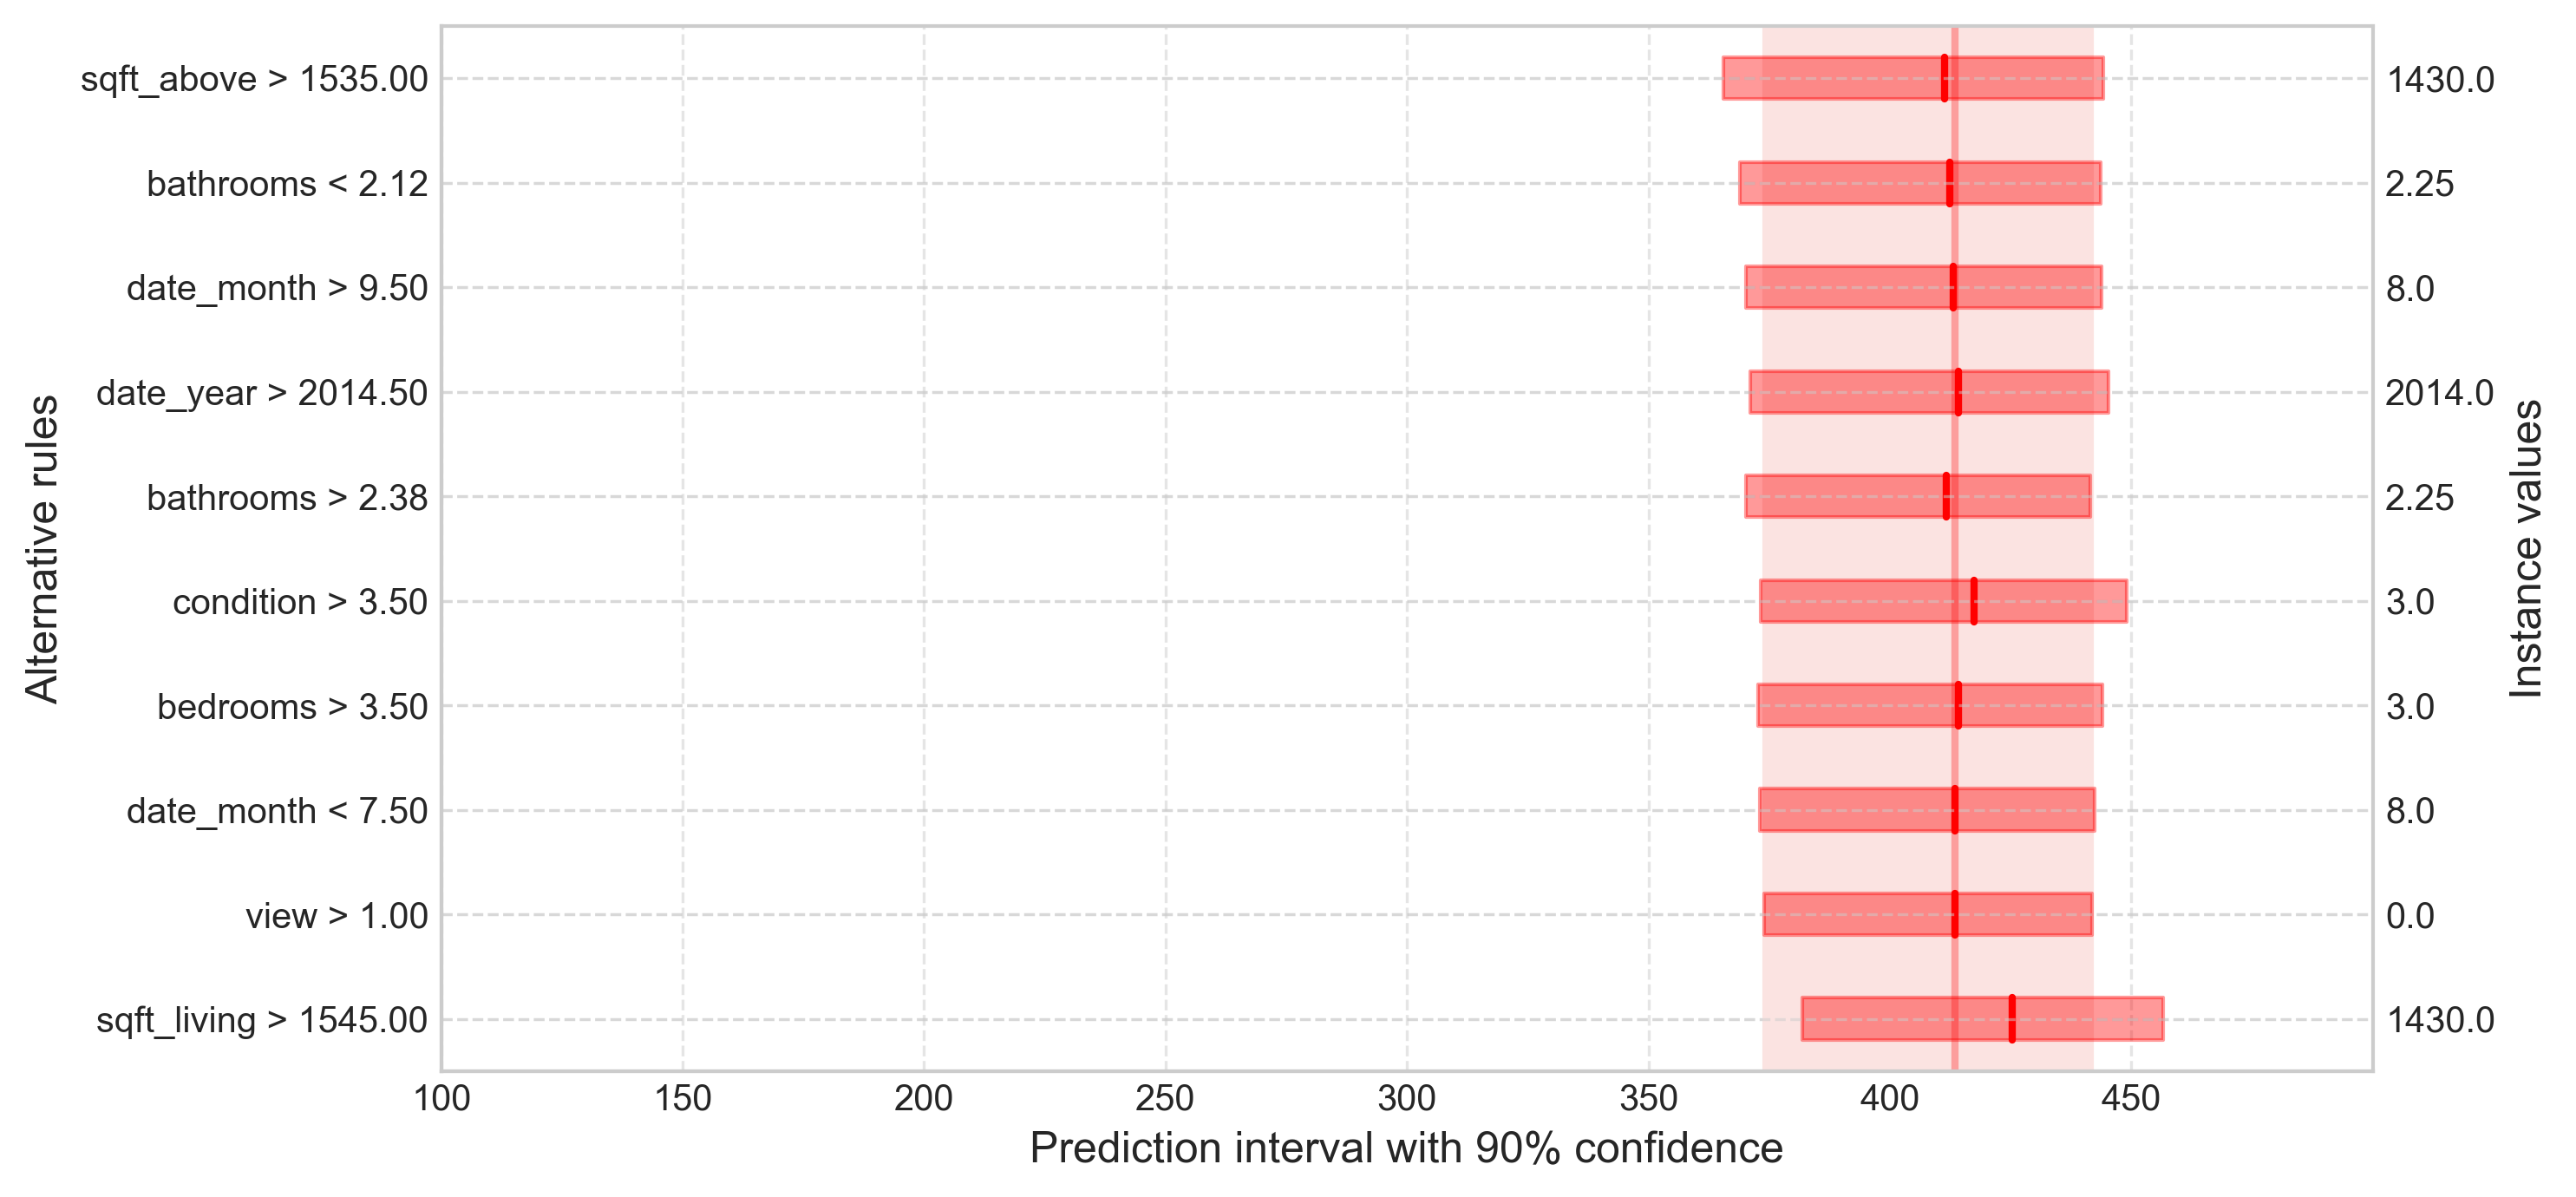

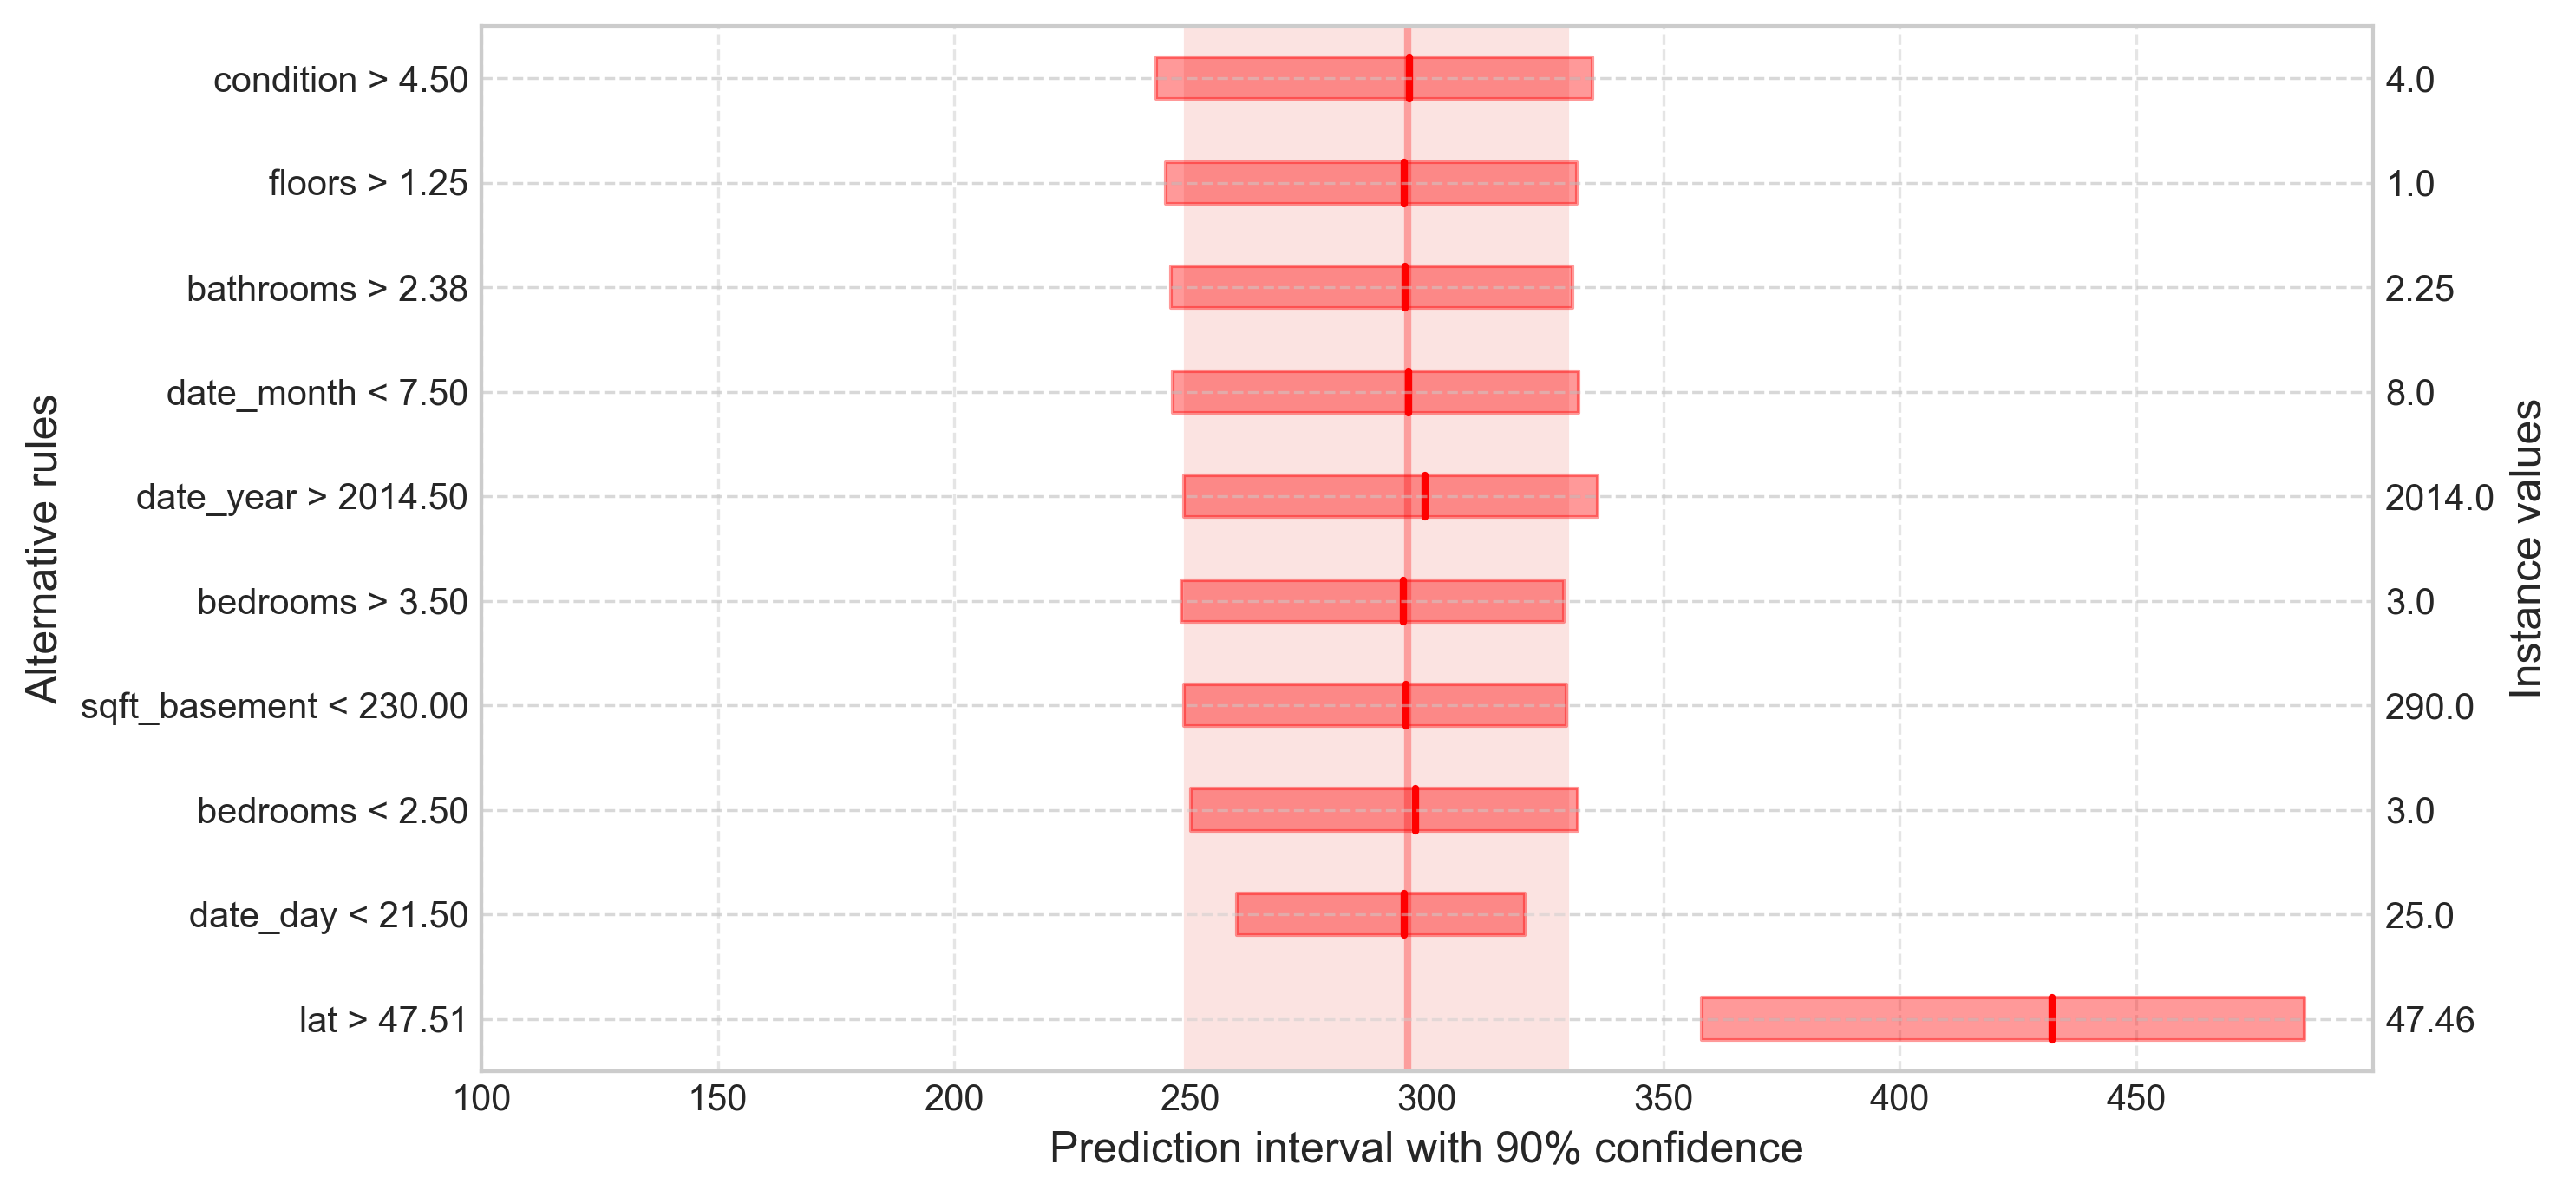

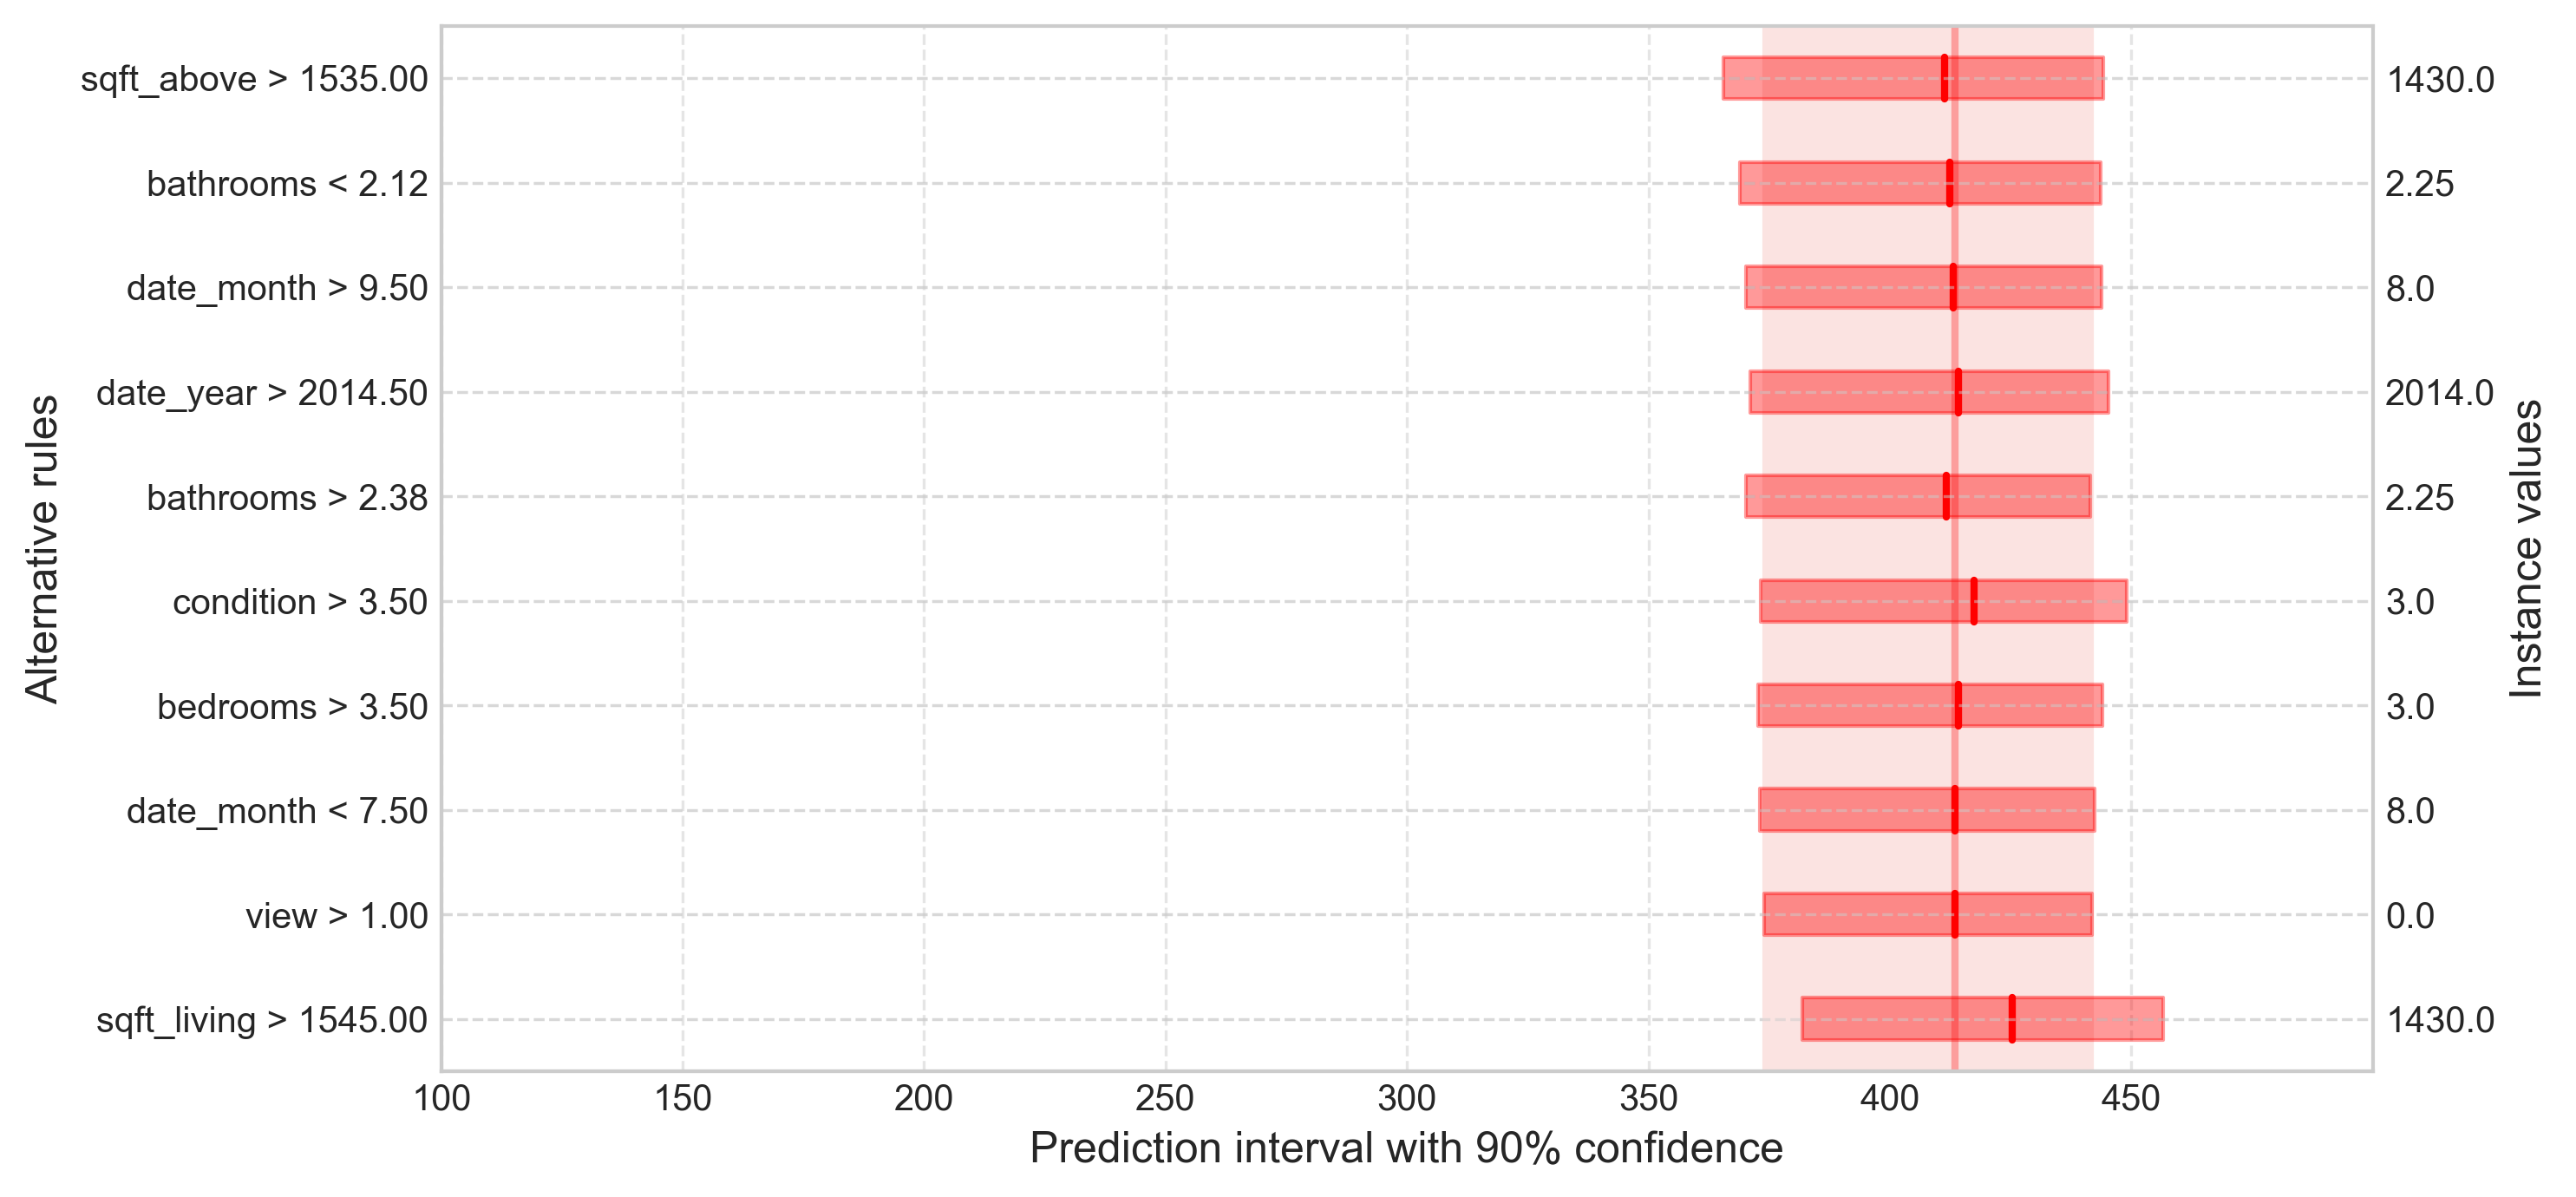

In [ ]:
alternative_explanations = explainer.explore_alternatives(X_test)

alternative_explanations.plot()
alternative_explanations.add_conjunctions().plot()
alternative_explanations.remove_conjunctions().plot()